# Прогноз отмены бронирования для сети отелей UrbanStay

- Дайте название проекту, запишите его в блоке Markdown выше.
- Опишите, как вы поняли постановку задачи.
- Опишите данные для решения задачи.

**Заказчик** - сеть отелей среднего сегмента UrbanStay. Последние два года около трети броней отменяются незадолго до заезда, из-за чего загрузка держится на уровне 60-70% вместо плановых 80%. Сейчас отмены компенсируются овербукингом «на глаз», и заказчик хочет заменить интуицию управляемым инструментом.

**Что нужно сделать:**

1. Построить модель, которая по параметрам брони предсказывает вероятность её отмены.
2. Оценить экономический эффект внедрения по трём показателям: динамика доли отмен, динамика загрузки отелей и прирост дохода (Incremental Revenue, IR).

**Целевые показатели заказчика:**

- доля отмен после внедрения модели - 10%;
- загрузка отеля не должна снизиться более чем на 8%;
- относительный IR - не менее 50%.

**Данные.** Два источника в PostgreSQL:

- `hotel_bookings` - 35 341 запись о бронированиях: канал продаж, состав гостей, история клиента, стоимость, срок до заезда, длительность проживания, тип питания и номера, число пожеланий и целевой статус брони (`отказ_брони` / `нет_отказа`);
- `hotel_reviews` - 25 177 отзывов: идентификатор клиента и брони, дата отзыва, оценка проживания от 1 до 5 и текст комментария.

Целевая переменная - факт отмены брони, положительный класс (`1`) - `отказ_брони`.

## Перевод бизнес-задачи на язык машинного обучения

- Напишите, что конкретно будете делать с точки зрения Data Science: расскажите, какие модели и методы вы планируете применить для решения задачи.

**Тип задачи** - бинарная классификация с вероятностным выходом: модель должна возвращать не метку, а вероятность отмены, потому что решение о перепродаже номера принимается по порогу, а порог задаётся экономикой, а не значением 0.5.

**Метрика оптимизации** - Incremental Revenue, а не accuracy или F1. Ошибки стоят по-разному: пропущенная отмена (FN) стоит отелю 64 500 руб. упущенного дохода, а ложное срабатывание (FP) - 7 000 руб. компенсаций. Поэтому модель настраивается прямо на рубли:

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$IR = IR_{после} - IR_{до}, \qquad IR_{отн} = \frac{IR_{после} - IR_{до}}{IR_{до}} \cdot 100\%$$

Вспомогательные метрики ROC-AUC и PR-AUC используются как индикатор ранжирующей способности: IR зависит от порога, а AUC - нет, поэтому по ним удобно сравнивать модели между собой.

**План работы:**

1. Выгрузка обеих таблиц из PostgreSQL через SQLAlchemy.
2. EDA: качество данных, пропуски, дубликаты, аномалии, распределения, динамика во времени и связь признаков с целевой переменной.
3. Объединение брони с отзывами по правилу «ближайший предшествующий отзыв».
4. Генерация признаков: производные от параметров брони, лояльность клиента, категоризация срока до заезда и сезона, векторизация текстов отзывов через TF-IDF.
5. Разделение на train / calibration / test в пропорции 60 / 20 / 20 со стратификацией по целевой переменной.
6. Турнир моделей Random Forest, LightGBM и CatBoost: подбор гиперпараметров в Optuna по кросс-валидации из трёх фолдов с валидационной выборкой в 2 000 объектов, критерий - IR.
7. Проверка гипотез по улучшению IR: признаки спроса, нативные категории CatBoost, блендинг, расширенный поиск.
8. Калибровка лучшей модели на полной обучающей выборке и поиск порога по калибровочной выборке.
9. Проверка стабильности на тестовой выборке, анализ важности признаков через SHAP.
10. Расчёт экономического эффекта и выводы для бизнеса.

**Защита от утечек.** Препроцессор (медианы для пропусков, словарь категорий, словарь TF-IDF) собран в `Pipeline` вместе с моделью и обучается внутри каждого фолда кросс-валидации только на его обучающей части. Порог подбирается на калибровочной выборке, а тестовая используется только для финальной оценки: ни модель, ни порог, ни признаки по ней не выбираются.

## Загрузка необходимых библиотек

- Загрузите всё, что планируете использовать для выполнения проекта.

Ячейка ниже доустанавливает пакеты, которых нет в базовом окружении платформы, и импортирует всё, что понадобится дальше. Установка идёт до импортов: на чистом ядре импорт в начале ячейки упал бы с `ModuleNotFoundError` раньше, чем отработал бы `pip`.

Функции подготовки данных, генерации признаков и расчёта бизнес-метрик вынесены в модуль `feature_pipeline.py`, который лежит рядом с тетрадью. Так один и тот же код используется и в тетради, и при инференсе сохранённой модели.

In [1]:
import importlib
import importlib.util
import json
import shutil
import site
import subprocess
import sys
import time
import warnings
from importlib.metadata import version
from pathlib import Path

# Пакеты, которых нет в базовом окружении платформы. Версии подобраны под стек
# Python 3.9 / numpy 1.21 / pandas 1.2.4 / sklearn 0.24 и не тянут его обновление.
REQUIRED = {
    "psycopg2": "psycopg2-binary==2.9.9",
    "optuna": "optuna==4.9.0",
    "lightgbm": "lightgbm==3.3.5",
    "catboost": "catboost==1.2.5",
    "numba": "numba==0.56.4",
    "shap": "shap==0.44.1",
}
to_install = [spec for module, spec in REQUIRED.items()
              if importlib.util.find_spec(module) is None]

# pandas 1.2 совместим только с SQLAlchemy 1.x: в 2.0 сменилась сигнатура MetaData,
# и pd.read_sql_query падает с TypeError ещё до запроса.
if (importlib.util.find_spec("sqlalchemy") is None
        or int(version("SQLAlchemy").split(".")[0]) >= 2):
    to_install.append("SQLAlchemy==1.4.54")

if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + to_install)
    sys.path.insert(0, site.getusersitepackages())
    importlib.invalidate_caches()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import optuna
import shap
from catboost import CatBoostClassifier, Pool

import feature_pipeline as fp

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = fp.RANDOM_STATE
# Число потоков фиксируем явно: без этого замеры времени сравнивают не алгоритмы,
# а их настройки многопоточности по умолчанию.
N_JOBS = 4

versions = pd.DataFrame(
    [(name, version(name)) for name in
     ["pandas", "numpy", "scikit-learn", "SQLAlchemy", "lightgbm",
      "catboost", "optuna", "shap", "matplotlib", "seaborn"]],
    columns=["библиотека", "версия"],
).set_index("библиотека")
versions.columns.name = f"Python {sys.version.split()[0]}"
display(versions)

Python 3.9.25,версия
библиотека,
pandas,1.2.4
numpy,1.21.1
scikit-learn,0.24.1
SQLAlchemy,1.4.54
lightgbm,3.3.5
catboost,1.2.5
optuna,4.9.0
shap,0.44.1
matplotlib,3.3.4


## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [2]:
DB_CONFIG = {
    "host": "rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net",
    "port": 6432,
    "database": "data-scientist-hotels",
    "user": "praktikum_student",
    "password": "Sdf4$2;d-d30pp",
}
connection_string = (
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_CONFIG)
)
engine = create_engine(connection_string)

QUERY_BOOKINGS = "SELECT * FROM hotel_bookings"
QUERY_REVIEWS = "SELECT * FROM hotel_reviews"

# Запросы выполняем внутри одного соединения, соединение закрывается контекстным менеджером.
with engine.connect() as connection:
    bookings_raw = pd.read_sql_query(text(QUERY_BOOKINGS), connection)
    reviews_raw = pd.read_sql_query(text(QUERY_REVIEWS), connection)
engine.dispose()

EXPECTED_ROWS = {"hotel_bookings": 35_341, "hotel_reviews": 25_177}
loaded = pd.DataFrame(
    [
        ["hotel_bookings", bookings_raw.shape[0], bookings_raw.shape[1],
         EXPECTED_ROWS["hotel_bookings"], bookings_raw.shape[0] == EXPECTED_ROWS["hotel_bookings"]],
        ["hotel_reviews", reviews_raw.shape[0], reviews_raw.shape[1],
         EXPECTED_ROWS["hotel_reviews"], reviews_raw.shape[0] == EXPECTED_ROWS["hotel_reviews"]],
    ],
    columns=["таблица", "строк", "столбцов", "строк_по_ТЗ", "совпадает"],
).set_index("таблица")
display(loaded)
display(bookings_raw.head())
display(reviews_raw.head())

,строк,столбцов,строк_по_ТЗ,совпадает
таблица,,,,
hotel_bookings,35341,17,35341,True
hotel_reviews,25177,5,25177,True


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,"6,700.0000",21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,"62,300.0000",15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,"53,600.0000",150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,"46,900.0000",96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


**Выводы по загрузке данных**

- Подключение к PostgreSQL собрано через `create_engine`, обе таблицы выгружены запросами `SELECT * FROM ...` внутри одного соединения, пул закрыт `engine.dispose()`.
- `hotel_bookings` - **35 341 строка и 17 столбцов**, `hotel_reviews` - **25 177 строк и 5 столбцов**. Объёмы сверены с описанием данных в задании программно: обе проверки вернули `True`, выгрузка полная.
- Типы пришли из базы как есть: даты (`booking_date`, `review_date`) - строки, `returning_customer` и `parking_included` - булевы, `booking_value` - число с плавающей точкой. Даты потребуют приведения к `datetime`, булевы поля - к 0/1.
- Ключ `booking_id` в обеих таблицах имеет один формат (`INN00000`), значит таблицы соединимы по нему технически. Пригоден ли такой ключ содержательно - отдельный вопрос, к которому мы вернёмся в разделе про объединение.

**Итог:** данные загружены полностью и в ожидаемом объёме, дальше - оценка их качества.

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [3]:
bookings_raw.info()
reviews_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

#### Пропуски, дубликаты и уникальность ключей

Проверяем каждую таблицу по трём пунктам сразу: доля пропусков по столбцам, полные дубликаты строк и уникальность ключа. В `hotel_bookings` ключ - `booking_id`, в `hotel_reviews` пара `booking_id` + `review_date`. Дубликаты по ключу проверяем не только по числу, но и на конфликт значений: если внутри группы все столбцы совпадают, это технические копии, если различаются - конфликт данных, и обрабатывать его нужно иначе.

In [4]:
def quality_report(df, name):
    """Сводка по пропускам и типам одной таблицы."""
    report = pd.DataFrame({
        "тип": df.dtypes.astype(str),
        "пропусков": df.isna().sum(),
        "доля_пропусков_%": (df.isna().mean() * 100).round(2),
        "уникальных": df.nunique(),
    })
    report.columns.name = name
    return report


display(quality_report(bookings_raw, "hotel_bookings"))
display(quality_report(reviews_raw, "hotel_reviews"))

keys = pd.DataFrame(
    [
        ["hotel_bookings", len(bookings_raw), int(bookings_raw.duplicated().sum()),
         int(bookings_raw["booking_id"].duplicated().sum()), bookings_raw["booking_id"].nunique()],
        ["hotel_reviews", len(reviews_raw), int(reviews_raw.duplicated().sum()),
         int(reviews_raw.duplicated(subset=["booking_id", "review_date"]).sum()),
         reviews_raw["booking_id"].nunique()],
    ],
    columns=["таблица", "строк", "полных_дублей", "дублей_по_ключу", "уникальных_booking_id"],
).set_index("таблица")
display(keys)

duplicated_ids = bookings_raw.loc[bookings_raw["booking_id"].duplicated(), "booking_id"].unique()
conflicts = (
    bookings_raw[bookings_raw["booking_id"].isin(duplicated_ids)]
    .groupby("booking_id")
    .nunique()
    .max()
    .rename("максимум_различных_значений_внутри_booking_id")
    .to_frame()
)
display(conflicts.T)

# Те же дубли по ключу в отзывах: одна ли это поездка с несколькими отзывами
# или конфликт данных с разными оценками одного и того же отзыва.
review_key_dups = reviews_raw[
    reviews_raw.duplicated(subset=["booking_id", "review_date"], keep=False)
]
review_conflicts = (
    review_key_dups.groupby(["booking_id", "review_date"])
    .agg(клиентов=("customer_id", "nunique"),
         оценок=("stay_rating", "nunique"),
         текстов=("review_text", "nunique"))
    .max()
    .rename("максимум внутри пары booking_id + review_date")
    .to_frame()
)
review_conflicts.loc["строк в таких парах"] = len(review_key_dups)
display(review_conflicts)

hotel_bookings,тип,пропусков,доля_пропусков_%,уникальных
booking_id,object,0,0.0000,30733
booking_date,object,0,0.0000,2445
sales_channel,object,0,0.0000,3
adult_count,int64,0,0.0000,6
child_count,int64,0,0.0000,3
returning_customer,bool,0,0.0000,2
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
booking_status,object,0,0.0000,2
booking_value,float64,0,0.0000,1766


hotel_reviews,тип,пропусков,доля_пропусков_%,уникальных
customer_id,object,0,0.0000,13429
booking_id,object,0,0.0000,21883
review_date,object,0,0.0000,2514
stay_rating,int64,0,0.0000,4
review_text,object,0,0.0000,14153


,строк,полных_дублей,дублей_по_ключу,уникальных_booking_id
таблица,,,,
hotel_bookings,35341,4608,4608,30733
hotel_reviews,25177,0,130,21883


,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
максимум_различных_значений_внутри_booking_id,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


,максимум внутри пары booking_id + review_date
клиентов,1
оценок,2
текстов,2
строк в таких парах,260


#### Целевая переменная

Смотрим баланс классов: от него зависит и выбор метрики, и стратификация при разбиении выборок.

booking_status,бронирований,доля_%
нет_отказа,25177,71.2400
отказ_брони,10164,28.7600


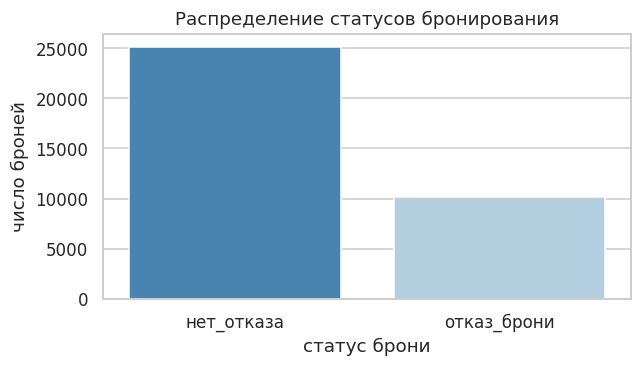

In [5]:
target_share = (
    bookings_raw["booking_status"]
    .value_counts(dropna=False)
    .to_frame("бронирований")
    .assign(доля_=lambda d: (d["бронирований"] / len(bookings_raw) * 100).round(2))
    .rename(columns={"доля_": "доля_%"})
)
target_share.columns.name = "booking_status"
display(target_share)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=target_share.index, y=target_share["бронирований"], ax=ax, palette="Blues_r")
ax.set_title("Распределение статусов бронирования")
ax.set_xlabel("статус брони")
ax.set_ylabel("число броней")
fig.tight_layout()
plt.show()

#### Данные во времени

Заказчик утверждает, что тревожная тенденция держится последние два года. Проверяем это по данным: смотрим, как распределены брони по годам и как менялась доля отмен. Заодно этот разрез отвечает на вопрос, допустимо ли случайное разбиение выборок вместо временного, и показывает распределение заездов по месяцам - на нём строится категоризация сезонности.

,броней,доля_отмен_%
год оформления брони,,
2017,5761,29.6600
2018,7602,29.1200
2019,8641,29.5500
2020,8668,29.8300
2021,3008,24.3700
2022,1190,22.8600
2023,373,19.3000
2024,78,23.0800
2025,20,35.0000


месяц заезда,1,2,3,4,5,6,7,8,9,10,11,12
заездов,"2,887.0000","2,753.0000","2,993.0000","2,870.0000","3,133.0000","2,928.0000","2,945.0000","3,020.0000","2,932.0000","3,017.0000","2,872.0000","2,991.0000"
доля_%,8.1700,7.7900,8.4700,8.1200,8.8700,8.2800,8.3300,8.5500,8.3000,8.5400,8.1300,8.4600


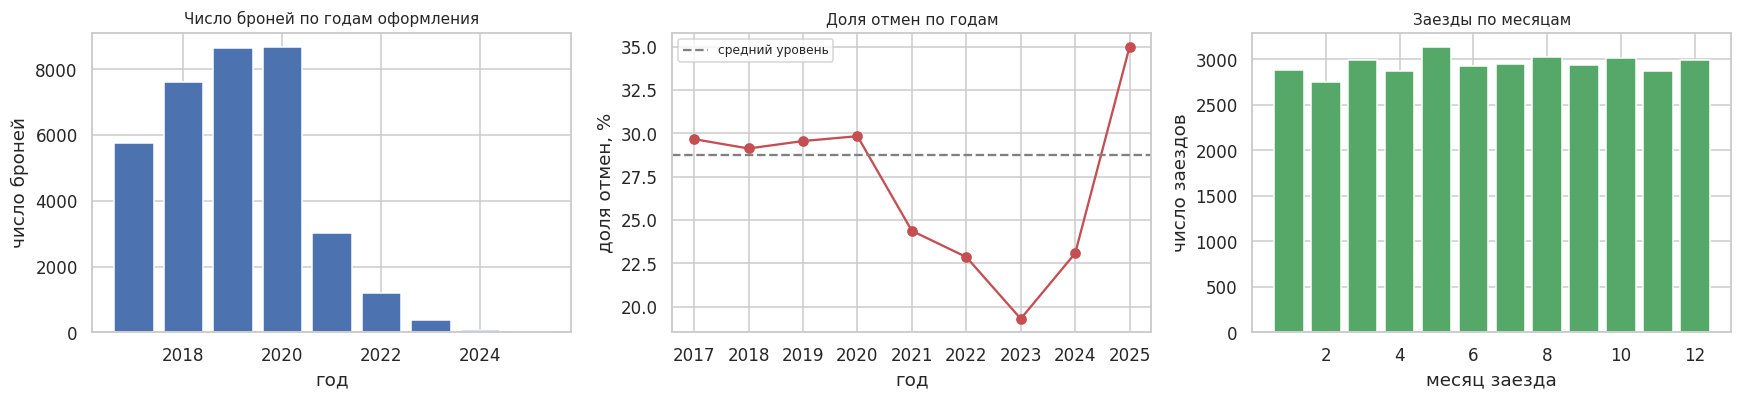

In [6]:
bookings_dated = bookings_raw.assign(
    booking_dt=pd.to_datetime(bookings_raw["booking_date"]),
    отмена=(bookings_raw["booking_status"] == "отказ_брони").astype(int),
)
by_year = bookings_dated.groupby(bookings_dated["booking_dt"].dt.year)["отмена"].agg(
    броней="size", доля_отмен="mean"
)
by_year["доля_отмен_%"] = (by_year["доля_отмен"] * 100).round(2)
by_year = by_year.drop(columns="доля_отмен")
by_year.index.name = "год оформления брони"
display(by_year)

checkin_dates = bookings_dated["booking_dt"] + pd.to_timedelta(
    bookings_dated["days_until_checkin"], unit="D"
)
by_checkin_month = checkin_dates.dt.month.value_counts().sort_index().to_frame("заездов")
by_checkin_month["доля_%"] = (by_checkin_month["заездов"] / len(bookings_dated) * 100).round(2)
by_checkin_month.index.name = "месяц заезда"
display(by_checkin_month.T)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
axes[0].bar(by_year.index, by_year["броней"], color="#4C72B0")
axes[0].set_title("Число броней по годам оформления", fontsize=10)
axes[0].set_xlabel("год")
axes[0].set_ylabel("число броней")

axes[1].plot(by_year.index, by_year["доля_отмен_%"], marker="o", color="#C44E52")
axes[1].axhline(bookings_dated["отмена"].mean() * 100, linestyle="--", color="grey",
                label="средний уровень")
axes[1].set_title("Доля отмен по годам", fontsize=10)
axes[1].set_xlabel("год")
axes[1].set_ylabel("доля отмен, %")
axes[1].legend(fontsize=8)

axes[2].bar(by_checkin_month.index, by_checkin_month["заездов"], color="#55A868")
axes[2].set_title("Заезды по месяцам", fontsize=10)
axes[2].set_xlabel("месяц заезда")
axes[2].set_ylabel("число заездов")
fig.tight_layout()
plt.show()

#### Количественные признаки

Описательные статистики и гистограммы по всем числовым столбцам таблицы бронирований. Для дискретных признаков число корзин задаём по числу уникальных значений, иначе гистограмма превращается в набор «палок» с пустыми промежутками.

,count,mean,std,min,25%,50%,75%,max
adult_count,"35,341.0000",12.4800,45.7300,1.0000,1.0000,2.0000,3.0000,300.0000
child_count,"35,341.0000",0.3600,0.5900,0.0000,0.0000,0.0000,1.0000,2.0000
previous_cancellations,"35,341.0000",0.3600,0.6300,0.0000,0.0000,0.0000,1.0000,5.0000
previous_no_shows,"35,341.0000",0.8400,0.9300,0.0000,0.0000,1.0000,1.0000,5.0000
booking_value,"35,341.0000","61,634.0600","42,837.5900",0.0000,"33,500.0000","53,600.0000","80,400.0000","417,221.2000"
days_until_checkin,"35,341.0000",100.5200,71.8700,2.0000,45.0000,90.0000,144.0000,300.0000
weekday_nights,"35,341.0000",6.5300,3.3400,1.0000,5.0000,6.0000,9.0000,15.0000
weekend_nights,"35,341.0000",1.9500,1.4800,0.0000,0.0000,2.0000,2.0000,6.0000
customer_special_requests,"35,341.0000",0.6200,0.7800,0.0000,0.0000,0.0000,1.0000,5.0000


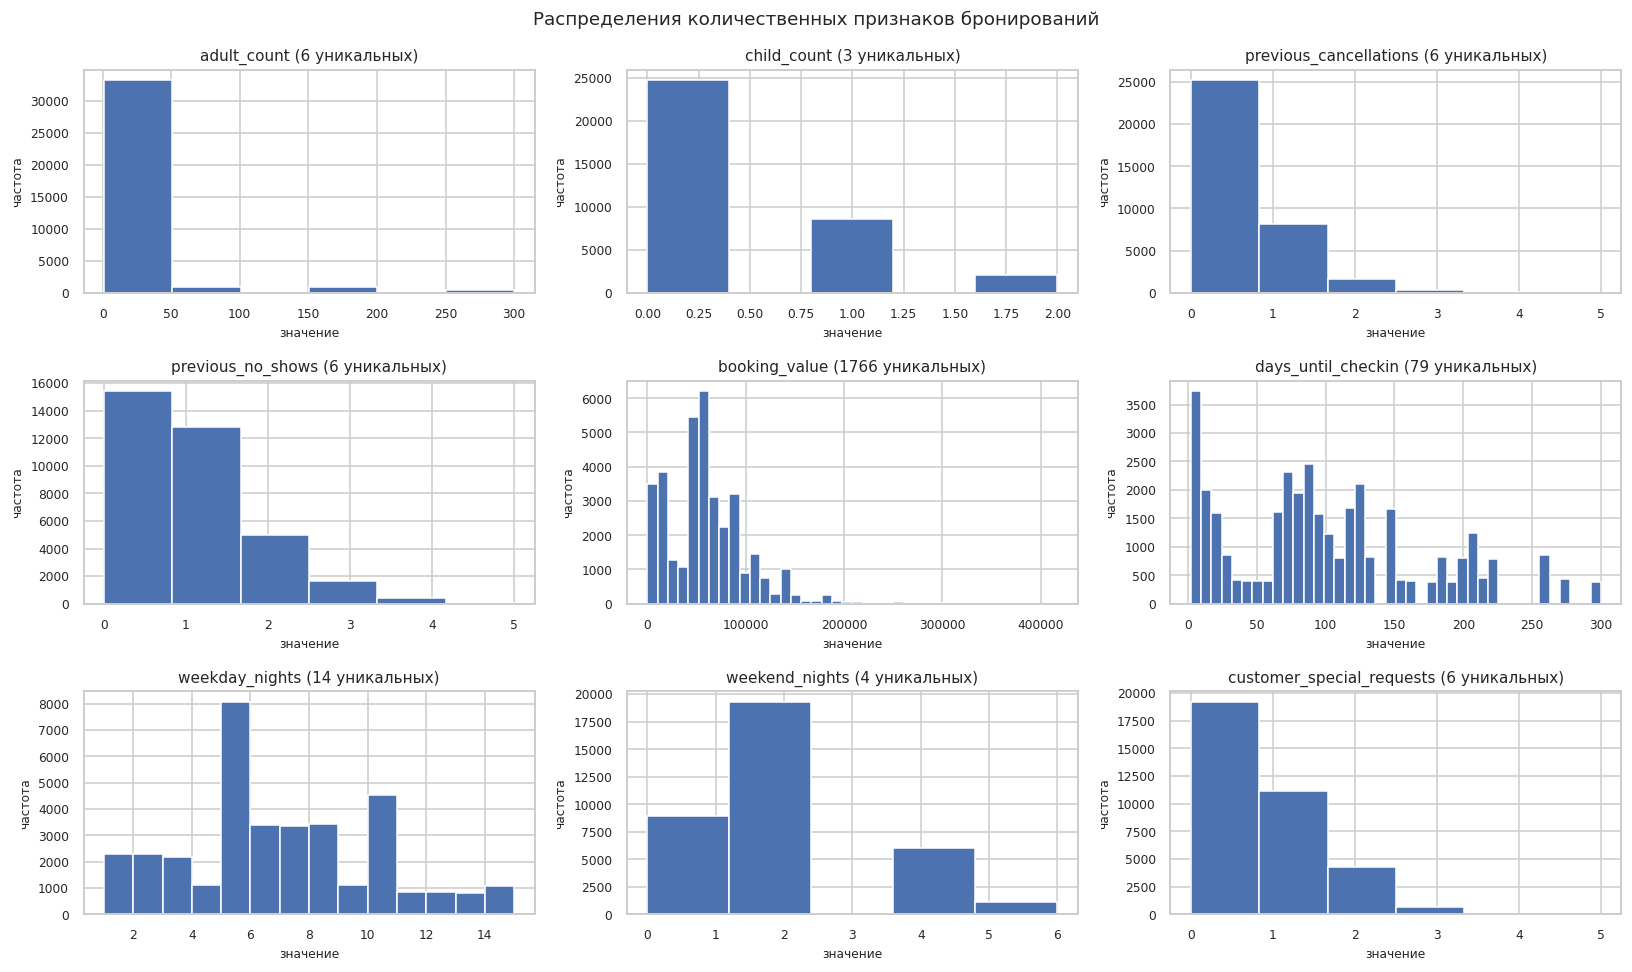

In [7]:
NUM_RAW = [
    "adult_count", "child_count", "previous_cancellations", "previous_no_shows",
    "booking_value", "days_until_checkin", "weekday_nights", "weekend_nights",
    "customer_special_requests",
]
display(bookings_raw[NUM_RAW].describe().T.round(2))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, column in zip(axes.ravel(), NUM_RAW):
    unique_values = bookings_raw[column].nunique()
    ax.hist(bookings_raw[column], bins=min(40, max(unique_values, 5)), color="#4C72B0")
    ax.set_title(f"{column} ({unique_values} уникальных)", fontsize=10)
    ax.set_xlabel("значение", fontsize=8)
    ax.set_ylabel("частота", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Распределения количественных признаков бронирований", fontsize=12)
fig.tight_layout()
plt.show()

#### Выбросы

Боксплоты показывают точки за усами, но не дают счётчика, поэтому рядом считаем сводку по правилу 1.5 IQR: границы уса, число и долю наблюдений за ним.

,p25,p75,нижний_ус,верхний_ус,за_усами,за_усами_%,максимум
признак,,,,,,,
adult_count,1.0000,3.0000,-2.0000,6.0000,2151,6.0900,300.0000
child_count,0.0000,1.0000,-1.5000,2.5000,0,0.0000,2.0000
previous_cancellations,0.0000,1.0000,-1.5000,2.5000,367,1.0400,5.0000
previous_no_shows,0.0000,1.0000,-1.5000,2.5000,2137,6.0500,5.0000
booking_value,"33,500.0000","80,400.0000","-36,850.0000","150,750.0000",1006,2.8500,"417,221.2000"
days_until_checkin,45.0000,144.0000,-103.5000,292.5000,375,1.0600,300.0000
weekday_nights,5.0000,9.0000,-1.0000,15.0000,0,0.0000,15.0000
weekend_nights,0.0000,2.0000,-3.0000,5.0000,1082,3.0600,6.0000
customer_special_requests,0.0000,1.0000,-1.5000,2.5000,706,2.0000,5.0000


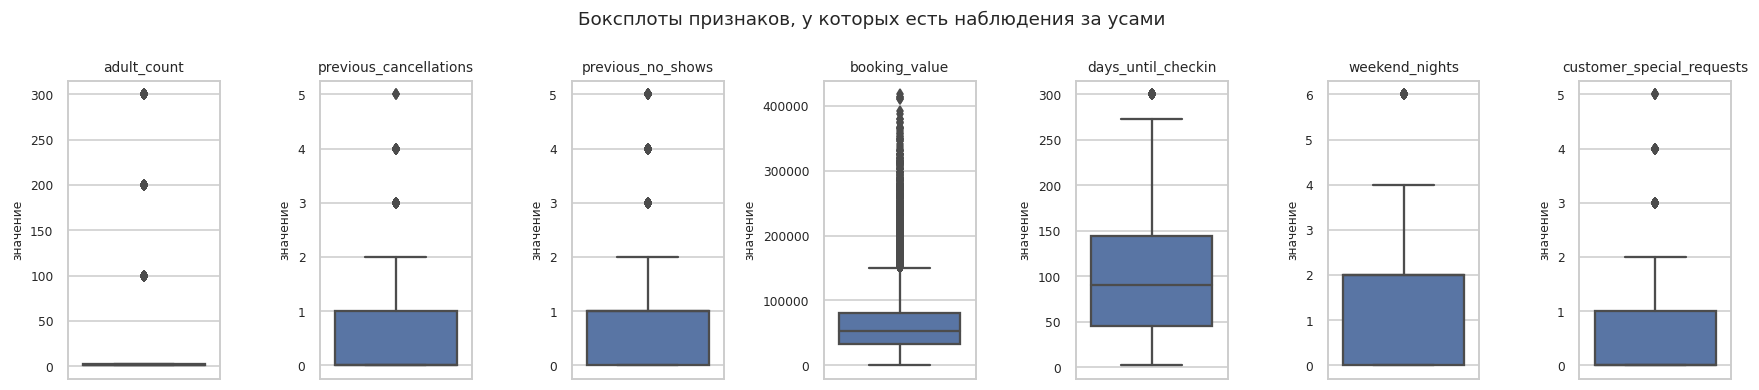

In [8]:
def iqr_summary(df, columns):
    """Сводка по правилу 1.5 IQR: границы усов и число наблюдений за ними."""
    rows = []
    for column in columns:
        series = df[column]
        q25, q75 = series.quantile([0.25, 0.75])
        iqr = q75 - q25
        low, high = q25 - 1.5 * iqr, q75 + 1.5 * iqr
        outliers = int(((series < low) | (series > high)).sum())
        rows.append([column, q25, q75, low, high, outliers,
                     round(outliers / len(series) * 100, 2), series.max()])
    return pd.DataFrame(
        rows,
        columns=["признак", "p25", "p75", "нижний_ус", "верхний_ус",
                 "за_усами", "за_усами_%", "максимум"],
    ).set_index("признак")


display(iqr_summary(bookings_raw, NUM_RAW))

# Боксплоты строим для всех признаков, у которых сводка нашла наблюдения за усами.
outlier_columns = ["adult_count", "previous_cancellations", "previous_no_shows",
                   "booking_value", "days_until_checkin", "weekend_nights",
                   "customer_special_requests"]
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(16, 3.6))
for ax, column in zip(axes, outlier_columns):
    sns.boxplot(y=bookings_raw[column], ax=ax, color="#4C72B0")
    ax.set_title(column, fontsize=9)
    ax.set_ylabel("значение", fontsize=8)
    ax.tick_params(labelsize=8)
fig.suptitle("Боксплоты признаков, у которых есть наблюдения за усами", fontsize=12)
fig.tight_layout()
plt.show()

#### Аномалии

Четыре находки требуют отдельной проверки: нереальное число взрослых в брони, нулевая стоимость, опечатка в справочнике питания и неявные пропуски, спрятанные под категорией «не выбран».

In [9]:
adult_counts = bookings_raw["adult_count"].value_counts().sort_index().to_frame("строк")
adult_counts["доля_%"] = (adult_counts["строк"] / len(bookings_raw) * 100).round(2)
adult_counts.index.name = "adult_count"
display(adult_counts.T)

zero_value = bookings_raw[bookings_raw["booking_value"] == 0]
not_selected = bookings_raw["meal_plan"].isin(["не выбран", "не выбрант"])
implicit_gaps = pd.DataFrame(
    [
        ["booking_value = 0", len(zero_value), round(len(zero_value) / len(bookings_raw) * 100, 2),
         "переводим в пропуск: минимальная ненулевая цена 6 700 руб."],
        ["meal_plan = «не выбран»", int(not_selected.sum()),
         round(not_selected.mean() * 100, 2),
         "оставляем категорией: это осмысленный ответ клиента, а не потеря данных"],
    ],
    columns=["неявный пропуск", "строк", "доля_%", "решение"],
).set_index("неявный пропуск")
display(implicit_gaps)

zero_stats = pd.DataFrame(
    [
        ["минимальная ненулевая стоимость", bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"].min()],
        ["доля отмен среди нулевых", round((zero_value["booking_status"] == "отказ_брони").mean(), 4)],
        ["доля отмен среди остальных",
         round((bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_status"] == "отказ_брони").mean(), 4)],
        ["медианная стоимость одной ночи, руб.",
         (bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"]
          / (bookings_raw["weekday_nights"] + bookings_raw["weekend_nights"])).median()],
        ["доля броней с ценой ровно 6 700 руб. за ночь, %",
         round(((bookings_raw.loc[bookings_raw["booking_value"] > 0, "booking_value"]
                 / (bookings_raw["weekday_nights"] + bookings_raw["weekend_nights"])
                 ).round(2) == 6700).mean() * 100, 2)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(zero_stats)

meal_plans = bookings_raw["meal_plan"].value_counts().to_frame("строк")
meal_plans.columns.name = "meal_plan"
display(meal_plans)

adult_count,1,2,3,100,200,300
строк,"13,361.0000","13,102.0000","6,727.0000",884.0000,872.0000,395.0000
доля_%,37.8100,37.0700,19.0300,2.5000,2.4700,1.1200


,строк,доля_%,решение
неявный пропуск,,,
booking_value = 0,1421,4.0200,переводим в пропуск: минимальная ненулевая цен...
meal_plan = «не выбран»,4933,13.9600,оставляем категорией: это осмысленный ответ кл...


,значение
показатель,
минимальная ненулевая стоимость,"6,700.0000"
доля отмен среди нулевых,0.2892
доля отмен среди остальных,0.2875
"медианная стоимость одной ночи, руб.","6,700.0000"
"доля броней с ценой ровно 6 700 руб. за ночь, %",74.2300


meal_plan,строк
тип_питания_1,27182
не выбран,4426
тип_питания_2,3219
не выбрант,507
тип_питания_3,7


#### Категориальные признаки

Для каждой категории смотрим наполненность и долю отмен: именно разница долей показывает, несёт ли признак сигнал о целевой переменной. Графики строим по всем семи признакам, а не выборочно, и рядом показываем размер каждой группы - без него разница долей на маленьких категориях вводит в заблуждение.

броней  доля_отмен_%
признак                значение                                        
sales_channel          корпоративное_бронирование   11747       16.7900
                       онлайн_бронирование          11554       41.4200
                       офлайн_бронирование          12040       28.2900
meal_plan              не выбран                     4426       28.9900
                       не выбрант                     507       31.3600
                       тип_питания_1                27182       28.7400
                       тип_питания_2                 3219       28.1800
                       тип_питания_3                    7       28.5700
room_type              тип_1                        27197       29.0300
                       тип_2                          658       27.5100
                       тип_3                           10       30.0000
                       тип_4                         6070       28.1400
                       тип_5                          272       25.3700
                       тип_6                          959       27.4200
                       тип_7                          175       26.2900
returning_customer     False                        15413       29.2600
                       True                         19928       28.3700
parking_included       False                        34165       28.6800
                       True                          1176       31.2100
previous_cancellations 0                            25152       25.2300
                       1                             8198       35.0800
                       2                             1624       45.3800
                       3                              304       58.8800
                       4                               59       38.9800
                       5                                4      100.0000
child_count            0                            24683       31.8400
                       1                             8629       15.8500
                       2                             2029       46.1800

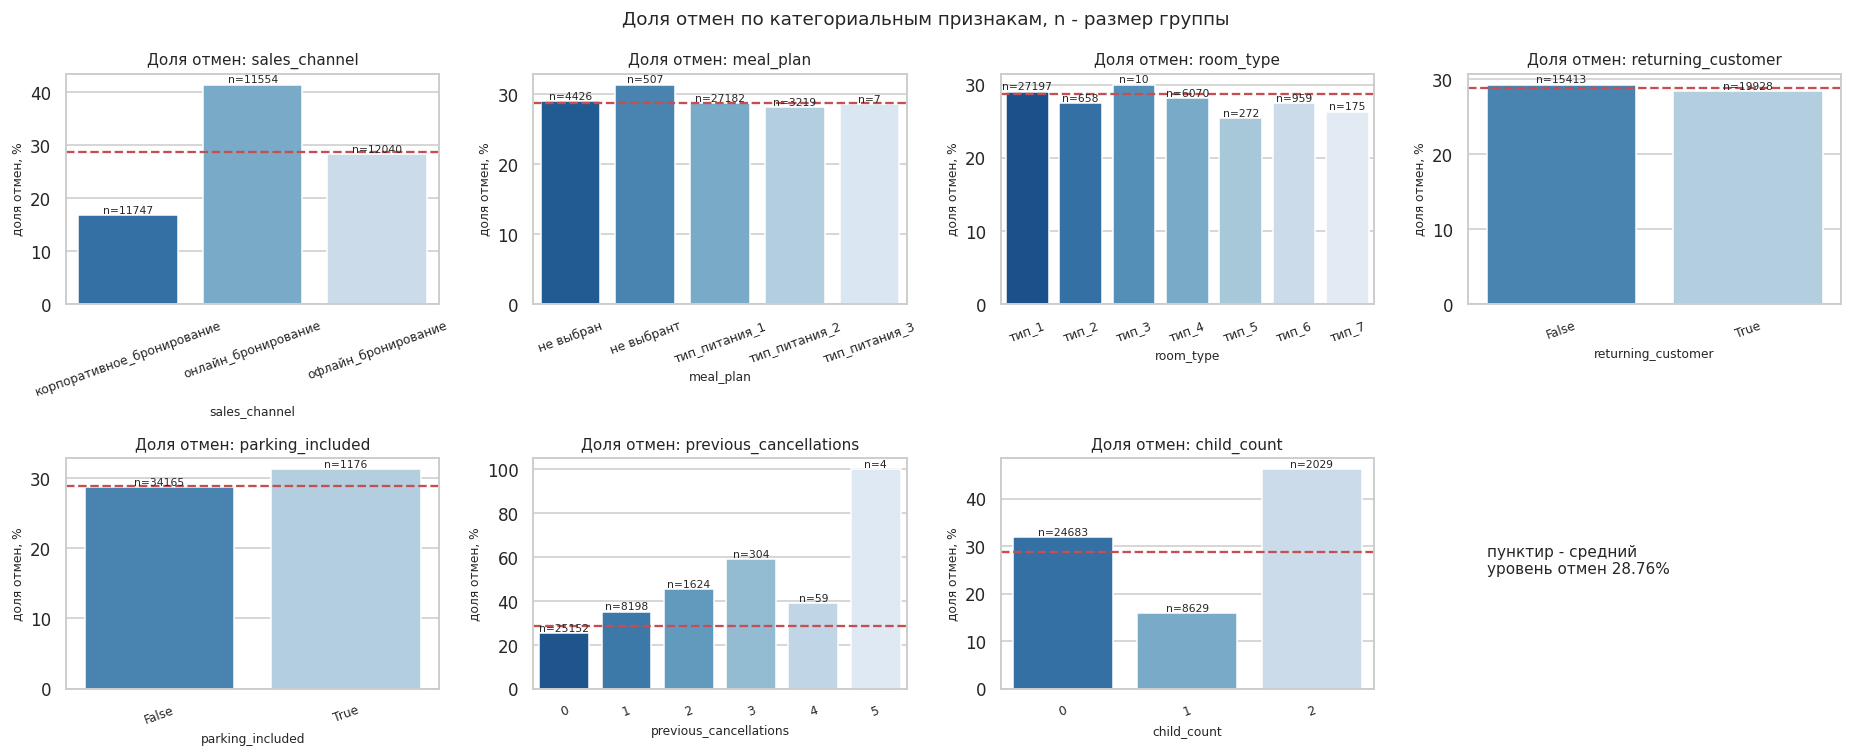

In [10]:
CAT_RAW = ["sales_channel", "meal_plan", "room_type", "returning_customer",
           "parking_included", "previous_cancellations", "child_count"]
cancel_flag = (bookings_raw["booking_status"] == "отказ_брони").astype(int)

cat_report = []
for column in CAT_RAW:
    grouped = cancel_flag.groupby(bookings_raw[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index()
    grouped.insert(0, "признак", column)
    grouped = grouped.rename(columns={column: "значение"})
    grouped["значение"] = grouped["значение"].astype(str)
    cat_report.append(grouped)
cat_report = pd.concat(cat_report, ignore_index=True).set_index(["признак", "значение"])
display(cat_report)

fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, column in zip(axes.ravel(), CAT_RAW):
    grouped = cancel_flag.groupby(bookings_raw[column]).agg(["size", "mean"])
    rates = grouped["mean"] * 100
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, palette="Blues_r")
    ax.axhline(cancel_flag.mean() * 100, color="#C44E52", linestyle="--")
    for position, (value, size) in enumerate(zip(rates.values, grouped["size"].values)):
        ax.text(position, value, f"n={size}", ha="center", va="bottom", fontsize=7)
    ax.set_title(f"Доля отмен: {column}", fontsize=10)
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("доля отмен, %", fontsize=8)
    ax.tick_params(labelsize=8, axis="x", rotation=20)
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(0.05, 0.5, "пунктир - средний\nуровень отмен 28.76%", fontsize=10)
fig.suptitle("Доля отмен по категориальным признакам, n - размер группы", fontsize=12)
fig.tight_layout()
plt.show()

#### Связь количественных признаков с отменой

Корреляция Пирсона с бинарной целевой переменной показывает силу монотонной связи, а средние значения в разрезе статуса - её направление.

,корреляция_с_отменой,нет_отказа,отказ_брони
days_until_checkin,0.2824,87.6300,132.4700
previous_cancellations,0.1363,0.3000,0.4900
weekday_nights,-0.0751,6.6900,6.1400
weekend_nights,-0.0670,2.0200,1.8000
booking_value,-0.0582,"63,217.5800","57,711.5500"
child_count,-0.0433,0.3800,0.3200
previous_no_shows,-0.0297,0.8600,0.8000
customer_special_requests,-0.0081,0.6300,0.6100
adult_count,0.0051,12.3300,12.8500


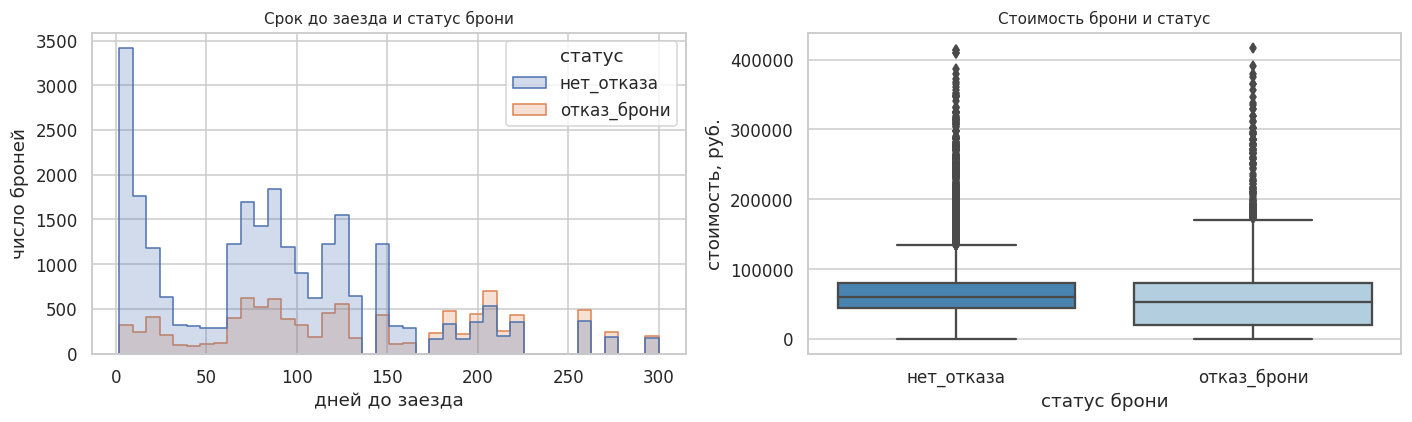

In [11]:
corr_target = (
    bookings_raw[NUM_RAW]
    .assign(is_cancelled=cancel_flag)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
means_by_status = bookings_raw.groupby("booking_status")[NUM_RAW].mean().T.round(2)
display(corr_target.join(means_by_status))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=bookings_raw.assign(статус=bookings_raw["booking_status"]),
             x="days_until_checkin", hue="статус", bins=40, ax=axes[0], element="step")
axes[0].set_title("Срок до заезда и статус брони", fontsize=10)
axes[0].set_xlabel("дней до заезда")
axes[0].set_ylabel("число броней")
sns.boxplot(data=bookings_raw, x="booking_status", y="booking_value", ax=axes[1], palette="Blues_r")
axes[1].set_title("Стоимость брони и статус", fontsize=10)
axes[1].set_xlabel("статус брони")
axes[1].set_ylabel("стоимость, руб.")
fig.tight_layout()
plt.show()

#### Таблица отзывов

Смотрим распределение оценок, длину и повторяемость текстов, период наблюдений.

stay_rating,отзывов,доля_%
2,523,2.0800
3,14336,56.9400
4,10160,40.3500
5,158,0.6300


,минимум,максимум
поле,,
hotel_bookings.booking_date,2017-01-01,2025-10-22
hotel_reviews.review_date,2017-01-17,2026-03-03


,значение
показатель,
отзывов всего,"25,177.0000"
уникальных текстов,"14,153.0000"
"доля повторяющихся текстов, %",43.7900
"медианная длина текста, символов",95.0000
"максимальная длина текста, символов",225.0000
уникальных дат отзывов,"2,514.0000"


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...


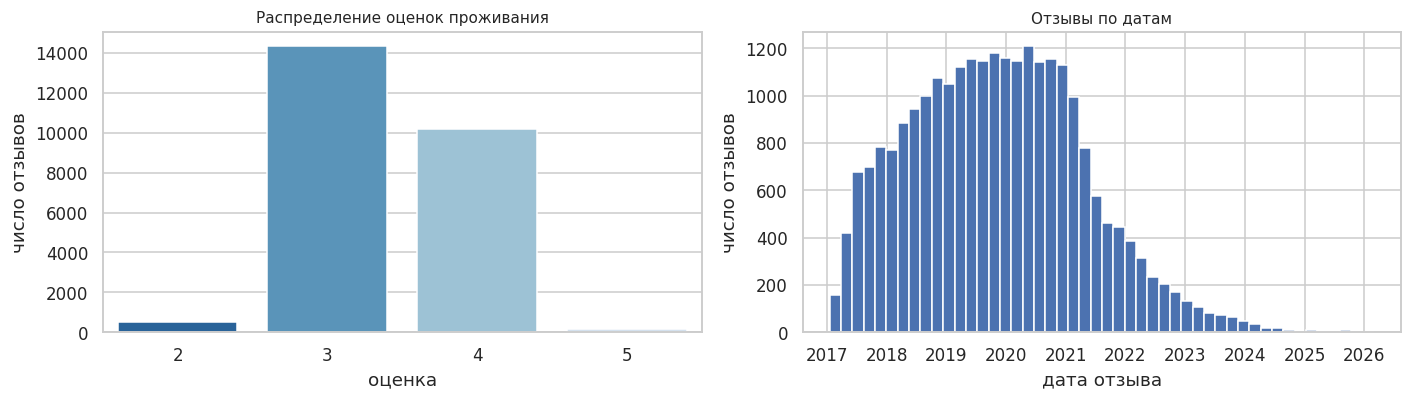

In [12]:
ratings = (
    reviews_raw["stay_rating"].value_counts().sort_index().to_frame("отзывов")
    .assign(**{"доля_%": lambda d: (d["отзывов"] / len(reviews_raw) * 100).round(2)})
)
ratings.columns.name = "stay_rating"
display(ratings)

review_dates = pd.to_datetime(reviews_raw["review_date"])
booking_dates = pd.to_datetime(bookings_raw["booking_date"])
periods = pd.DataFrame(
    [
        ["hotel_bookings.booking_date", booking_dates.min(), booking_dates.max()],
        ["hotel_reviews.review_date", review_dates.min(), review_dates.max()],
    ],
    columns=["поле", "минимум", "максимум"],
).set_index("поле")
display(periods)

text_stats = pd.DataFrame(
    [
        ["отзывов всего", len(reviews_raw)],
        ["уникальных текстов", reviews_raw["review_text"].nunique()],
        ["доля повторяющихся текстов, %",
         round((1 - reviews_raw["review_text"].nunique() / len(reviews_raw)) * 100, 2)],
        ["медианная длина текста, символов", reviews_raw["review_text"].str.len().median()],
        ["максимальная длина текста, символов", reviews_raw["review_text"].str.len().max()],
        ["уникальных дат отзывов", review_dates.nunique()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(text_stats)
display(reviews_raw[["customer_id", "booking_id", "review_date", "stay_rating", "review_text"]].head(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.countplot(x=reviews_raw["stay_rating"], ax=axes[0], palette="Blues_r")
axes[0].set_title("Распределение оценок проживания", fontsize=10)
axes[0].set_xlabel("оценка")
axes[0].set_ylabel("число отзывов")
axes[1].hist(review_dates, bins=48, color="#4C72B0")
axes[1].set_title("Отзывы по датам", fontsize=10)
axes[1].set_xlabel("дата отзыва")
axes[1].set_ylabel("число отзывов")
fig.tight_layout()
plt.show()

#### Проверка связи таблиц: где прячется утечка целевой переменной

В `hotel_bookings` нет `customer_id`, поэтому единственный способ узнать клиента - подтянуть его из `hotel_reviews` по `booking_id`. Прежде чем так делать, проверяем, как наличие отзыва связано со статусом брони.

booking_status,нет_отказа,отказ_брони
отзывов по брони,,
0,0,8850
1,18858,0
2,2776,0
3,229,0
4,20,0


,значение
показатель,
уникальных booking_id в бронированиях,30733
из них есть в таблице отзывов,21883
"booking_id из отзывов, которых нет в бронированиях",0
уникальных клиентов в отзывах,13429


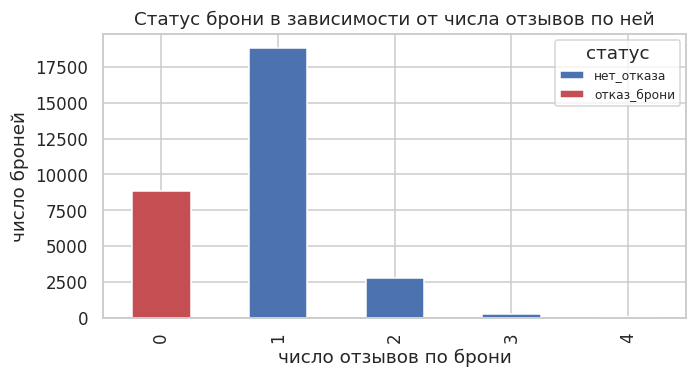

In [13]:
bookings_unique = bookings_raw.drop_duplicates()
reviews_per_booking = reviews_raw.groupby("booking_id").size()
leak_check = pd.crosstab(
    bookings_unique["booking_id"].map(reviews_per_booking).fillna(0).astype(int),
    bookings_unique["booking_status"],
)
leak_check.index.name = "отзывов по брони"
display(leak_check)

coverage = pd.DataFrame(
    [
        ["уникальных booking_id в бронированиях", bookings_unique["booking_id"].nunique()],
        ["из них есть в таблице отзывов", bookings_unique["booking_id"].isin(reviews_raw["booking_id"]).sum()],
        ["booking_id из отзывов, которых нет в бронированиях",
         int((~reviews_raw["booking_id"].isin(bookings_raw["booking_id"])).sum())],
        ["уникальных клиентов в отзывах", reviews_raw["customer_id"].nunique()],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(coverage)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
leak_check.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Статус брони в зависимости от числа отзывов по ней")
ax.set_xlabel("число отзывов по брони")
ax.set_ylabel("число броней")
ax.legend(title="статус", fontsize=8)
fig.tight_layout()
plt.show()

#### Предобработка

Исправляем найденные дефекты функциями `clean_bookings` и `clean_reviews` из модуля `feature_pipeline`:

- удаляем полные дубли строк;
- делим на 100 значения `adult_count` вида 100/200/300 - это ошибка ввода лишних нулей;
- сводим опечатку `не выбрант` к категории `не выбран`;
- переводим нулевую стоимость брони в пропуск, чтобы её заполнил импьютер по медиане обучающей выборки;
- приводим даты к `datetime`, булевы поля - к 0/1 и создаём целевую переменную `is_cancelled`.

Исправления - доменные (ошибки ввода), они не используют статистику выборки, поэтому применяются до разделения на train/test и утечки не создают.

In [14]:
bookings = fp.clean_bookings(bookings_raw)
reviews = fp.clean_reviews(reviews_raw)

prep_report = pd.DataFrame(
    [
        ["строк в hotel_bookings", len(bookings_raw), len(bookings)],
        ["строк в hotel_reviews", len(reviews_raw), len(reviews)],
        ["adult_count >= 10", int((bookings_raw["adult_count"] >= 10).sum()),
         int((bookings["adult_count"] >= 10).sum())],
        ["категорий meal_plan", bookings_raw["meal_plan"].nunique(), bookings["meal_plan"].nunique()],
        ["пропусков в booking_value", int(bookings_raw["booking_value"].isna().sum()),
         int(bookings["booking_value"].isna().sum())],
    ],
    columns=["показатель", "до_предобработки", "после_предобработки"],
).set_index("показатель")
display(prep_report)

display(bookings[["adult_count", "booking_value"]].describe().T.round(2))
display(bookings["is_cancelled"].value_counts(normalize=True).round(4).to_frame("доля"))

,до_предобработки,после_предобработки
показатель,,
строк в hotel_bookings,35341,30733
строк в hotel_reviews,25177,25177
adult_count >= 10,2151,0
категорий meal_plan,5,4
пропусков в booking_value,0,1229


,count,mean,std,min,25%,50%,75%,max
adult_count,"30,733.0000",1.8000,0.7500,1.0000,1.0000,2.0000,2.0000,3.0000
booking_value,"29,504.0000","64,248.4400","41,683.1400","6,700.0000","46,900.0000","60,300.0000","89,000.0000","417,221.2000"


,доля
0,0.7120
1,0.2880


### Выводы по исследовательскому анализу

**Качество данных**

- **Явных пропусков (NaN) нет ни в одной таблице**, но есть неявные: у **1 421 брони (4.02%)** стоимость равна нулю при минимальной ненулевой цене 6 700 руб., и у **4 933 броней (13.96%)** тип питания «не выбран». Первое - незаполненное поле, второе - осмысленный ответ клиента, поэтому решения разные: ноль переводим в пропуск, «не выбран» оставляем категорией.
- В `hotel_bookings` **4 608 полных дублей строк** (13.0% таблицы): `booking_id` повторяется до четырёх раз, но внутри каждой группы дублей все 16 столбцов имеют ровно одно уникальное значение. Это технические копии, а не конфликт данных, поэтому дубли удалены: осталось **30 733 уникальных брони**.
- В `hotel_reviews` полных дублей нет, но есть **130 повторов пары `booking_id` + `review_date`** (260 строк). Проверка на конфликт: внутри пары всегда один клиент, но до двух разных оценок и до двух разных текстов. Значит это действительно разные отзывы одного гостя, оставленные в один день, а не противоречивые записи об одном отзыве - удалять их нельзя.

**Аномалии и их исправление**

- `adult_count` принимает значения **100 (884 строки, 2.50%), 200 (872, 2.47%) и 300 (395, 1.12%)** - суммарно 2 151 запись, 6.09% таблицы. Столько взрослых в одном номере невозможно, а частоты этих значений пропорциональны частотам 1 / 2 / 3 (37.81%, 37.07%, 19.03%), то есть это ошибка ввода лишних нулей. Значения поделены на 100, после чего максимум `adult_count` стал равен 3.
- Нулевая стоимость с целевой переменной не связана: доля отмен среди таких броней 28.92% против 28.75% у остальных. Нули переведены в пропуски и заполняются медианой обучающей выборки.
- В справочнике питания опечатка: категория **`не выбрант` (507 строк)** сведена к `не выбран`, число категорий уменьшилось с 5 до 4.
- Выбросы по правилу 1.5 IQR: `booking_value` - 1 006 наблюдений (2.85%, максимум 417 221 руб.), `weekend_nights` - 1 082 (3.06%), `previous_no_shows` - 2 137 (6.05%). Это правдоподобные значения (дорогие длительные брони и постоянные гости), поэтому они сохранены. Единственные выбросы, которые были ошибкой, - те самые 2 151 запись по `adult_count`.
- **Тариф в данных почти постоянный**: медианная стоимость ночи - 6 700 руб., и ровно столько стоит ночь у **74.23%** броней. Поэтому стоимость почти не несёт информации сверх длительности проживания.

**Целевая переменная, время и связи с признаками**

- Доля отмен - **28.76%** (10 164 отмены из 35 341). Дисбаланс умеренный, но заметный, поэтому accuracy неинформативна, а разбиение выборок делается со стратификацией.
- **Премисса заказчика о росте отмен в последние два года данными не подтверждается: тренд есть, но противоположный.** Доля отмен держалась на уровне 29-30% в 2017-2020 годах (29.66%, 29.12%, 29.55%, 29.83%) и затем снижалась: 24.37% в 2021, 22.86% в 2022, 19.30% в 2023 - падение примерно на 10 процентных пунктов. При этом объём выгрузки после 2020 обрывается: с 8 668 броней в 2020 до 373 в 2023 и 20 в 2025, то есть на годы после 2020 приходится 4 669 броней из 35 341, около 13% выгрузки.
- **Разбиение выборок остаётся случайным, и не потому, что тренда нет.** Причина в другом: ТЗ оценивает эффект на тестовой выборке того же периода, а временное разбиение отдало бы под тест именно тот хвост в 13% строк, где базовая доля отмен другая, - оценка перестала бы быть сопоставимой с требованиями заказчика. Ограничение фиксируем явно: `booking_year` входит в признаки, поэтому на будущих годах модель выходит за обученный диапазон и требует переобучения.
- **Сезонности спроса в данных тоже нет**: заезды распределены по месяцам практически равномерно, от 7.79% (февраль) до 8.87% (май).
- Сильнее всего с отменой связан **срок до заезда**: корреляция 0.282, средний срок у отменённых броней 132 дня против 88 у состоявшихся.
- **Канал продаж** разделяет клиентов лучше всех категорий: онлайн-бронирования отменяются в **41.42%** случаев, офлайн - в 28.29%, корпоративные - в **16.79%**.
- **История клиента работает монотонно**: без прошлых отмен - 25.23% отмен, с одной - 35.08%, с двумя - 45.38%, с тремя - 58.88%.
- **Число детей влияет немонотонно**: 31.84% отмен без детей, 15.85% с одним ребёнком и 46.18% с двумя. Признак стоит оставить в исходном виде, а не превращать в бинарный флаг.
- Тип номера и тип питания почти не различают классы: разброс долей отмен 25-31% при среднем 28.76%, причём самые крайние значения посчитаны на единицах наблюдений - `тип_3` встречается 10 раз, `тип_питания_3` - 7 раз.

**Отзывы**

- Оценки лежат в диапазоне **от 2 до 5, оценки 1 в данных нет**; 56.94% отзывов имеют оценку 3, 40.35% - оценку 4. Тексты короткие (медиана 95 символов) и сильно повторяются: **43.79% текстов не уникальны**, 14 153 разных текста на 25 177 отзывов.
- Период отзывов (2017-01-17 - 2026-03-03) выходит за правую границу периода броней (2017-01-01 - 2025-10-22). Это не «сироты»: записей из отзывов, которых нет в бронированиях, ровно **0**. Причина в том, что отзыв оставляют после заезда, а заезд наступает до 300 дней спустя после оформления брони.

**Главная находка: отзыв однозначно выдаёт статус брони**

Кросс-таблица «число отзывов по брони» против статуса не оставляет вариантов:

- у **8 850 броней отзывов нет, и все они отменены**;
- у **21 883 броней есть хотя бы один отзыв, и ни одна из них не отменена**.

Это логично: отзыв оставляет тот, кто заселился. Но практический вывод жёсткий: **связывать таблицы по клиенту нельзя**. `customer_id` есть только в отзывах, добраться до него можно лишь через `booking_id`, а сам факт такой связи равносилен ответу «бронь состоялась». Проверка этого утверждения числами - в следующем разделе.

**Итог:** данные полные, без явных пропусков, но требуют трёх исправлений (дубли, ошибка ввода в `adult_count`, нули в `booking_value`) и одного принципиального решения - объединять таблицы только по дате, без ключа клиента.

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

Правило объединения из задания - «к дате брони подтянуть ближайший предшествующий по дате отзыв». Прежде чем реализовать его, проверяем буквальный вариант ТЗ - связь по клиенту - и смотрим, что из него получается.

In [15]:
# Буквальный вариант ТЗ: восстанавливаем клиента по booking_id и берём его предыдущий отзыв.
customer_map = reviews[["booking_id", "customer_id"]].drop_duplicates("booking_id")
bookings_with_customer = bookings.merge(customer_map, on="booking_id", how="left")

per_customer = pd.merge_asof(
    bookings_with_customer.sort_values("booking_date"),
    reviews.sort_values("review_date")[["customer_id", "review_date", "stay_rating"]],
    left_on="booking_date",
    right_on="review_date",
    by="customer_id",
    direction="backward",
    allow_exact_matches=False,
)

leak_demo = pd.crosstab(
    np.where(per_customer["customer_id"].isna(), "клиент не найден", "клиент найден"),
    np.where(per_customer["is_cancelled"] == 1, "отказ_брони", "нет_отказа"),
)
leak_demo.index.name = "результат связи по клиенту"
display(leak_demo)

leak_rates = pd.DataFrame(
    [
        ["клиент найден через booking_id", int(per_customer["customer_id"].notna().sum()),
         round(per_customer.loc[per_customer["customer_id"].notna(), "is_cancelled"].mean() * 100, 2)],
        ["клиент не найден", int(per_customer["customer_id"].isna().sum()),
         round(per_customer.loc[per_customer["customer_id"].isna(), "is_cancelled"].mean() * 100, 2)],
    ],
    columns=["группа", "броней", "доля_отмен_%"],
).set_index("группа")
display(leak_rates)

col_0,нет_отказа,отказ_брони
результат связи по клиенту,,
клиент найден,21883,0
клиент не найден,0,8850


,броней,доля_отмен_%
группа,,
клиент найден через booking_id,21883,0.0000
клиент не найден,8850,100.0000


Связь по клиенту делит выборку ровно по целевой переменной: у всех броней, для которых клиент нашёлся, доля отмен 0%, у всех остальных - 100%. Причина в устройстве данных: `customer_id` есть только в таблице отзывов, а отзыв оставляет тот, кто заселился. Значит любой признак, полученный этим путём - включая сам факт «клиент найден», - это ответ, а не сигнал: модель показала бы почти идеальное качество на истории и не работала бы в проде, где статус брони ещё неизвестен.

Поэтому объединение выполняется только по времени: `pd.merge_asof(direction="backward", allow_exact_matches=False)` берёт последний отзыв, оставленный строго до даты оформления брони. Такой признак известен отелю в момент прогноза и утечки не создаёт. Плата за это - отзыв относится к чужой поездке, и одна и та же запись достаётся всем броням одного дня; насколько это ограничивает пользу признака, видно из таблицы ниже.

In [16]:
data = fp.add_demand_features(fp.join_reviews(bookings, reviews))

join_report = pd.DataFrame(
    [
        ["строк до объединения", len(bookings)],
        ["строк после объединения", len(data)],
        ["броней без предшествующего отзыва", int(data["stay_rating"].isna().sum())],
        ["доля броней без отзыва, %", round(data["stay_rating"].isna().mean() * 100, 2)],
        ["медианный лаг «отзыв -> бронь», дней", data["review_lag_days"].median()],
        ["максимальный лаг «отзыв -> бронь», дней", data["review_lag_days"].max()],
        ["уникальных отзывов, попавших в признаки", data["review_text"].nunique()],
        ["отзывов в исходной таблице", len(reviews)],
        ["броней на один подтянутый отзыв",
         round(len(data) / max(data["review_text"].nunique(), 1), 1)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель")
display(join_report)

# Контроль корректности asof-соединения: дата отзыва строго раньше даты брони,
# а число строк совпадает с числом броней (дублирования при соединении нет).
assert len(data) == len(bookings)
assert (data["review_lag_days"].dropna() >= 1).all()

display(data[["booking_date", "review_date", "review_lag_days", "stay_rating", "review_text"]]
        .dropna(subset=["review_date"]).head())

rating_vs_target = data.groupby("stay_rating")["is_cancelled"].agg(["size", "mean"])
rating_vs_target.columns = ["броней", "доля_отмен"]
rating_vs_target["доля_отмен_%"] = (rating_vs_target["доля_отмен"] * 100).round(2)
display(rating_vs_target.drop(columns="доля_отмен"))

,значение
показатель,
строк до объединения,"30,733.0000"
строк после объединения,"30,733.0000"
броней без предшествующего отзыва,194.0000
"доля броней без отзыва, %",0.6300
"медианный лаг «отзыв -> бронь», дней",1.0000
"максимальный лаг «отзыв -> бронь», дней",35.0000
"уникальных отзывов, попавших в признаки","2,033.0000"
отзывов в исходной таблице,"25,177.0000"
броней на один подтянутый отзыв,15.1000


,booking_date,review_date,review_lag_days,stay_rating,review_text
194,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
195,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
196,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
197,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...
198,2017-01-18,2017-01-17,1.0000,4.0000,Отличный отель! разнообразное меню в ресторане...


,броней,доля_отмен_%
stay_rating,,
2.0000,533,27.9500
3.0000,18092,28.7500
4.0000,11733,28.8800
5.0000,181,28.7300


**Выводы по объединению таблиц**

**Буквальный вариант ТЗ проверен и отвергнут числами.** Связь по клиенту через `booking_id` делит выборку ровно по целевой переменной: среди 21 883 броней, для которых клиент нашёлся, доля отмен **0.00%**, среди 8 850 остальных - **100.00%**. Признак «клиент найден» - это ответ, а не сигнал.

**Реализовано объединение по времени:**

- `pd.merge_asof(direction="backward", allow_exact_matches=False)` берёт последний отзыв, оставленный строго до даты оформления брони;
- число строк не изменилось - **30 733 до и после соединения**, дублирования при join нет (проверено `assert`), лаг «отзыв - бронь» везде не меньше одного дня (тоже `assert`);
- без предшествующего отзыва осталось **194 записи (0.63%)** - самые ранние брони января 2017 года. Их `stay_rating` и `review_lag_days` заполнит импьютер.

**Ограничение полученного признака нужно назвать прямо.** Отзывы приходят почти ежедневно: медианный лаг - **1 день**, максимальный - 35. Поэтому всем броням одного дня достаётся один и тот же отзыв: в признаки попали **2 033 уникальных текста** - **14.4%** от 14 153 разных текстов таблицы отзывов и **8.1%** от всех 25 177 отзывов, в среднем **15.1 брони на один подтянутый отзыв**. По сути это характеристика календарного дня, а не конкретной брони.

Проверка на сигнал подтверждает: доля отмен по подтянутой оценке лежит в коридоре **27.95-28.88%** при среднем уровне 28.80%. Связи между оценкой предыдущего гостя и отменой текущей брони нет.

**Итог:** соединение выполнено корректно и без потери строк, но признаки из отзывов при честном правиле объединения близки к шуму. Это следствие устройства данных: отзыв относится к чужой поездке, а внутри дня он один на всех.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

Признаки собираются функцией `build_features` из `feature_pipeline.py`.

**Признаки по данным о брони:**

| Признак | Логика |
|---|---|
| `total_nights` | общая длительность проживания, сумма будних и выходных ночей |
| `weekend_share` | доля выходных ночей: отличает деловые поездки от отдыха |
| `guests_total` | общее число гостей, взрослые плюс дети |
| `price_per_night` | стоимость одной ночи, сопоставимая цена для броней разной длительности |
| `customer_loyalty` | **лояльность клиента** из ТЗ: доля состоявшихся заездов среди прошлых бронирований, $(no\_shows + 1) / (no\_shows + cancellations + 2)$; сглаживание даёт новым клиентам нейтральные 0.5 |
| `checkin_month`, `checkin_dayofweek` | месяц и день недели планируемого заезда, восстановлены из даты брони и срока до заезда |
| `booking_month`, `booking_year` | момент оформления брони |
| `season_group` | **категоризация сезонности**: лето и декабрь, межсезонье (февраль, март, октябрь, ноябрь), прочие месяцы |
| `lead_time_group` | **категоризация срока до заезда**: до месяца, 1-3 месяца, 3-6 месяцев, более полугода |

**Признаки спроса** (проверяются отдельной гипотезой на этапе моделирования): `same_checkin_prior_bookings` - сколько броней на ту же дату заезда уже оформлено к моменту текущей, `bookings_prev_30d` - активность бронирования за предыдущие 30 дней. Обе величины считаются только по ранее оформленным броням, поэтому доступны в момент прогноза.

**Признаки из отзывов:** `stay_rating` и `review_lag_days` подтягиваются объединением, а тексты векторизует `TfidfVectorizer` внутри препроцессора - 60 самых частотных слов длиной от трёх букв, встречающихся минимум в 50 отзывах. Векторизатор обучается только на обучающей части, в том числе внутри каждого фолда кросс-валидации.

Пары признаков, из которых собраны производные, из набора убраны, чтобы не оставлять точные линейные зависимости: `weekday_nights` и `weekend_nights` заменены на `total_nights` + `weekend_share`, `adult_count` - на `guests_total` (вместе с сохранённым `child_count` это то же самое количество информации), `booking_value` - на `price_per_night`. `customer_loyalty` - нелинейное преобразование, а `season_group` и `lead_time_group` - категоризация, поэтому они сосуществуют с исходными счётчиками и сроком до заезда.

,столбцов,состав
группа,,
создано по данным о брони,11,"total_nights, weekend_share, guests_total, pri..."
создано по отзывам,2,"stay_rating, review_lag_days"
взято из исходной таблицы без изменений,10,"days_until_checkin, child_count, previous_canc..."
текстовое поле,1,review_text
признаки спроса (проверяются гипотезой),2,"same_checkin_prior_bookings, bookings_prev_30d"
итого базовый набор,24,без признаков спроса
итого с признаками спроса,26,оба набора разбиваются на выборки одинаково


,days_until_checkin,total_nights,weekend_share,guests_total,child_count,price_per_night,previous_cancellations,previous_no_shows,customer_loyalty,customer_special_requests,returning_customer,parking_included,checkin_month,checkin_dayofweek,booking_month,booking_year,stay_rating,review_lag_days,sales_channel,meal_plan,room_type,season_group,lead_time_group,review_text
0,79,11,0.1818,2,0,"6,700.0000",1,1,0.5000,2,1,0,3,1,1,2017,NaN,NaN,офлайн_бронирование,тип_питания_1,тип_1,межсезонье,1-3_месяца,
1,87,16,0.2500,2,0,"10,397.7125",0,0,0.5000,0,0,0,3,2,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_2,тип_1,межсезонье,1-3_месяца,
2,85,10,0.2000,3,0,"8,900.0000",0,0,0.5000,1,0,0,3,0,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_1,тип_1,межсезонье,1-3_месяца,
3,63,1,0.0000,3,0,"6,700.0000",0,0,0.5000,1,0,0,3,6,1,2017,NaN,NaN,корпоративное_бронирование,тип_питания_1,тип_4,межсезонье,1-3_месяца,
4,124,10,0.2000,5,2,"6,700.0000",0,0,0.5000,0,0,0,5,4,1,2017,NaN,NaN,онлайн_бронирование,тип_питания_2,тип_2,прочие_месяцы,3-6_месяцев,


,count,mean,std,min,25%,50%,75%,max
total_nights,"30,733.0000",8.4910,4.7190,1.0000,5.0000,8.0000,11.0000,21.0000
weekend_share,"30,733.0000",0.1860,0.1140,0.0000,0.0000,0.2220,0.2860,0.2860
guests_total,"30,733.0000",2.1560,0.9510,1.0000,1.0000,2.0000,3.0000,5.0000
price_per_night,"29,504.0000","7,564.2910","2,167.8880","6,700.0000","6,700.0000","6,700.0000","6,700.0000","19,995.3500"
customer_loyalty,"30,733.0000",0.5620,0.1210,0.1670,0.5000,0.5000,0.6670,0.8570
review_lag_days,"30,539.0000",1.0320,0.5810,1.0000,1.0000,1.0000,1.0000,35.0000


,count,mean,std,min,25%,50%,75%,max
same_checkin_prior_bookings,"30,733.0000",8.2500,6.3400,0.0000,3.0000,7.0000,13.0000,38.0000
bookings_prev_30d,"30,733.0000",491.0300,154.6300,0.0000,413.0000,560.0000,602.0000,671.0000


броней  доля_отмен_%
признак         значение                            
season_group    лето_и_декабрь   10346       28.3600
                межсезонье       10112       28.3900
                прочие_месяцы    10275       29.6400
lead_time_group 1-3_месяца        8634       25.6800
                3-6_месяцев       9646       26.7500
                более_полугода    5351       56.7900
                до_месяца         7102       14.2800

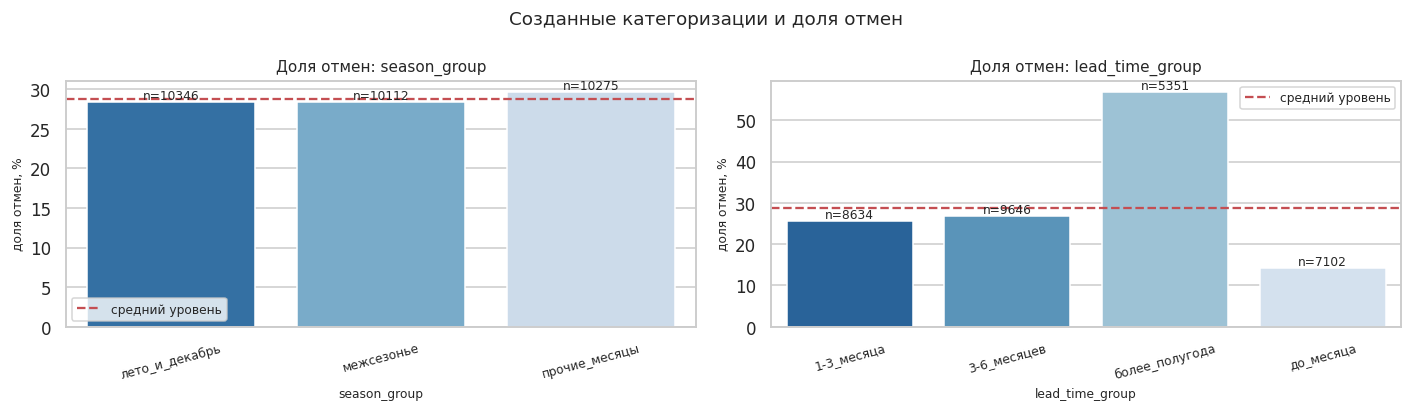

,броней,доля_отмен_%
customer_loyalty,,
"(0.0, 0.4]",2716,46.6500
"(0.4, 0.5]",15609,29.0500
"(0.5, 0.6]",1446,31.7400
"(0.6, 1.0]",10962,23.6200


In [17]:
features_base = fp.build_features(data, with_demand=False)
features_demand = fp.build_features(data, with_demand=True)
target = data[fp.TARGET].values

CREATED_FROM_BOOKING = [
    "total_nights", "weekend_share", "guests_total", "price_per_night", "customer_loyalty",
    "checkin_month", "checkin_dayofweek", "booking_month", "booking_year",
    "season_group", "lead_time_group",
]
CREATED_FROM_REVIEWS = ["stay_rating", "review_lag_days"]
KEPT_AS_IS = [
    "days_until_checkin", "child_count", "previous_cancellations", "previous_no_shows",
    "customer_special_requests", "returning_customer", "parking_included",
    "sales_channel", "meal_plan", "room_type",
]
groups = [
    ["создано по данным о брони", CREATED_FROM_BOOKING],
    ["создано по отзывам", CREATED_FROM_REVIEWS],
    ["взято из исходной таблицы без изменений", KEPT_AS_IS],
    ["текстовое поле", [fp.TEXT_COL]],
    ["признаки спроса (проверяются гипотезой)", list(fp.DEMAND_COLS)],
]
feature_overview = pd.DataFrame(
    [[name, len(columns), ", ".join(columns)] for name, columns in groups],
    columns=["группа", "столбцов", "состав"],
).set_index("группа")
feature_overview.loc["итого базовый набор"] = [
    features_base.shape[1], "без признаков спроса"
]
feature_overview.loc["итого с признаками спроса"] = [
    features_demand.shape[1], "оба набора разбиваются на выборки одинаково"
]
display(feature_overview)

display(features_base.head())
display(features_base[["total_nights", "weekend_share", "guests_total", "price_per_night",
                       "customer_loyalty", "review_lag_days"]].describe().T.round(3))
display(features_demand[fp.DEMAND_COLS].describe().T.round(2))

new_cat_rates = []
for column in ["season_group", "lead_time_group"]:
    grouped = pd.Series(target, index=features_base.index).groupby(features_base[column]).agg(["size", "mean"])
    grouped.columns = ["броней", "доля_отмен"]
    grouped["доля_отмен_%"] = (grouped["доля_отмен"] * 100).round(2)
    grouped = grouped.drop(columns="доля_отмен").reset_index().rename(columns={column: "значение"})
    grouped.insert(0, "признак", column)
    new_cat_rates.append(grouped)
display(pd.concat(new_cat_rates, ignore_index=True).set_index(["признак", "значение"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, column in zip(axes, ["season_group", "lead_time_group"]):
    grouped = pd.Series(target, index=features_base.index).groupby(features_base[column]).agg(["size", "mean"])
    rates = grouped["mean"] * 100
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, palette="Blues_r")
    ax.axhline(target.mean() * 100, color="#C44E52", linestyle="--", label="средний уровень")
    for position, (value, size) in enumerate(zip(rates.values, grouped["size"].values)):
        ax.text(position, value, f"n={size}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Доля отмен: {column}", fontsize=10)
    ax.set_xlabel(column, fontsize=8)
    ax.set_ylabel("доля отмен, %", fontsize=8)
    ax.tick_params(labelsize=8, axis="x", rotation=15)
    ax.legend(fontsize=8)
fig.suptitle("Созданные категоризации и доля отмен", fontsize=12)
fig.tight_layout()
plt.show()

loyalty_rates = (
    pd.Series(target, index=features_base.index)
    .groupby(pd.cut(features_base["customer_loyalty"], bins=[0, 0.4, 0.5, 0.6, 1.0]))
    .agg(["size", "mean"])
)
loyalty_rates.columns = ["броней", "доля_отмен"]
loyalty_rates["доля_отмен_%"] = (loyalty_rates["доля_отмен"] * 100).round(2)
loyalty_rates.index.name = "customer_loyalty"
display(loyalty_rates.drop(columns="доля_отмен"))

Смотрим, что именно попадает в текстовые признаки: словарь TF-IDF, обученный на всей таблице отзывов, и частоты слов. Это же показывает, насколько разнообразны тексты, доставшиеся броням после объединения по дате.

In [18]:
vectorizer = fp.make_preprocessor().transformers[2][1]
vectorizer.fit(reviews["review_text"])
vocabulary = vectorizer.get_feature_names()

word_counts = (
    pd.Series(
        np.asarray((vectorizer.transform(reviews["review_text"]) > 0).sum(axis=0)).ravel(),
        index=vocabulary,
        name="отзывов_со_словом",
    )
    .sort_values(ascending=False)
    .to_frame()
)
word_counts["доля_отзывов_%"] = (word_counts["отзывов_со_словом"] / len(reviews) * 100).round(1)
word_counts.columns.name = f"словарь TF-IDF: {len(vocabulary)} слов"
display(word_counts.head(20).T)
display(pd.Series(vocabulary, name="полный словарь TF-IDF").to_frame().T)

texts_in_features = data["review_text"].nunique()
display(pd.Series({
    "уникальных текстов в таблице отзывов": reviews["review_text"].nunique(),
    "уникальных текстов после объединения": texts_in_features,
    "доля уникальных текстов, попавших в признаки, %":
        round(texts_in_features / reviews["review_text"].nunique() * 100, 1),
    "доля от всех отзывов таблицы, %": round(texts_in_features / len(reviews) * 100, 1),
}, name="охват текстов").to_frame())

,неплохо,отель,отличный,кондиционер,для,номере,детей,нет,зоны,ничего,было,скучно,номерах,игровой,восторге,дети,холодно,пришлось,одеяла,выпрашивать
словарь TF-IDF: 60 слов,,,,,,,,,,,,,,,,,,,,
отзывов_со_словом,"14,336.0000","10,815.0000","10,431.0000","6,946.0000","5,058.0000","5,035.0000","4,739.0000","4,725.0000","4,466.0000","4,313.0000","4,308.0000","4,308.0000","4,111.0000","4,045.0000","4,045.0000","4,045.0000","3,921.0000","3,696.0000","3,696.0000","3,696.0000"
доля_отзывов_%,56.9000,43.0000,41.4000,27.6000,20.1000,20.0000,18.8000,18.8000,17.7000,17.1000,17.1000,17.1000,16.3000,16.1000,16.1000,16.1000,15.6000,14.7000,14.7000,14.7000


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
полный словарь TF-IDF,атмосфера,бельё,было,ванной,вернусь,восторге,второго,выпрашивать,далеко,детей,дети,для,есть,жары,завтрак,здесь,зимой,зоны,игровой,интернет,каждый,кондиционер,который,летом,мебель,неплохо,нет,ничего,номера,номерах,номере,обслуживание,одеяла,освещение,отапливается,отель,отеля,отличный,отсутствие,парковка,персонал,постельное,пришлось,продукты,работает,расположение,ресепшн,ресторане,сервис,система,скучно,спасал,справлялся,трансфер,тяжело,удобная,удобные,холодно,хорошо,это


,охват текстов
уникальных текстов в таблице отзывов,"14,153.0000"
уникальных текстов после объединения,"2,033.0000"
"доля уникальных текстов, попавших в признаки, %",14.4000
"доля от всех отзывов таблицы, %",8.1000


**Выводы по созданным признакам**

- Состав набора: **11 признаков создано по данным о брони** (включая две категоризации), 2 - по отзывам, 10 столбцов взяты из исходной таблицы без изменений, 1 текстовый. Итого **24 столбца в рабочем наборе** и 26 с признаками спроса, которые проверяются отдельной гипотезой. После препроцессора рабочий набор даёт **99 признаков**: 18 числовых, 21 колонка one-hot и 60 колонок TF-IDF.
- Оба признака, названные в ТЗ, созданы буквально. **Лояльность клиента работает**: в нижней группе (`customer_loyalty` до 0.4) отменяется **46.65%** броней, в верхней (свыше 0.6) - **23.62%**, при среднем уровне 28.80%. Корреляция с отменой -0.1205 - четвёртая по силе среди числовых признаков.
- **Сезонность не работает, и это объяснимо**: 28.36% отмен в группе «лето и декабрь», 28.39% в межсезонье и 29.64% в прочие месяцы. EDA уже показал, что заезды распределены по месяцам равномерно, то есть сезонного спроса в выгрузке нет. Поэтому группы названы нейтрально, по календарю, а не «высокий/низкий сезон»: имя признака не должно сообщать заказчику свойство, которого в данных нет. Сам признак оставлен для взаимодействий с другими.
- Самый сильный из созданных - **категоризация срока до заезда**: брони, оформленные более чем за полгода, отменяются в **56.79%** случаев, а оформленные меньше чем за месяц - в **14.28%**. Разрыв 42.5 процентных пункта больше, чем у любого исходного категориального признака.
- Признак спроса `same_checkin_prior_bookings` показал корреляцию с отменой **-0.1889** - вторую по силе среди числовых. Это делает гипотезу о его полезности осмысленной, и она проверяется отдельным экспериментом на этапе моделирования.
- `price_per_night` почти константа (первый квартиль, медиана и третий квартиль совпадают на 6 700 руб.) - следствие фиксированного тарифа в данных.
- Из набора убраны исходные составляющие производных признаков: `weekday_nights` и `weekend_nights` (заменены парой `total_nights` + `weekend_share`), `adult_count` (заменён на `guests_total`), `booking_value` (заменён на `price_per_night`). Точных линейных зависимостей в наборе не осталось.
- Текстовые признаки: словарь TF-IDF из 60 слов показан целиком. Его частотный состав - шаблонные слова разметки отзывов: «неплохо» встречается в 56.9% отзывов, «отель» в 43.0%, «отличный» в 41.4%. То есть словарь описывает форму отзыва, а не конкретную жалобу.

**Итог:** ключевую информацию несут срок до заезда и его категоризация, канал продаж, история отмен и лояльность клиента; сезонность и текстовые признаки в этих данных слабы, и это установленный факт, а не догадка.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

Проверяем итоговую таблицу перед моделированием: состав столбцов, пропуски, типы и связь числовых признаков с целевой переменной.

"итоговая таблица: 30733 строк, 26 столбцов",тип,пропусков,доля_пропусков_%,уникальных
days_until_checkin,int64,0,0.0000,79
total_nights,int64,0,0.0000,16
weekend_share,float64,0,0.0000,9
guests_total,int64,0,0.0000,5
child_count,int64,0,0.0000,3
price_per_night,float64,1229,4.0000,1735
previous_cancellations,int64,0,0.0000,6
previous_no_shows,int64,0,0.0000,6
customer_loyalty,float64,0,0.0000,18
customer_special_requests,int64,0,0.0000,6


,корреляция_с_отменой
days_until_checkin,0.2860
same_checkin_prior_bookings,-0.1889
previous_cancellations,0.1394
customer_loyalty,-0.1205
weekend_share,-0.1047
total_nights,-0.0767
child_count,-0.0465
bookings_prev_30d,0.0371
booking_year,-0.0310
previous_no_shows,-0.0310


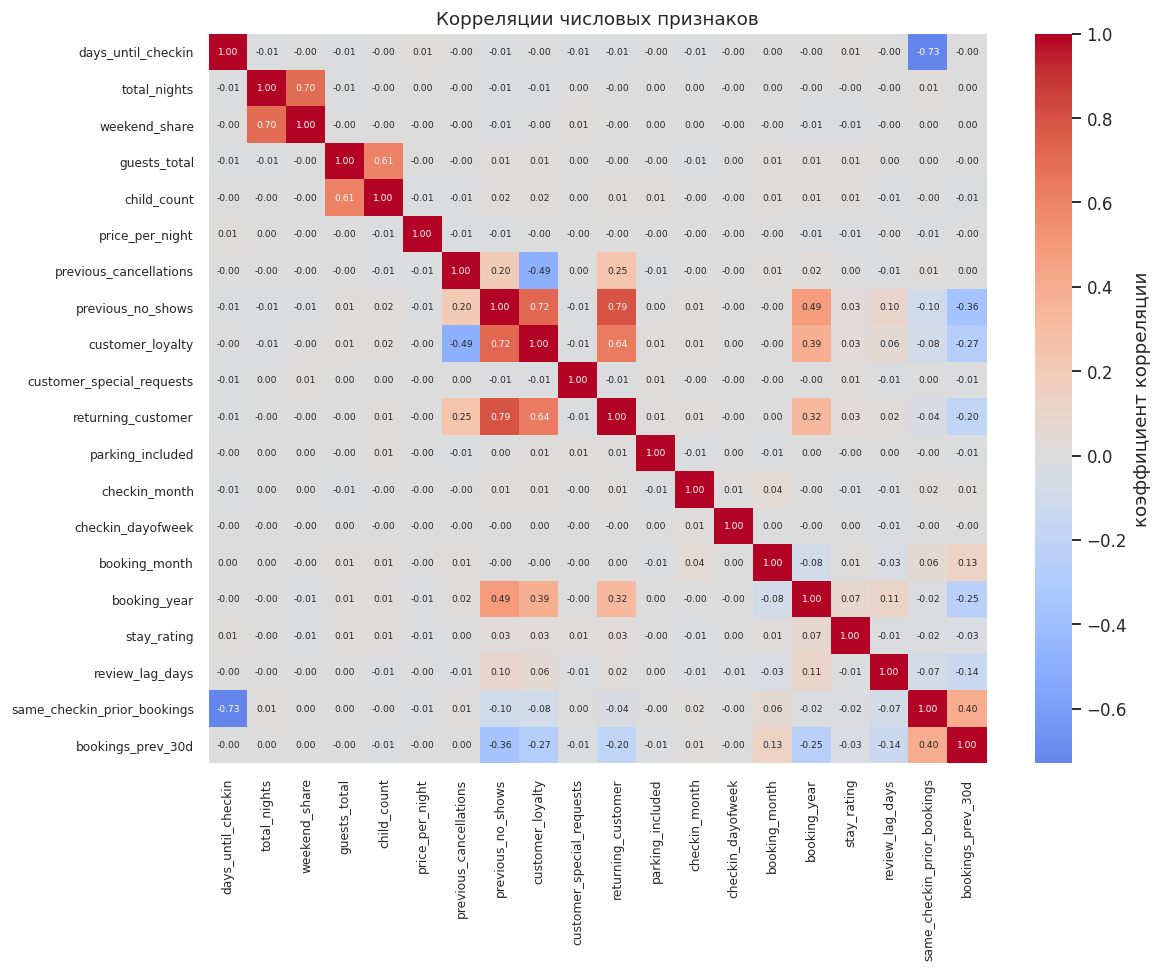

,корреляция


In [19]:
final_report = pd.DataFrame({
    "тип": features_demand.dtypes.astype(str),
    "пропусков": features_demand.isna().sum(),
    "доля_пропусков_%": (features_demand.isna().mean() * 100).round(2),
    "уникальных": features_demand.nunique(),
})
final_report.columns.name = (
    f"итоговая таблица: {features_demand.shape[0]} строк, {features_demand.shape[1]} столбцов"
)
display(final_report)

numeric_all = fp.numeric_cols(with_demand=True)
corr_final = (
    features_demand[numeric_all]
    .assign(is_cancelled=target)
    .corr()["is_cancelled"]
    .drop("is_cancelled")
    .sort_values(key=abs, ascending=False)
    .round(4)
    .to_frame("корреляция_с_отменой")
)
display(corr_final)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(features_demand[numeric_all].corr().round(2), cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 6}, ax=ax,
            cbar_kws={"label": "коэффициент корреляции"})
ax.set_title("Корреляции числовых признаков")
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

# Пары признаков с корреляцией выше 0.8 могли бы дублировать друг друга - проверяем явно.
corr_matrix = features_demand[numeric_all].corr().abs()
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
strong_pairs = pairs[pairs > 0.8].sort_values(ascending=False).round(3).to_frame("корреляция")
strong_pairs.index.names = ["признак_1", "признак_2"]
display(strong_pairs if len(strong_pairs) else pd.DataFrame({"корреляция": []}))

**Выводы по итоговой таблице**

- Итоговая таблица - **30 733 строки и 26 столбцов** (20 числовых вместе с признаками спроса, 5 категориальных, 1 текстовый). В рабочий набор уйдут 24 столбца: два признака спроса включаются только если их подтвердит гипотеза на этапе моделирования.
- Пропуски остались только там, где они осмысленны: `price_per_night` - 4.00% (нулевая стоимость, переведённая в пропуск), `stay_rating` и `review_lag_days` - по 0.63% (брони без предшествующего отзыва). Все они заполняются медианой обучающей части внутри препроцессора, то есть без утечки.
- Связь с целевой переменной возглавляет **`days_until_checkin` (0.286)**, далее `same_checkin_prior_bookings` (-0.1889), `previous_cancellations` (0.1394), `customer_loyalty` (-0.1205), `weekend_share` (-0.1047) и `total_nights` (-0.0767). Остальные числовые признаки коррелируют с отменой слабее 0.05.
- **Пар признаков с корреляцией выше 0.8 нет** - производные признаки не продублировали исходные, мультиколлинеарности в наборе не осталось.

**Итог:** таблица готова к моделированию. Линейной связи с целевой переменной мало (максимум 0.29), поэтому ставка делается на ансамбли деревьев, которые улавливают нелинейности и взаимодействия.

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

#### Разделение выборок и схема кросс-валидации

Данные делятся на train / calibration / test в пропорции 60 / 20 / 20 со стратификацией по целевой переменной. Разбиение считается один раз по позициям строк и применяется к обоим вариантам признакового набора (с признаками спроса и без), чтобы гипотезы сравнивались на одних и тех же строках.

Внутри обучающей выборки работает `StratifiedShuffleSplit` с тремя фолдами и валидационной частью в 2 000 объектов - размер задан требованиями задания.

Доля отмен показана для всех трёх выборок: это контроль качества стратификации, а не подглядывание в тест. Отложенной тестовая выборка остаётся не по статистике класса, а по решениям: ни модель, ни признаки, ни порог по ней не выбираются, первое обращение к её предсказаниям - в разделе «Анализ матрицы классификаций».

In [20]:
positions = np.arange(len(features_base))
idx_train, idx_temp = train_test_split(
    positions, test_size=0.4, random_state=RANDOM_STATE, stratify=target
)
idx_cal, idx_test = train_test_split(
    idx_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=target[idx_temp]
)

y_train, y_cal, y_test = target[idx_train], target[idx_cal], target[idx_test]
X_train_base, X_cal_base, X_test_base = (
    features_base.iloc[idx_train], features_base.iloc[idx_cal], features_base.iloc[idx_test]
)
X_train_demand, X_cal_demand, X_test_demand = (
    features_demand.iloc[idx_train], features_demand.iloc[idx_cal], features_demand.iloc[idx_test]
)

split_report = pd.DataFrame(
    [
        ["train", len(idx_train), round(len(idx_train) / len(positions) * 100, 1), round(y_train.mean() * 100, 2)],
        ["calibration", len(idx_cal), round(len(idx_cal) / len(positions) * 100, 1), round(y_cal.mean() * 100, 2)],
        ["test", len(idx_test), round(len(idx_test) / len(positions) * 100, 1), round(y_test.mean() * 100, 2)],
    ],
    columns=["выборка", "строк", "доля_%", "доля_отмен_%"],
).set_index("выборка")
split_report.columns.name = "стратификация по целевой переменной"
display(split_report)

# Выборки не пересекаются - проверяем явно, а не глазами.
assert len(set(idx_train) & set(idx_cal)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_cal) & set(idx_test)) == 0

cv = StratifiedShuffleSplit(n_splits=3, test_size=2000, random_state=RANDOM_STATE)
fold_sizes = pd.DataFrame(
    [[i + 1, len(tr), len(va), round(y_train[va].mean() * 100, 2)]
     for i, (tr, va) in enumerate(cv.split(X_train_base, y_train))],
    columns=["фолд", "обучение", "валидация", "доля_отмен_валидации_%"],
).set_index("фолд")
display(fold_sizes)

стратификация по целевой переменной,строк,доля_%,доля_отмен_%
выборка,,,
train,18439,60.0000,28.8000
calibration,6147,20.0000,28.7900
test,6147,20.0000,28.7900


,обучение,валидация,доля_отмен_валидации_%
фолд,,,
1,16439,2000,28.8000
2,16439,2000,28.8000
3,16439,2000,28.8000


#### Базовые сценарии

Прежде чем сравнивать модели, фиксируем две константные стратегии - они задают планку, ниже которой модель бессмысленна. «Никогда не предсказывать отмену» - это ровно текущее положение дел, то есть $IR_{до}$.

In [21]:
baselines = []
for name, prediction in [
    ("все брони считаем состоявшимися", np.zeros_like(y_cal)),
    ("все брони считаем отменами", np.ones_like(y_cal)),
]:
    metrics = fp.business_metrics(y_cal, prediction)
    baselines.append([name, metrics["IR_after"], metrics["IR"], metrics["IR_rel_%"]])
baselines = pd.DataFrame(baselines, columns=["сценарий", "IR_после", "IR", "IR_отн_%"]).set_index("сценарий")
baselines.columns.name = "калибровочная выборка"
display(baselines.round(2))

break_even = fp.break_even_threshold()
display(pd.DataFrame(
    [
        ["выигрыш от верного прогноза отмены, руб.", fp.PER_REBOOKING + fp.LOST_REV],
        ["потеря от ложной тревоги, руб.", fp.AVG_REV + fp.COST_FP],
        ["порог безубыточности", round(break_even, 4)],
    ],
    columns=["показатель", "значение"],
).set_index("показатель"))

калибровочная выборка,IR_после,IR,IR_отн_%
сценарий,,,
все брони считаем состоявшимися,168151500,0,0.0000
все брони считаем отменами,49011000,-119140500,-70.8500


,значение
показатель,
"выигрыш от верного прогноза отмены, руб.","109,500.0000"
"потеря от ложной тревоги, руб.","71,500.0000"
порог безубыточности,0.3950


#### Турнир моделей

Сравниваем три библиотеки: Random Forest как ансамбль без бустинга и два градиентных бустинга - LightGBM и CatBoost. Все модели получают одинаковые строки и одинаковый формат признаков (one-hot плюс TF-IDF), число потоков зафиксировано, чтобы сравнивать алгоритмы, а не настройки многопоточности.

**Препроцессор входит в `Pipeline` вместе с моделью**, поэтому импьютер, one-hot и словарь TF-IDF обучаются внутри каждого фолда только на его обучающей части: валидационные 2 000 строк не участвуют ни в одной статистике.

Optuna подбирает по 4-6 гиперпараметров на модель. Целевая функция - средний по трём фолдам IR, максимизированный по сетке порогов внутри фолда: разные семейства моделей дают вероятности разного масштаба, и оценка в одной фиксированной точке сравнивала бы их калибровку, а не качество ранжирования. Такая оценка оптимистична (порог подобран на тех же строках), поэтому итоговые честные значения берутся позже с калибровочной и тестовой выборок.

Масштабирование признаков не применяется: все три модели - деревья, они инвариантны к монотонным преобразованиям, и стандартизация ничего бы не изменила.

In [22]:
THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.01), 2)


def make_model(name, params):
    """Создаёт модель нужного семейства с заданными гиперпараметрами."""
    if name == "RandomForest":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS,
                                      class_weight="balanced", **params)
    if name == "LightGBM":
        return lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, **params)
    return CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=N_JOBS,
                              verbose=0, **params)


def make_estimator(name, params, with_demand=False):
    """Препроцессор и модель в одном Pipeline: fit препроцессора идёт по обучающей части фолда."""
    return Pipeline([
        ("preprocessor", fp.make_preprocessor(with_demand=with_demand)),
        ("model", make_model(name, params)),
    ])


def cross_validate_ir(name, params, X, y, with_demand=False):
    """Средние по фолдам IR, разброс IR и ROC-AUC для одной конфигурации."""
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X, y):
        estimator = make_estimator(name, params, with_demand)
        estimator.fit(X.iloc[train_idx], y[train_idx])
        proba = estimator.predict_proba(X.iloc[valid_idx])[:, 1]
        scan = fp.threshold_scan(y[valid_idx], proba, THRESHOLD_GRID)
        fold_ir.append(scan["IR"].max())
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.std(fold_ir)), float(np.mean(fold_auc))


SEARCH_SPACES = {
    "RandomForest": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        max_depth=trial.suggest_int("max_depth", 6, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 40),
        max_features=trial.suggest_float("max_features", 0.2, 0.9),
    ),
    "LightGBM": lambda trial: dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 900, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.003, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    ),
    "CatBoost": lambda trial: dict(
        iterations=trial.suggest_int("iterations", 200, 800, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 9),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
    ),
}

N_TRIALS = 20
tournament_rows, best_configs, studies = [], {}, {}
for model_name, space in SEARCH_SPACES.items():
    def objective(trial, model_name=model_name, space=space):
        params = space(trial)
        mean_ir, std_ir, mean_auc = cross_validate_ir(
            model_name, params, X_train_base, y_train, with_demand=False
        )
        trial.set_user_attr("roc_auc", mean_auc)
        trial.set_user_attr("ir_std", std_ir)
        return mean_ir

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=model_name,
    )
    started = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    tournament_rows.append({
        "модель": model_name,
        "IR_cv": round(study.best_value, 1),
        "разброс_IR_по_фолдам": round(study.best_trial.user_attrs["ir_std"], 1),
        "ROC_AUC_cv": round(study.best_trial.user_attrs["roc_auc"], 4),
        "время_с": round(time.time() - started, 1),
        "испытаний": N_TRIALS,
    })
    best_configs[model_name] = study.best_params
    studies[model_name] = study

tournament = pd.DataFrame(tournament_rows).sort_values("IR_cv", ascending=False).set_index("модель")
tournament.columns.name = f"кросс-валидация: 3 фолда по 2 000 объектов, {N_TRIALS} испытаний Optuna"
display(tournament)

# Лучшие гиперпараметры показываем отдельной таблицей: в общей они не помещаются в колонку.
display(pd.DataFrame(best_configs).T.rename_axis("модель"))

best_model_name = tournament.index[0]
best_params = best_configs[best_model_name]

# Проверяем, что победитель не оказался на краю сетки поиска.
grid_edges = pd.DataFrame(
    [[name, value, str(studies[best_model_name].best_trial.distributions[name])]
     for name, value in best_params.items()],
    columns=["гиперпараметр", "значение", "диапазон поиска"],
).set_index("гиперпараметр")
grid_edges.columns.name = f"победитель: {best_model_name}"
display(grid_edges)

"кросс-валидация: 3 фолда по 2 000 объектов, 20 испытаний Optuna",IR_cv,разброс_IR_по_фолдам,ROC_AUC_cv,время_с,испытаний
модель,,,,,
CatBoost,"22,584,833.3000","791,155.1000",0.8079,243.5000,20
LightGBM,"21,569,333.3000","1,423,375.8000",0.8017,123.0000,20
RandomForest,"21,129,500.0000","1,405,122.8000",0.7995,433.7000,20


,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,num_leaves,min_child_samples,colsample_bytree,reg_lambda,iterations,depth,l2_leaf_reg
модель,,,,,,,,,,,,
RandomForest,500.0000,6.0000,26.0000,0.6569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,900.0000,NaN,NaN,NaN,0.0156,18.0000,80.0000,0.9953,0.9763,NaN,NaN,NaN
CatBoost,NaN,NaN,NaN,NaN,0.0735,NaN,NaN,NaN,NaN,300.0000,4.0000,7.5485


победитель: CatBoost,значение,диапазон поиска
гиперпараметр,,
iterations,300.0000,"IntDistribution(high=800, log=False, low=200, ..."
learning_rate,0.0735,"FloatDistribution(high=0.2, log=True, low=0.00..."
depth,4.0000,"IntDistribution(high=9, log=False, low=4, step=1)"
l2_leaf_reg,7.5485,"FloatDistribution(high=10.0, log=False, low=1...."


**Выводы по турниру моделей**

| Модель | IR на кросс-валидации | Разброс по фолдам | ROC-AUC | Время подбора |
|---|---|---|---|---|
| **CatBoost** | **22 584 833 руб.** | 791 155 | **0.8079** | 244 с |
| LightGBM | 21 569 333 руб. | 1 423 376 | 0.8017 | 123 с |
| Random Forest | 21 129 500 руб. | 1 405 123 | 0.7995 | 434 с |

- **Победитель - CatBoost** с параметрами `iterations = 300`, `learning_rate = 0.0735`, `depth = 4`, `l2_leaf_reg = 7.5485`. Все четыре значения лежат внутри сетки поиска, на её краю победитель не оказался - таблица диапазонов приведена рядом.
- Разрыв между библиотеками небольшой: **4.7% по IR** между CatBoost и LightGBM и 6.9% между первым и последним местом, по ROC-AUC - 0.008. Все три семейства упираются в один потолок сигнала в данных, а не в устройство алгоритма.
- **Победитель выбран не по одному среднему.** Отрыв CatBoost от LightGBM (1.02 млн руб.) сопоставим с разбросом IR по фолдам (0.79 млн у CatBoost и 1.42 млн у LightGBM), поэтому одного среднего было бы мало. CatBoost выигрывает по совокупности: лучший IR, лучший ROC-AUC и **вдвое меньший разброс между фолдами**, то есть более устойчивая оценка.
- По стоимости подбора: Random Forest потребовал 433.7 с против 243.5 с у CatBoost и 123.0 с у LightGBM, то есть оказался и самым дорогим, и самым слабым. CatBoost медленнее LightGBM ровно вдвое - это плата за 4.7% IR, и её стоит помнить, если модель придётся часто переобучать.
- Обе базовые стратегии проигрывают модели: «все брони считаются состоявшимися» - это ровно текущее положение дел (IR = 0 по определению), «все брони считаются отменами» даёт **-70.85%** к доходу. Порог безубыточности, следующий из матрицы стоимостей, равен **0.395**: отмену выгодно прогнозировать, если её вероятность выше 39.5%.

**Итог:** для дальнейшей работы зафиксирован CatBoost - лучший IR при самой устойчивой оценке по фолдам.

#### Проверка гипотез по улучшению IR

Предварительная оценка показывает, что базовая конфигурация не выходит на целевой уровень относительного IR в 50%, а задание прямо предписывает в этом случае экспериментировать: пересматривать признаки, модель и предобработку. Проверяем четыре гипотезы, все - на той же кросс-валидации и на тех же строках, чтобы результаты были сопоставимы:

1. **Признаки спроса.** Добавляем `same_checkin_prior_bookings` и `bookings_prev_30d` - единственное семейство сигналов в данных, которое ещё не использовано. Обе величины считаются только по ранее оформленным броням.
2. **Нативные категории и тексты CatBoost.** Вместо one-hot и TF-IDF отдаём CatBoost категориальные и текстовый столбцы напрямую: упорядоченные целевые статистики - его штатный режим, и сейчас он выключен. Оговорка: `CalibratedClassifierCV` в sklearn 0.24 валидирует вход как числовой массив, поэтому нативный режим потребовал бы отдельной схемы калибровки - гипотеза проверяется как диагностика.
3. **Блендинг.** Усредняем вероятности настроенных CatBoost и LightGBM: типичный способ добрать несколько тысячных ROC-AUC.
4. **Расширенный поиск.** Ещё 25 испытаний Optuna для победителя на лучшем наборе признаков - проверяем, не упёрлись ли мы в бюджет поиска, а не в данные.

Конфигурацию берём в продакшн, если она даёт прирост IR на кросс-валидации больше 1% и не ломает схему калибровки.

**Оговорка о базе сравнения.** Строка «база» - это лучшее из 20 испытаний Optuna, отобранное на тех же трёх фолдах, а гипотезы 1-3 получают по одному прогону на её гиперпараметрах. Сравнение поэтому несимметрично и способно уверенно отловить только заметные эффекты. Честное сравнение «максимум против максимума» даёт гипотеза 4: та же модель, та же сетка, отличается только стартовое зерно сэмплера - и она показывает, на что вообще способен этот эксперимент.

In [23]:
# Единое правило принятия гипотезы: используется и в таблице, и в выборе конфигурации.
MIN_GAIN_PCT = 1.0

experiment_rows = []
base_ir, base_std, base_auc = cross_validate_ir(
    best_model_name, best_params, X_train_base, y_train, with_demand=False
)
experiment_rows.append(["0. база: победитель турнира", base_ir, base_auc, 0.0])

# Гипотеза 1: признаки спроса.
demand_ir, demand_std, demand_auc = cross_validate_ir(
    best_model_name, best_params, X_train_demand, y_train, with_demand=True
)
experiment_rows.append(["1. + признаки спроса", demand_ir, demand_auc,
                        (demand_ir - base_ir) / abs(base_ir) * 100])


# Гипотеза 2: нативные категории и текст CatBoost.
def cross_validate_catboost_native(params, X, y):
    """CatBoost на сырых столбцах: категории и текст обрабатываются внутри модели."""
    columns = fp.numeric_cols(False) + fp.CATEGORICAL_COLS + [fp.TEXT_COL]
    cat_idx = [columns.index(c) for c in fp.CATEGORICAL_COLS]
    text_idx = [columns.index(fp.TEXT_COL)]
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X, y):
        frame = X[columns].copy()
        frame[fp.numeric_cols(False)] = frame[fp.numeric_cols(False)].fillna(
            frame[fp.numeric_cols(False)].iloc[train_idx].median()
        )
        train_pool = Pool(frame.iloc[train_idx], y[train_idx],
                          cat_features=cat_idx, text_features=text_idx)
        valid_pool = Pool(frame.iloc[valid_idx], y[valid_idx],
                          cat_features=cat_idx, text_features=text_idx)
        model = CatBoostClassifier(random_seed=RANDOM_STATE, thread_count=N_JOBS,
                                   verbose=0, **params)
        model.fit(train_pool)
        proba = model.predict_proba(valid_pool)[:, 1]
        fold_ir.append(fp.threshold_scan(y[valid_idx], proba, THRESHOLD_GRID)["IR"].max())
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.mean(fold_auc))


catboost_params = best_configs.get("CatBoost", best_params)
native_ir, native_auc = cross_validate_catboost_native(catboost_params, X_train_base, y_train)
experiment_rows.append(["2. CatBoost: нативные категории и текст", native_ir, native_auc,
                        (native_ir - base_ir) / abs(base_ir) * 100])


# Гипотеза 3: блендинг CatBoost и LightGBM.
def cross_validate_blend(X, y):
    """Среднее вероятностей двух настроенных моделей."""
    fold_ir, fold_auc = [], []
    for train_idx, valid_idx in cv.split(X, y):
        probas = []
        for name in ("CatBoost", "LightGBM"):
            estimator = make_estimator(name, best_configs[name], with_demand=False)
            estimator.fit(X.iloc[train_idx], y[train_idx])
            probas.append(estimator.predict_proba(X.iloc[valid_idx])[:, 1])
        proba = np.mean(probas, axis=0)
        fold_ir.append(fp.threshold_scan(y[valid_idx], proba, THRESHOLD_GRID)["IR"].max())
        fold_auc.append(roc_auc_score(y[valid_idx], proba))
    return float(np.mean(fold_ir)), float(np.mean(fold_auc))


blend_ir, blend_auc = cross_validate_blend(X_train_base, y_train)
experiment_rows.append(["3. блендинг CatBoost + LightGBM", blend_ir, blend_auc,
                        (blend_ir - base_ir) / abs(base_ir) * 100])

# Гипотеза 4: расширенный поиск на лучшем наборе признаков.
USE_DEMAND = (demand_ir - base_ir) / abs(base_ir) * 100 > MIN_GAIN_PCT
X_train_best = X_train_demand if USE_DEMAND else X_train_base

def extended_objective(trial):
    params = SEARCH_SPACES[best_model_name](trial)
    mean_ir, std_ir, mean_auc = cross_validate_ir(
        best_model_name, params, X_train_best, y_train, with_demand=USE_DEMAND
    )
    trial.set_user_attr("roc_auc", mean_auc)
    return mean_ir


extended_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
    study_name=f"{best_model_name}_extended",
)
extended_study.optimize(extended_objective, n_trials=25, show_progress_bar=False)
experiment_rows.append([f"4. ещё 25 испытаний Optuna ({best_model_name})",
                        extended_study.best_value,
                        extended_study.best_trial.user_attrs["roc_auc"],
                        (extended_study.best_value - base_ir) / abs(base_ir) * 100])

experiments = pd.DataFrame(
    experiment_rows, columns=["гипотеза", "IR_cv", "ROC_AUC_cv", "прирост_IR_%"]
).set_index("гипотеза")
experiments["принята"] = experiments["прирост_IR_%"] > MIN_GAIN_PCT
experiments.columns.name = "кросс-валидация на обучающей выборке, 3 фолда по 2 000"
display(experiments.round(4))

# Финальная конфигурация: лучший набор признаков и лучшие гиперпараметры из двух поисков.
extended_gain = (extended_study.best_value - max(base_ir, demand_ir)) / abs(base_ir) * 100
extended_accepted = extended_gain > MIN_GAIN_PCT
if extended_accepted:
    best_params = extended_study.best_params
# IR принятой конфигурации, а не максимум по всем проверенным: иначе метаданные
# описывали бы вариант, который в продакшн не пошёл.
if extended_accepted:
    FINAL_IR_CV = extended_study.best_value
elif USE_DEMAND:
    FINAL_IR_CV = demand_ir
else:
    FINAL_IR_CV = base_ir
X_train_final = X_train_demand if USE_DEMAND else X_train_base
X_cal_final = X_cal_demand if USE_DEMAND else X_cal_base
X_test_final = X_test_demand if USE_DEMAND else X_test_base

display(pd.Series({
    "модель": best_model_name,
    "признаки спроса включены": USE_DEMAND,
    "число признаков до препроцессора": X_train_final.shape[1],
    "IR на кросс-валидации": round(FINAL_IR_CV, 1),
    **{f"параметр: {k}": v for k, v in best_params.items()},
}, name="итоговая конфигурация").to_frame())

"кросс-валидация на обучающей выборке, 3 фолда по 2 000",IR_cv,ROC_AUC_cv,прирост_IR_%,принята
гипотеза,,,,
0. база: победитель турнира,"22,584,833.3333",0.8079,0.0000,False
1. + признаки спроса,"22,575,333.3333",0.8084,-0.0421,False
2. CatBoost: нативные категории и текст,"22,509,166.6667",0.8080,-0.3350,False
3. блендинг CatBoost + LightGBM,"22,427,833.3333",0.8060,-0.6952,False
4. ещё 25 испытаний Optuna (CatBoost),"22,533,666.6667",0.8066,-0.2266,False


,итоговая конфигурация
модель,CatBoost
признаки спроса включены,False
число признаков до препроцессора,24
IR на кросс-валидации,"22,584,833.3000"
параметр: iterations,300
параметр: learning_rate,0.0735
параметр: depth,4
параметр: l2_leaf_reg,7.5485


**Выводы по проверке гипотез**

| Гипотеза | IR на кросс-валидации | ROC-AUC | Прирост IR |
|---|---|---|---|
| 0. база: CatBoost из турнира | 22 584 833 | 0.8079 | - |
| 1. + признаки спроса | 22 575 333 | 0.8084 | **-0.04%** |
| 2. CatBoost: нативные категории и текст | 22 509 167 | 0.8080 | **-0.34%** |
| 3. блендинг CatBoost + LightGBM | 22 427 833 | 0.8060 | **-0.70%** |
| 4. ещё 25 испытаний Optuna | 22 533 667 | 0.8066 | **-0.23%** |

**Ни одна из четырёх гипотез не улучшила результат** - все дали от -0.04% до -0.70% к IR, то есть отличия лежат внутри разброса по фолдам (791 155 руб., или 3.5% от значения). Это отрицательный результат, и он информативнее положительного:

- **Признаки спроса не помогли, несмотря на корреляцию -0.1889.** ROC-AUC даже вырос (0.8084 против 0.8079), но на IR это не отразилось: информация о загрузке даты заезда уже содержится в сроке до заезда и канале продаж, с которыми модель работает напрямую.
- **Нативный режим CatBoost не дал преимущества** (-0.34%): упорядоченные целевые статистики выигрывают на категориях с высокой кардинальностью, а здесь максимум семь значений, где one-hot ничего не теряет. Отдельная схема калибровки под этот режим не понадобится.
- **Блендинг ухудшил результат** (-0.70%): усреднение с более слабой моделью (LightGBM отстаёт на 4.7%) сдвигает вероятности в её сторону.
- **Бюджет поиска не был узким местом**: ещё 25 испытаний Optuna с другим стартовым зерном не превзошли исходные 20 (-0.23%).

**Итог:** потолок в **ROC-AUC около 0.81** определяется данными, а не выбором модели, гиперпараметров или способа кодирования признаков. Это прямое основание для рекомендаций заказчику: улучшать нужно состав данных, а не алгоритм. В продакшн идёт базовая конфигурация - CatBoost на исходном наборе признаков.

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

Калибруем победителя на полной обучающей выборке: `CalibratedClassifierCV` с тремя фолдами внутри train обучает изотоническую регрессию поверх предсказаний, а на выходе усредняет три откалиброванные копии модели.

Схема выбрана так, чтобы калибровочная выборка осталась чистой: калибратор учится на train, а калибровочная выборка используется только для оценки качества калибровки и поиска порога. Если бы калибратор обучался и проверялся на одних и тех же данных, и Brier, и порог получились бы оптимистичными.

,размерность после препроцессора
выборка,
train,"(18439, 99)"
calibration,"(6147, 99)"
test,"(6147, 99)"


калибровочная выборка,Brier,ROC_AUC,PR_AUC,максимум_IR
модель,,,,
без калибровки,0.154173,0.803153,0.637214,"63,119,000"
после калибровки,0.153819,0.804028,0.637108,"63,625,000"


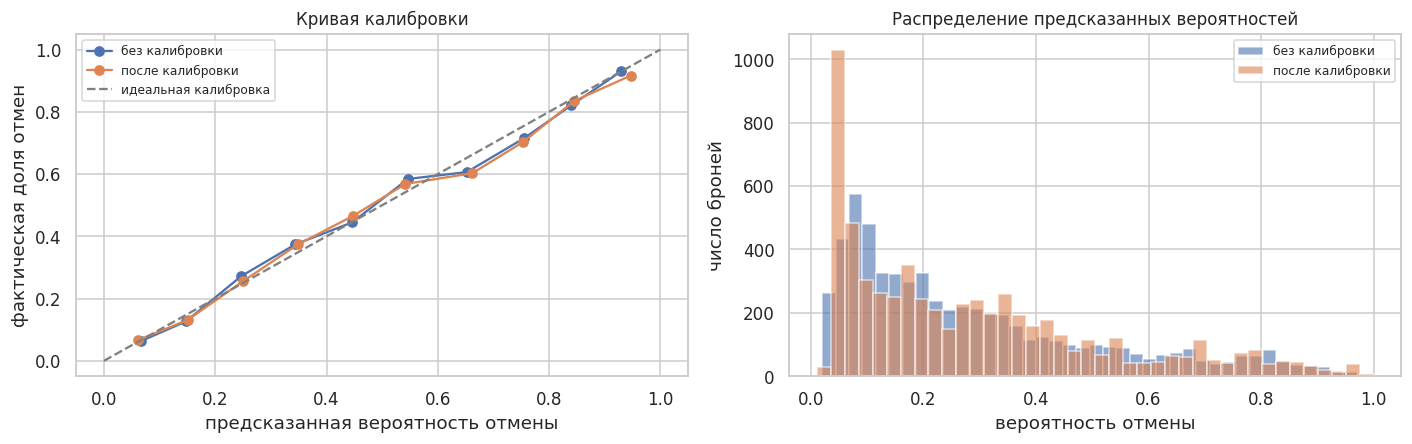

In [24]:
preprocessor = fp.make_preprocessor(with_demand=USE_DEMAND)
A_train = preprocessor.fit_transform(X_train_final, y_train)
A_cal = preprocessor.transform(X_cal_final)
A_test = preprocessor.transform(X_test_final)
feature_names = fp.get_feature_names(preprocessor, with_demand=USE_DEMAND)

display(pd.DataFrame(
    [["train", A_train.shape], ["calibration", A_cal.shape], ["test", A_test.shape]],
    columns=["выборка", "размерность после препроцессора"],
).set_index("выборка"))

base_model = make_model(best_model_name, best_params)
base_model.fit(A_train, y_train)

calibrated_model = CalibratedClassifierCV(
    base_estimator=make_model(best_model_name, best_params), cv=3, method="isotonic"
)
calibrated_model.fit(A_train, y_train)

proba_cal_base = base_model.predict_proba(A_cal)[:, 1]
proba_cal_calibrated = calibrated_model.predict_proba(A_cal)[:, 1]

calibration_quality = pd.DataFrame(
    [
        ["без калибровки",
         brier_score_loss(y_cal, proba_cal_base),
         roc_auc_score(y_cal, proba_cal_base),
         average_precision_score(y_cal, proba_cal_base),
         fp.threshold_scan(y_cal, proba_cal_base, THRESHOLD_GRID)["IR"].max()],
        ["после калибровки",
         brier_score_loss(y_cal, proba_cal_calibrated),
         roc_auc_score(y_cal, proba_cal_calibrated),
         average_precision_score(y_cal, proba_cal_calibrated),
         fp.threshold_scan(y_cal, proba_cal_calibrated, THRESHOLD_GRID)["IR"].max()],
    ],
    columns=["модель", "Brier", "ROC_AUC", "PR_AUC", "максимум_IR"],
).set_index("модель")
calibration_quality.columns.name = "калибровочная выборка"
# Глобальный float_format печатает четыре знака, а разница в Brier лежит в шестом,
# поэтому форматируем значения строками явно.
calibration_display = calibration_quality.copy()
for column in ["Brier", "ROC_AUC", "PR_AUC"]:
    calibration_display[column] = calibration_display[column].map("{:.6f}".format)
calibration_display["максимум_IR"] = calibration_display["максимум_IR"].map("{:,.0f}".format)
display(calibration_display)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for label, proba in [("без калибровки", proba_cal_base), ("после калибровки", proba_cal_calibrated)]:
    fraction, mean_predicted = calibration_curve(y_cal, proba, n_bins=10)
    axes[0].plot(mean_predicted, fraction, marker="o", label=label)
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="идеальная калибровка")
axes[0].set_title("Кривая калибровки", fontsize=11)
axes[0].set_xlabel("предсказанная вероятность отмены")
axes[0].set_ylabel("фактическая доля отмен")
axes[0].legend(fontsize=8)

axes[1].hist(proba_cal_base, bins=40, alpha=0.6, label="без калибровки")
axes[1].hist(proba_cal_calibrated, bins=40, alpha=0.6, label="после калибровки")
axes[1].set_title("Распределение предсказанных вероятностей", fontsize=11)
axes[1].set_xlabel("вероятность отмены")
axes[1].set_ylabel("число броней")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Выводы по калибровке**

| Модель | Brier | ROC-AUC | PR-AUC | Максимум IR |
|---|---|---|---|---|
| без калибровки | 0.154173 | 0.803153 | 0.637214 | 63 119 000 руб. |
| после калибровки | 0.153819 | 0.804028 | 0.637108 | 63 625 000 руб. |

- Изотоническая калибровка на трёх фолдах обучающей выборки улучшила три метрики из четырёх: **Brier на 0.23%** (0.153819 против 0.154173), ROC-AUC на 0.11% и максимум IR на **0.8%, то есть на 506 000 руб.** PR-AUC изменился на -0.02%, фактически остался тем же.
- Эффект небольшой, и это ожидаемо: CatBoost с логистической функцией потерь и так выдаёт близкие к честным вероятности - обе линии на кривой калибровки идут вдоль диагонали.
- Практическая польза калибровки не столько в приросте метрики, сколько в **интерпретируемости порога**: после неё значение 0.34 действительно означает «в среднем 34 такие брони из 100 будут отменены», и порог можно осмысленно сравнивать с порогом безубыточности 0.395.

**Итог:** калибровка улучшила и точность вероятностей, и максимум IR; дальше работаем с откалиброванной моделью.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

Порог ищем по калибровочной выборке: перебираем сетку и выбираем значение, дающее максимальный IR. Сетку строим по квантилям предсказанных вероятностей плюс равномерный шаг и добавляем в неё порог безубыточности - так все три ориентира попадают в одну таблицу.

Рядом с оптимумом по деньгам считаем порог, при котором выполняется обязательная цель заказчика по доле отмен. Это две разные точки, и выбор между ними - управленческое решение: в продакшн уходит порог, максимизирующий IR **при выполнении ограничения**, потому что доля отмен в 10% - это требование, а не пожелание.

**Порог берём с запасом.** IR растёт с порогом вплоть до безусловного оптимума, поэтому решение задачи «максимум IR при доле отмен не выше 10%» всегда ложится ровно на границу ограничения - а доля отмен оценена по выборке и имеет стандартную ошибку около 0.38 п.п. Порог, выбранный точно на границе, провалит цель на новых данных примерно в половине случаев. Поэтому ограничение ужесточается на две стандартные ошибки, и цена этого запаса показывается в таблице явно - это прямое следствие урока прошлых спринтов: при жёстком лимите порог нужно искать с запасом, а не в угловой точке.

,запас по доле отмен
"стандартная ошибка доли отмен, п.п.",0.3830
"ограничение ТЗ, %",10.0000
"ограничение с запасом в две ошибки, %",9.2300
порог на границе ограничения,0.3400
рабочий порог с запасом,0.3272


,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%
0,0.0410,1764,4294,6,83,54288500,-113863000,-67.7150,0.0980,30.0470
4,0.0540,1736,3728,34,649,91691500,-76460000,-45.4710,0.5530,38.7990
8,0.0610,1703,3314,67,1063,117679000,-50472500,-30.0160,1.0900,44.9980
12,0.0790,1680,2992,90,1385,138183500,-29968000,-17.8220,1.4640,49.8620
16,0.0980,1657,2768,113,1609,151681000,-16470500,-9.7950,1.8380,53.1320
20,0.1200,1639,2554,131,1823,165011000,-3140500,-1.8680,2.1310,56.3200
24,0.1400,1621,2373,149,2004,175981500,7830000,4.6570,2.4240,58.9720
28,0.1600,1579,2169,191,2208,185968500,17817000,10.5960,3.1070,61.6070
32,0.1820,1531,1944,239,2433,196800000,28648500,17.0370,3.8880,64.4870
36,0.2080,1490,1715,280,2662,208684000,40532500,24.1050,4.5550,67.5450


,threshold,TP,FP,FN,TN,IR_after,IR,IR_rel_%,cancel_after_%,occupancy_after_%,цель_по_отменам_выполнена
комментарий,,,,,,,,,,,
рабочий порог: максимум IR при доле отмен <= 9.23%,0.3270,1208,1004,562,3373,228641500,60490000,35.9740,9.1430,74.5240,True
максимум IR ровно на границе 10%,0.3400,1156,917,614,3460,229168000,61016500,36.2870,9.9890,75.0940,True
максимум IR без ограничений,0.3700,1076,758,694,3619,231776500,63625000,37.8380,11.2900,76.3790,False
порог безубыточности,0.3950,969,609,801,3768,230713500,62562000,37.2060,13.0310,77.0620,False


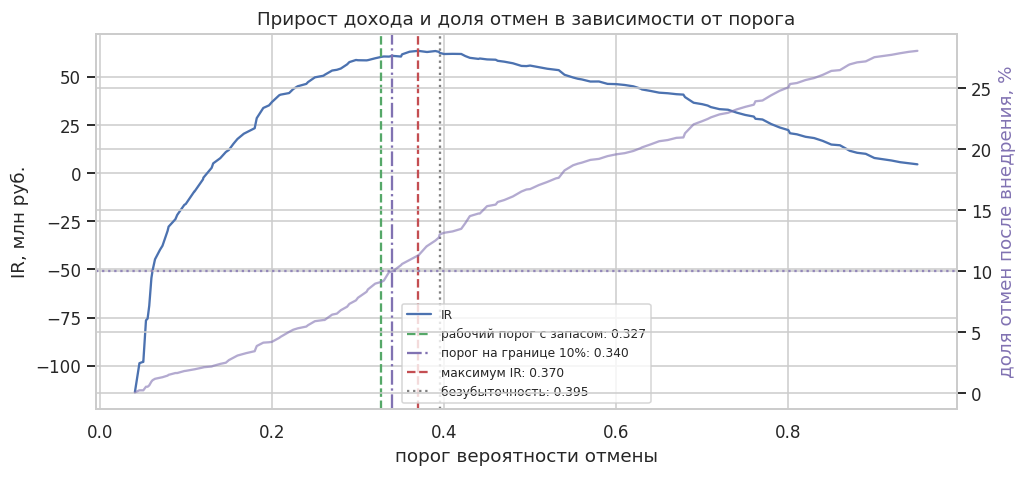

In [25]:
quantile_grid = np.quantile(proba_cal_calibrated, np.linspace(0.02, 0.98, 49))
threshold_grid = np.unique(np.round(
    np.concatenate([quantile_grid, THRESHOLD_GRID, [break_even]]), 4
))
threshold_table = fp.threshold_scan(y_cal, proba_cal_calibrated, threshold_grid)

threshold_max_ir = float(threshold_table.loc[threshold_table["IR"].idxmax(), "threshold"])

# Ограничение задачи - 10%, но оптимум всегда ложится ровно на границу, а доля отмен
# оценена по выборке. Стандартная ошибка доли при n = len(y_cal) задаёт запас, с которым
# берётся рабочий порог: цель должна выполняться и на новых данных, а не только в точке.
CANCEL_LIMIT = 10.0
cancel_rate_se = np.sqrt(0.10 * 0.90 / len(y_cal)) * 100
CANCEL_LIMIT_SAFE = round(CANCEL_LIMIT - 2 * cancel_rate_se, 2)

allowed_strict = threshold_table[threshold_table["cancel_after_%"] <= CANCEL_LIMIT]
threshold_at_limit = float(allowed_strict.loc[allowed_strict["IR"].idxmax(), "threshold"])
allowed_safe = threshold_table[threshold_table["cancel_after_%"] <= CANCEL_LIMIT_SAFE]
FINAL_THRESHOLD = float(allowed_safe.loc[allowed_safe["IR"].idxmax(), "threshold"])

display(pd.Series({
    "стандартная ошибка доли отмен, п.п.": round(cancel_rate_se, 3),
    "ограничение ТЗ, %": CANCEL_LIMIT,
    "ограничение с запасом в две ошибки, %": CANCEL_LIMIT_SAFE,
    "порог на границе ограничения": threshold_at_limit,
    "рабочий порог с запасом": FINAL_THRESHOLD,
}, name="запас по доле отмен").to_frame())

display(threshold_table.iloc[::4].round(3))

selected = threshold_table[threshold_table["threshold"].isin(
    [threshold_max_ir, FINAL_THRESHOLD, threshold_at_limit, round(break_even, 4)]
)].copy()
labels = []
for value in selected["threshold"]:
    if value == FINAL_THRESHOLD:
        labels.append(f"рабочий порог: максимум IR при доле отмен <= {CANCEL_LIMIT_SAFE}%")
    elif value == threshold_at_limit:
        labels.append("максимум IR ровно на границе 10%")
    elif value == threshold_max_ir:
        labels.append("максимум IR без ограничений")
    else:
        labels.append("порог безубыточности")
selected["комментарий"] = labels
selected["цель_по_отменам_выполнена"] = selected["cancel_after_%"] <= CANCEL_LIMIT
display(selected.round(3).set_index("комментарий"))

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(threshold_table["threshold"], threshold_table["IR"] / 1e6, color="#4C72B0", label="IR")
ax.axvline(FINAL_THRESHOLD, color="#55A868", linestyle="--",
           label=f"рабочий порог с запасом: {FINAL_THRESHOLD:.3f}")
ax.axvline(threshold_at_limit, color="#8172B2", linestyle="-.",
           label=f"порог на границе 10%: {threshold_at_limit:.3f}")
ax.axvline(threshold_max_ir, color="#C44E52", linestyle="--",
           label=f"максимум IR: {threshold_max_ir:.3f}")
ax.axvline(break_even, color="grey", linestyle=":", label=f"безубыточность: {break_even:.3f}")
ax_right = ax.twinx()
ax_right.plot(threshold_table["threshold"], threshold_table["cancel_after_%"],
              color="#8172B2", alpha=0.6)
ax_right.axhline(CANCEL_LIMIT, color="#8172B2", linestyle=":", alpha=0.8)
ax_right.set_ylabel("доля отмен после внедрения, %", color="#8172B2")
ax.set_title("Прирост дохода и доля отмен в зависимости от порога")
ax.set_xlabel("порог вероятности отмены")
ax.set_ylabel("IR, млн руб.")
ax.legend(fontsize=8, loc="lower center")
fig.tight_layout()
plt.show()

**Выводы по порогу классификации**

| Порог | Смысл | Относительный IR | Доля отмен | Цель по отменам |
|---|---|---|---|---|
| **0.327** | **рабочий: максимум IR при доле отмен <= 9.23%** | **+35.97%** | **9.14%** | **выполнена с запасом** |
| 0.340 | максимум IR ровно на границе 10% | +36.29% | 9.99% | выполнена впритык |
| 0.370 | безусловный максимум IR | +37.84% | 11.29% | не выполнена |
| 0.395 | порог безубыточности | +37.21% | 13.03% | не выполнена |

- Безусловный максимум IR на калибровочной выборке достигается при пороге **0.370** и даёт 63 625 000 руб. прироста (+37.84%), но доля отмен при нём 11.29%, выше требуемых 10%.
- **Оптимум с ограничением всегда ложится ровно на границу.** IR растёт с порогом вплоть до 0.370, поэтому задача «максимум IR при доле отмен не выше 10%» решается порогом 0.340, где доля отмен равна 9.99% - запас составляет меньше одной брони из 6 147. Доля отмен оценена по выборке, её стандартная ошибка - **0.383 процентных пункта**, то есть такой порог провалил бы цель на новых данных примерно в половине случаев.
- **Поэтому ограничение ужесточено на две стандартные ошибки, до 9.23%**, и рабочим стал порог **0.327**. Цена запаса невелика: 0.32 п.п. относительного IR, или 526 500 руб. на калибровочной выборке. Это прямое применение урока прошлых спринтов: при жёстком лимите порог берут с запасом, а не в угловой точке.
- Ограничение выполняется при порогах **не выше 0.340**: доля отмен после внедрения - это FN, и она растёт вместе с порогом (уже при 0.350 она равна 10.51%).
- Аналитический порог безубыточности **0.395 лежит выше эмпирического максимума 0.370**, и при нём IR уже на 1.06 млн руб. меньше. Расхождение - цена неидеальной калибровки: при точных вероятностях оптимум совпал бы с порогом безубыточности.
- Крайние пороги показывают цену ошибок наглядно: при 0.041 модель ловит почти все отмены (1 764 из 1 770), но 4 294 ложные тревоги уводят IR в минус на 67.7%.

**Итог:** зафиксирован рабочий порог **0.327**. Он выполняет цель по доле отмен с запасом на выборочный шум и стоит 1.87 п.п. относительного IR по сравнению с безусловным оптимумом.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

Сравниваем матрицы ошибок и IR на трёх выборках при одном и том же пороге: на обучающей (там модель училась, оценка оптимистична), на калибровочной (по ней подобран порог) и на тестовой. Разрыв между обучающей и отложенными показывает переобучение, разрыв между калибровочной и тестовой - переносимость порога.

порог 0.327,обучающая,калибровочная,тестовая,тест_к_калибровке_%,тест_к_обучению_%
n,"18,439.0000","6,147.0000","6,147.0000",NaN,NaN
TP,"3,810.0000","1,208.0000","1,223.0000",NaN,NaN
FP,"2,820.0000","1,004.0000","1,017.0000",NaN,NaN
FN,"1,500.0000",562.0000,547.0000,NaN,NaN
TN,"10,309.0000","3,373.0000","3,360.0000",NaN,NaN
IR_before,"504,325,500.0000","168,151,500.0000","168,151,500.0000",NaN,NaN
IR_after,"719,890,500.0000","228,641,500.0000","229,354,500.0000",NaN,NaN
IR,"215,565,000.0000","60,490,000.0000","61,203,000.0000",NaN,NaN
IR_rel_%,42.7432,35.9735,36.3975,1.1787,-14.8461
cancel_before_%,28.7977,28.7945,28.7945,0.0000,-0.0108


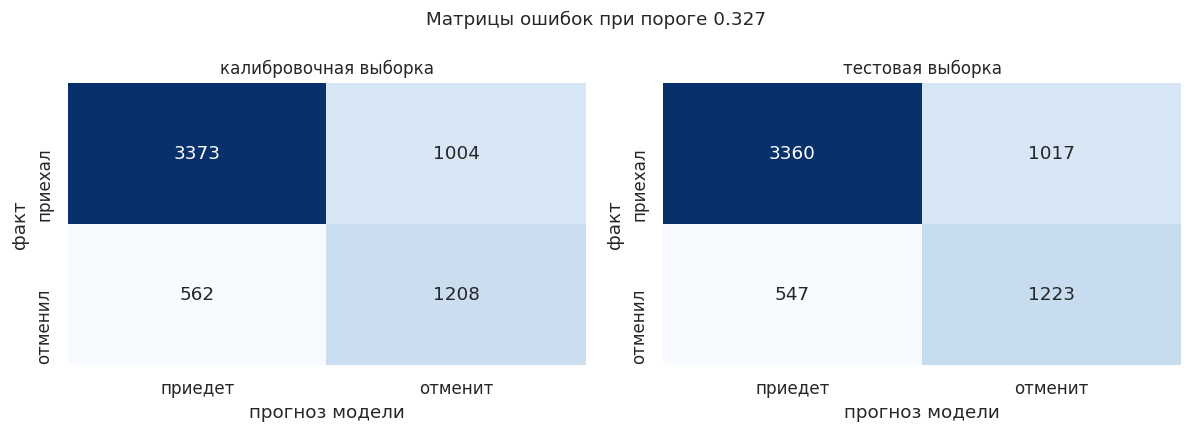

"тестовая выборка, порог 0.327",precision,recall,f1-score,support
нет_отказа,0.8600,0.7680,0.8110,"4,377.0000"
отказ_брони,0.5460,0.6910,0.6100,"1,770.0000"
accuracy,0.7460,0.7460,0.7460,0.7460
macro avg,0.7030,0.7290,0.7110,"6,147.0000"
weighted avg,0.7700,0.7460,0.7530,"6,147.0000"


In [26]:
proba_train = calibrated_model.predict_proba(A_train)[:, 1]
proba_test = calibrated_model.predict_proba(A_test)[:, 1]
pred_train = (proba_train >= FINAL_THRESHOLD).astype(int)
pred_cal = (proba_cal_calibrated >= FINAL_THRESHOLD).astype(int)
pred_test = (proba_test >= FINAL_THRESHOLD).astype(int)

metrics_train = fp.business_metrics(y_train, pred_train)
metrics_cal = fp.business_metrics(y_cal, pred_cal)
metrics_test = fp.business_metrics(y_test, pred_test)

stability = pd.DataFrame({
    "обучающая": metrics_train, "калибровочная": metrics_cal, "тестовая": metrics_test,
})
for name, proba, y_true, metrics in [
    ("обучающая", proba_train, y_train, metrics_train),
    ("калибровочная", proba_cal_calibrated, y_cal, metrics_cal),
    ("тестовая", proba_test, y_test, metrics_test),
]:
    stability.loc["ROC_AUC", name] = roc_auc_score(y_true, proba)
    stability.loc["PR_AUC", name] = average_precision_score(y_true, proba)
    stability.loc["recall_отмен", name] = metrics["TP"] / (metrics["TP"] + metrics["FN"])
    stability.loc["precision_отмен", name] = metrics["TP"] / (metrics["TP"] + metrics["FP"])
    stability.loc["IR_на_бронь_руб", name] = metrics["IR"] / metrics["n"]

# Проценты считаем только для относительных показателей: сравнивать счётчики
# и суммы между выборками разного размера бессмысленно.
absolute_rows = ["n", "TP", "FP", "FN", "TN", "IR_before", "IR_after", "IR"]
relative_mask = ~stability.index.isin(absolute_rows)
stability["тест_к_калибровке_%"] = np.where(
    relative_mask,
    (stability["тестовая"] - stability["калибровочная"]) / stability["калибровочная"].abs() * 100,
    np.nan,
)
stability["тест_к_обучению_%"] = np.where(
    relative_mask,
    (stability["тестовая"] - stability["обучающая"]) / stability["обучающая"].abs() * 100,
    np.nan,
)
stability.columns.name = f"порог {FINAL_THRESHOLD:.3f}"
display(stability.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_true, y_pred) in zip(
    axes,
    [("калибровочная выборка", y_cal, pred_cal), ("тестовая выборка", y_test, pred_test)],
):
    matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["приедет", "отменит"], yticklabels=["приехал", "отменил"])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("прогноз модели")
    ax.set_ylabel("факт")
fig.suptitle(f"Матрицы ошибок при пороге {FINAL_THRESHOLD:.3f}", fontsize=12)
fig.tight_layout()
plt.show()

report = pd.DataFrame(
    classification_report(y_test, pred_test, target_names=["нет_отказа", "отказ_брони"],
                          output_dict=True)
).T.round(3)
report.columns.name = f"тестовая выборка, порог {FINAL_THRESHOLD:.3f}"
display(report)

**Выводы о стабильности модели**

| Показатель | Обучающая | Калибровочная | Тестовая | Тест к калибровке | Тест к обучению |
|---|---|---|---|---|---|
| TP / FP / FN / TN | 3 810 / 2 820 / 1 500 / 10 309 | 1 208 / 1 004 / 562 / 3 373 | 1 223 / 1 017 / 547 / 3 360 | - | - |
| Относительный IR | +42.74% | +35.97% | +36.40% | +1.18% | -14.85% |
| IR на одну бронь | 11 691 руб. | 9 841 руб. | 9 957 руб. | +1.18% | -14.83% |
| ROC-AUC | 0.8353 | 0.8040 | 0.8164 | +1.54% | -2.26% |
| PR-AUC | 0.6984 | 0.6371 | 0.6649 | +4.36% | -4.81% |
| Recall отмен | 0.7175 | 0.6825 | 0.6910 | +1.24% | -3.70% |
| Precision отмен | 0.5747 | 0.5461 | 0.5460 | -0.02% | -4.99% |
| Доля отмен после внедрения | 8.13% | 9.14% | 8.90% | -2.67% | +9.39% |

- **Порог переносится на новые данные без потерь**: расхождение между калибровочной и тестовой выборками составляет **1.18% по IR** и 1.54% по ROC-AUC, причём в пользу теста. Доля отмен после внедрения на обеих отложенных выборках держится ниже цели: 9.14% на калибровочной и 8.90% на тестовой.
- **Переобучение измерено, а не заявлено**: на обучающей выборке относительный IR составляет 42.74% против 36.40% на тесте, ROC-AUC 0.8353 против 0.8164. Разрыв - **14.85% по IR и 2.26% по ROC-AUC**: умеренный оптимизм обучающей выборки, нормальный для бустинга на 18 439 строках, а не провал обобщения.
- Суммарный IR между выборками сравнивать нельзя (18 439 строк против 6 147), поэтому проценты расхождения посчитаны только для относительных показателей, а для счётчиков и сумм в таблице стоит прочерк. Нормированный показатель - **IR на одну бронь**: 11 691 руб. на обучающей против 9 957 руб. на тестовой.
- Структура ошибок на тесте: модель ловит 1 223 отмены из 1 770 (recall 0.691) при 1 017 ложных тревогах на 4 377 состоявшихся броней (доля ложных тревог 23.2%). Точность по классу отмен - 0.546.
- Слабое место видно в отчёте классификации: по классу `отказ_брони` f1 = 0.610 против 0.811 у класса `нет_отказа`. Модель уверенно распознаёт тех, кто приедет, и заметно хуже - тех, кто отменит. Именно это ограничивает экономический эффект.

**Итог:** модель стабильна, порог перенесён корректно, разрыв с обучающей выборкой измерен явно и остаётся умеренным.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


Фиксируем итоговое решение: препроцессор и откалиброванная модель собираются в один `Pipeline`, порог и метаданные сохраняются рядом. Проверяем сохранённый артефакт четырьмя тестами - от совпадения предсказаний до сквозного прогона от сырых данных.

In [27]:
final_pipeline = Pipeline([("preprocessor", preprocessor), ("model", calibrated_model)])

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / "model.joblib"
META_PATH = ARTIFACTS_DIR / "model_meta.json"

predictions_before_save = final_pipeline.predict_proba(X_test_final)[:, 1]
joblib.dump(
    {"pipeline": final_pipeline, "threshold": FINAL_THRESHOLD, "with_demand": bool(USE_DEMAND)},
    MODEL_PATH,
)

metadata = {
    "model": best_model_name,
    "best_params": best_params,
    "threshold": FINAL_THRESHOLD,
    "threshold_max_ir_unconstrained": threshold_max_ir,
    "with_demand_features": bool(USE_DEMAND),
    "random_state": RANDOM_STATE,
    "ir_cv": float(FINAL_IR_CV),
    "ir_calibration": float(metrics_cal["IR"]),
    "ir_test": float(metrics_test["IR"]),
    "ir_rel_test_%": float(metrics_test["IR_rel_%"]),
    "roc_auc_test": float(roc_auc_score(y_test, proba_test)),
    "numeric_cols": fp.numeric_cols(USE_DEMAND),
    "categorical_cols": fp.CATEGORICAL_COLS,
    "text_col": fp.TEXT_COL,
    "economics": {"AvgRev": fp.AVG_REV, "CostFP": fp.COST_FP,
                  "LostRev": fp.LOST_REV, "PerRebooking": fp.PER_REBOOKING},
}
with open(META_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

# Модуль с функциями признаков кладём рядом с моделью: без него артефакт не развернуть.
shutil.copy(fp.__file__, ARTIFACTS_DIR / "feature_pipeline.py")

loaded = joblib.load(MODEL_PATH)
loaded_pipeline, loaded_threshold = loaded["pipeline"], loaded["threshold"]
predictions_after_load = loaded_pipeline.predict_proba(X_test_final)[:, 1]

raw_sample = bookings_raw.head(500)
features_from_raw = fp.build_features(
    fp.add_demand_features(fp.join_reviews(fp.clean_bookings(raw_sample), reviews)),
    with_demand=USE_DEMAND,
)
end_to_end = loaded_pipeline.predict_proba(features_from_raw)[:, 1]

checks = pd.DataFrame(
    [
        ["предсказания до и после сохранения совпадают",
         bool(np.allclose(predictions_before_save, predictions_after_load))],
        ["сквозной прогон сырые данные -> признаки -> модель отрабатывает",
         bool(len(end_to_end) == len(raw_sample.drop_duplicates()))],
        ["функции признаков берутся из модуля feature_pipeline",
         fp.build_features.__module__ == "feature_pipeline"],
        ["IR на тесте после загрузки совпадает с исходным",
         fp.business_metrics(y_test, (predictions_after_load >= loaded_threshold).astype(int))["IR"]
         == metrics_test["IR"]],
    ],
    columns=["проверка", "результат"],
).set_index("проверка")
display(checks)

display(pd.Series({
    "модель": best_model_name,
    "рабочий порог": round(FINAL_THRESHOLD, 4),
    "порог максимума IR без ограничений": round(threshold_max_ir, 4),
    "признаки спроса включены": bool(USE_DEMAND),
    "файл модели": str(MODEL_PATH),
    "файл метаданных": str(META_PATH),
    "размер модели, МБ": round(MODEL_PATH.stat().st_size / 1024 ** 2, 2),
}, name="итоговый артефакт").to_frame())

,результат
проверка,
предсказания до и после сохранения совпадают,True
сквозной прогон сырые данные -> признаки -> модель отрабатывает,True
функции признаков берутся из модуля feature_pipeline,True
IR на тесте после загрузки совпадает с исходным,True


,итоговый артефакт
модель,CatBoost
рабочий порог,0.3272
порог максимума IR без ограничений,0.3700
признаки спроса включены,False
файл модели,artifacts/model.joblib
файл метаданных,artifacts/model_meta.json
"размер модели, МБ",0.3400


**Выводы по фиксации модели**

- Итоговое решение - `Pipeline` из препроцессора (импьютер, one-hot, TF-IDF) и откалиброванного CatBoost, рабочий порог **0.327**. Артефакт весит 0.34 МБ и сохранён в `artifacts/model.joblib` вместе с порогом и флагом набора признаков.
- В `artifacts/model_meta.json` записаны гиперпараметры без округления, оба порога (рабочий 0.327 и безусловный максимум IR 0.370), `random_state`, метрики IR и ROC-AUC, список колонок и экономические константы. Округление гиперпараметров в метаданных дало бы при переобучении другую модель, поэтому значения сохранены как есть.
- Рядом с моделью положена копия `feature_pipeline.py`: без неё артефакт не развернуть, потому что инференс начинается с `clean_bookings`, `join_reviews` и `build_features`.
- **Все четыре проверки артефакта пройдены**: предсказания до и после сохранения совпадают, сквозной прогон «сырые данные - признаки - модель» отрабатывает, функции признаков берутся из канонического модуля `feature_pipeline`, IR на тесте после загрузки совпадает с исходным.

**Итог:** модель воспроизводима и готова к передаче в эксплуатацию.

### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

Важность признаков считаем через SHAP: в отличие от встроенного `feature_importances_`, SHAP показывает не только силу, но и направление влияния.

**Вклады one-hot дамми сворачиваем обратно к исходным признакам** - складываем их внутри строки и только потом берём модуль. Без этого один признак дробится на несколько строк рейтинга, а его суммарный вклад занижается: `sales_channel` разложился бы на три дамми, `lead_time_group` - на четыре.

Второй уровень свёртки - по бизнес-драйверам. Один и тот же фактор может быть представлен двумя признаками: срок до заезда входит и числом (`days_until_checkin`), и категоризацией (`lead_time_group`), история клиента - четырьмя разными счётчиками. Для выводов заказчику складываем и их: иначе рейтинг отдельных колонок вводит в заблуждение так же, как дробление на дамми.

Значения считаем на калибровочной выборке, чтобы не трогать отложенный тест. Объясняем базовую (не откалиброванную) модель: `CalibratedClassifierCV` обучает три копии модели на подвыборках train и усредняет их, то есть это не монотонное преобразование исходной модели, а ансамбль. Базовая модель обучена на тех же данных с теми же гиперпараметрами и служит прокси; совпадение ранжирования проверяем на одной из моделей ансамбля.

,средний_модуль_SHAP,доля_вклада_%,направление
признак,,,
sales_channel,0.4647,22.0300,категориальный: см. таблицу эффектов
days_until_checkin,0.4459,21.1400,рост признака повышает риск отмены
child_count,0.3064,14.5300,немонотонное влияние: см. таблицу эффектов
total_nights,0.2777,13.1700,немонотонное влияние: см. таблицу эффектов
previous_cancellations,0.1866,8.8500,рост признака повышает риск отмены
lead_time_group,0.1283,6.0800,категориальный: см. таблицу эффектов
review_text (TF-IDF),0.0709,3.3600,"текстовый блок из 60 колонок, направление не о..."
customer_loyalty,0.0675,3.2000,рост признака снижает риск отмены
weekend_share,0.0288,1.3600,немонотонное влияние: см. таблицу эффектов


,суммарный_вклад_%,признаки
бизнес-драйвер,,
состав и длительность поездки,29.4700,"child_count, total_nights, guests_total, weeke..."
горизонт планирования,27.2200,"days_until_checkin, lead_time_group"
канал продаж,22.0300,sales_channel
история клиента,12.4900,"previous_cancellations, previous_no_shows, cus..."
отзывы,3.4900,"review_text (TF-IDF), stay_rating, review_lag_..."


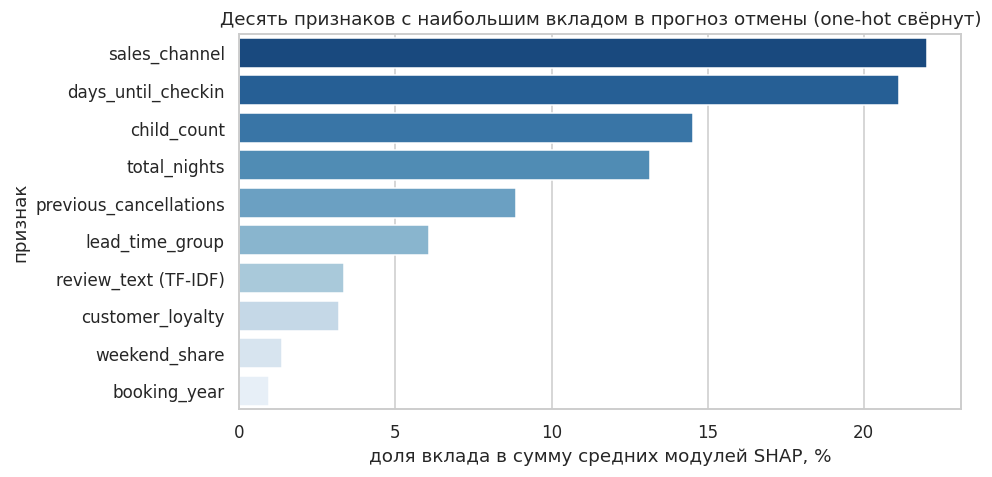

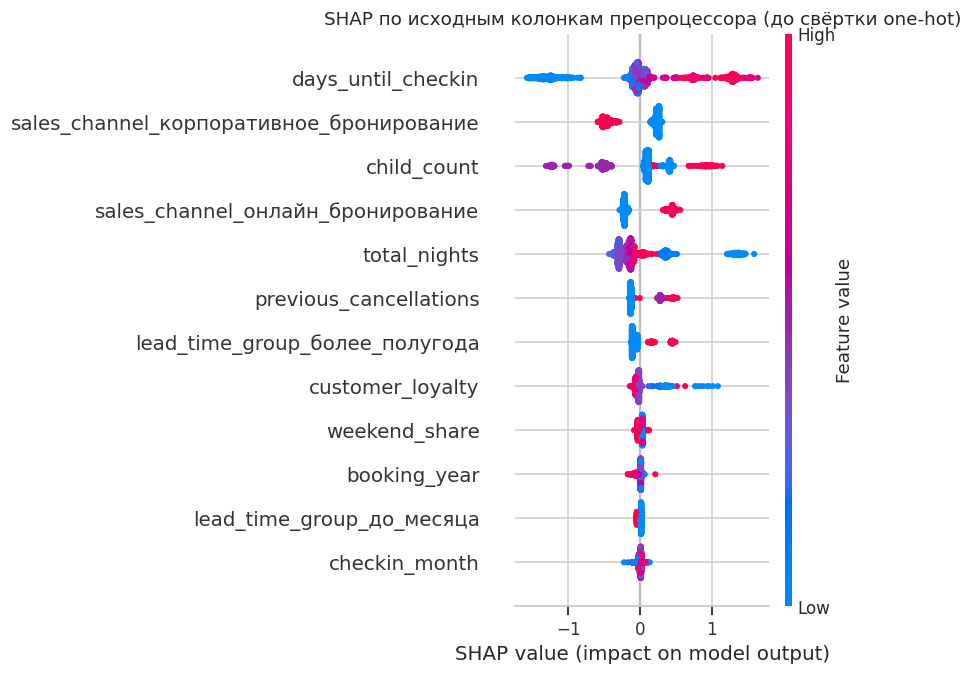

"топ-10: состав совпал на 10 из 10, порядок - на 8 из 10",ранг у прокси-модели,ранг у модели ансамбля
признак,,
sales_channel,1,1
days_until_checkin,2,2
child_count,3,3
total_nights,4,4
previous_cancellations,5,5
lead_time_group,6,6
review_text (TF-IDF),7,7
customer_loyalty,8,8
weekend_share,9,10


In [28]:
explainer = shap.TreeExplainer(base_model)
shap_sample_index = np.random.RandomState(RANDOM_STATE).choice(
    A_cal.shape[0], size=min(2000, A_cal.shape[0]), replace=False
)
shap_sample = A_cal[shap_sample_index]
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[-1]

collapsed_values, collapsed_names = fp.collapse_onehot(
    shap_values, feature_names, with_demand=USE_DEMAND
)

importance = (
    pd.DataFrame({
        "признак": collapsed_names,
        "средний_модуль_SHAP": np.abs(collapsed_values).mean(axis=0),
    })
    .sort_values("средний_модуль_SHAP", ascending=False)
    .reset_index(drop=True)
)
importance["доля_вклада_%"] = (
    importance["средний_модуль_SHAP"] / importance["средний_модуль_SHAP"].sum() * 100
).round(2)

# Направление влияния определено для числовых признаков: знак корреляции значения
# признака с его вкладом. Для категориальных направление показывает таблица эффектов ниже.
numeric_set = set(fp.numeric_cols(USE_DEMAND))
directions = {}
for position, name in enumerate(collapsed_names):
    if name.startswith("review_text"):
        directions[name] = "текстовый блок из 60 колонок, направление не определяется"
        continue
    if name not in numeric_set:
        directions[name] = "категориальный: см. таблицу эффектов"
        continue
    column = shap_sample[:, feature_names.index(name)]
    if np.std(column) == 0:
        directions[name] = "константа"
        continue
    # Знак корреляции - монотонная мера, поэтому сначала проверяем саму монотонность:
    # средний вклад по группам признака должен идти в одну сторону. Дискретные признаки
    # группируем по значению (qcut на трёх уровнях схлопнул бы их в два бина и признал
    # монотонными любые данные), непрерывные - по квинтилям.
    series = pd.Series(column)
    if series.nunique() <= 10:
        groups = series
    else:
        groups = pd.qcut(series, q=5, duplicates="drop", labels=False)
    grouped = pd.Series(collapsed_values[:, position]).groupby(groups)
    binned = grouped.mean()[grouped.size() >= 0.02 * len(series)]
    span = binned.iloc[-1] - binned.iloc[0]
    if len(binned) < 2 or abs(span) < 1e-9:
        directions[name] = "влияние без выраженного направления"
        continue
    # Крайние группы задают направление; если внутренняя группа выходит за их коридор
    # больше чем на 20% размаха, влияние немонотонное и одним словом не описывается.
    low_edge, high_edge = min(binned.iloc[0], binned.iloc[-1]), max(binned.iloc[0], binned.iloc[-1])
    excess = max(binned.max() - high_edge, low_edge - binned.min(), 0) / abs(span)
    if excess > 0.2:
        directions[name] = "немонотонное влияние: см. таблицу эффектов"
    else:
        directions[name] = ("рост признака повышает риск отмены" if span > 0
                            else "рост признака снижает риск отмены")
importance["направление"] = importance["признак"].map(directions)
top_features = importance.head(10)
display(top_features.set_index("признак"))

# Один бизнес-драйвер может быть представлен двумя признаками: срок до заезда входит
# и числом, и категоризацией. Для выводов складываем их вклады.
DRIVERS = {
    "горизонт планирования": ["days_until_checkin", "lead_time_group"],
    "канал продаж": ["sales_channel"],
    "состав и длительность поездки": ["child_count", "total_nights", "guests_total", "weekend_share"],
    "история клиента": ["previous_cancellations", "previous_no_shows", "customer_loyalty",
                        "returning_customer"],
    "отзывы": ["review_text (TF-IDF)", "stay_rating", "review_lag_days"],
}
share = importance.set_index("признак")["доля_вклада_%"]
drivers = pd.DataFrame(
    [[name, round(share.reindex(columns).fillna(0).sum(), 2), ", ".join(columns)]
     for name, columns in DRIVERS.items()],
    columns=["бизнес-драйвер", "суммарный_вклад_%", "признаки"],
).set_index("бизнес-драйвер").sort_values("суммарный_вклад_%", ascending=False)
display(drivers)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=top_features, y="признак", x="доля_вклада_%", ax=ax, palette="Blues_r")
ax.set_title("Десять признаков с наибольшим вкладом в прогноз отмены (one-hot свёрнут)")
ax.set_xlabel("доля вклада в сумму средних модулей SHAP, %")
ax.set_ylabel("признак")
fig.tight_layout()
plt.show()

shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, max_display=12, show=False)
plt.title("SHAP по исходным колонкам препроцессора (до свёртки one-hot)")
plt.tight_layout()
plt.show()

# Проверяем, что прокси-модель ранжирует признаки так же, как модель из откалиброванного ансамбля.
ensemble_member = calibrated_model.calibrated_classifiers_[0].base_estimator
member_values = shap.TreeExplainer(ensemble_member).shap_values(shap_sample)
if isinstance(member_values, list):
    member_values = member_values[-1]
member_collapsed, _ = fp.collapse_onehot(member_values, feature_names, with_demand=USE_DEMAND)
member_importance = pd.Series(
    np.abs(member_collapsed).mean(axis=0), index=collapsed_names
).sort_values(ascending=False)
proxy_rank = pd.Series(range(1, len(importance) + 1), index=importance["признак"].values)
member_rank = pd.Series(range(1, len(member_importance) + 1), index=member_importance.index)
ranking_check = pd.DataFrame({
    "ранг у прокси-модели": proxy_rank,
    "ранг у модели ансамбля": member_rank.reindex(proxy_rank.index),
}).sort_values("ранг у прокси-модели").head(10)
ranking_check.index.name = "признак"
matched = int((ranking_check["ранг у прокси-модели"] == ranking_check["ранг у модели ансамбля"]).sum())
same_set = len(set(ranking_check.index) & set(member_importance.head(10).index))
ranking_check.columns.name = (
    f"топ-10: состав совпал на {same_set} из 10, порядок - на {matched} из 10"
)
display(ranking_check)

Чтобы перевести важность на язык заказчика, для ключевых признаков считаем фактическую долю отмен в крайних группах на калибровочной выборке: это и есть ответ на вопрос «на сколько процентных пунктов признак меняет риск». Отдельно смотрим пересечение двух главных факторов риска - канала продаж и срока до заезда.

"калибровочная выборка, средняя доля отмен 28.79%",нижняя_группа,верхняя_группа,доля_отмен_нижняя_%,доля_отмен_верхняя_%,броней_нижняя,броней_верхняя,оговорка,разрыв_п_п,риск_растёт_с_признаком
признак,,,,,,,,,
days_until_checkin,нижний квартиль срока,верхний квартиль срока,15.2200,47.5800,1597,1526,,32.3600,True
total_nights,короткое проживание,длинное проживание,38.0500,25.9300,1569,1396,,-12.1200,False
weekend_share,мало выходных ночей,много выходных ночей,38.0500,26.0000,1569,3031,верхняя группа - выше медианы,-12.0500,False
price_per_night,дешёвые ночи,дорогие ночи,28.9000,29.3300,4568,1350,"признак почти константа, эффект неизмерим",0.4300,True
customer_loyalty,низкая лояльность,высокая лояльность,31.8500,20.4500,3626,719,,-11.4000,False
booking_year,ранние годы выгрузки,поздние годы выгрузки,29.5500,24.3200,2240,888,,-5.2300,False
previous_cancellations,без отмен в прошлом,были отмены в прошлом,25.3800,36.9800,4338,1809,,11.6000,True
previous_no_shows,без прошлых заездов,были прошлые заезды,29.1700,28.5100,2653,3494,,-0.6600,False
customer_special_requests,без пожеланий,есть пожелания,29.1800,28.3200,3396,2751,,-0.8600,False


child_count,0,1,2
"child_count, калибровочная выборка",,,
броней,"4,306.0000","1,491.0000",350.0000
доля_отмен_%,31.7700,15.4300,49.1400


previous_cancellations,0,1,2,3,4,5
"previous_cancellations, калибровочная выборка",,,,,,
броней,"4,338.0000","1,422.0000",317.0000,60.0000,7.0000,3.0000
доля_отмен_%,25.3800,33.6100,47.3200,58.3300,42.8600,100.0000


total_nights,"(0.999, 5.0]","(5.0, 8.0]","(8.0, 11.0]","(11.0, 21.0]"
"total_nights по квартилям, калибровочная выборка",,,,
броней,"1,569.0000","1,801.0000","1,381.0000","1,396.0000"
доля_отмен_%,38.0500,25.6500,25.2700,25.9300


weekend_share,"(-0.001, 0.222]","(0.222, 0.286]"
"weekend_share по квартилям, калибровочная выборка",,
броней,"3,116.0000","3,031.0000"
доля_отмен_%,31.5100,26.0000


"доля отмен, %",1-3_месяца,3-6_месяцев,более_полугода,до_месяца
sales_channel,,,,
корпоративное_бронирование,13.5500,12.6100,38.3900,7.5300
онлайн_бронирование,43.3200,37.8200,69.5400,21.5200
офлайн_бронирование,27.0700,28.0200,57.4800,11.6100


число броней,1-3_месяца,3-6_месяцев,более_полугода,до_месяца
sales_channel,,,,
корпоративное_бронирование,561,690,323,465
онлайн_бронирование,584,624,348,474
офлайн_бронирование,628,621,381,448


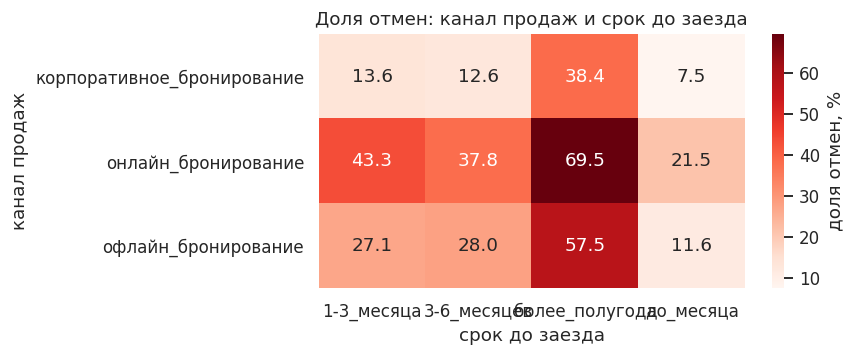

In [29]:
cal_frame = X_cal_final.copy()
cal_frame["is_cancelled"] = y_cal
base_rate = cal_frame["is_cancelled"].mean()

effects = []
for column, low_label, high_label, rule in [
    ("days_until_checkin", "нижний квартиль срока", "верхний квартиль срока", "quartile"),
    ("total_nights", "короткое проживание", "длинное проживание", "quartile"),
    ("weekend_share", "мало выходных ночей", "много выходных ночей", "quartile"),
    ("price_per_night", "дешёвые ночи", "дорогие ночи", "quartile"),
    ("customer_loyalty", "низкая лояльность", "высокая лояльность", "quartile"),
    ("booking_year", "ранние годы выгрузки", "поздние годы выгрузки", "quartile"),
    ("previous_cancellations", "без отмен в прошлом", "были отмены в прошлом", "zero"),
    ("previous_no_shows", "без прошлых заездов", "были прошлые заезды", "zero"),
    ("customer_special_requests", "без пожеланий", "есть пожелания", "zero"),
    ("child_count", "без детей", "с детьми", "zero"),
]:
    values = cal_frame[column]
    if rule == "zero":
        low_mask, high_mask = values == 0, values > 0
    else:
        # Верхняя группа строго выше третьего квартиля: иначе у признака с Q1 = Q3
        # обе группы включали бы одни и те же строки и разрыв был бы артефактом.
        low_mask, high_mask = values <= values.quantile(0.25), values > values.quantile(0.75)
        if not high_mask.any():
            # Q3 совпал с максимумом - берём всё, что выше медианы.
            high_mask = values > values.median()
    degenerate = values.quantile(0.25) == values.quantile(0.75)
    effects.append([
        column, low_label, high_label,
        round(cal_frame.loc[low_mask, "is_cancelled"].mean() * 100, 2) if low_mask.any() else np.nan,
        round(cal_frame.loc[high_mask, "is_cancelled"].mean() * 100, 2) if high_mask.any() else np.nan,
        int(low_mask.sum()), int(high_mask.sum()),
        "признак почти константа, эффект неизмерим" if degenerate
        else ("верхняя группа - выше медианы" if not (values > values.quantile(0.75)).any()
              and rule == "quartile" else ""),
    ])

for column in ["sales_channel", "season_group", "lead_time_group", "room_type", "meal_plan"]:
    rates = cal_frame.groupby(column)["is_cancelled"].mean() * 100
    counts = cal_frame.groupby(column)["is_cancelled"].size()
    effects.append([
        column, f"{rates.idxmin()}", f"{rates.idxmax()}",
        round(rates.min(), 2), round(rates.max(), 2),
        int(counts[rates.idxmin()]), int(counts[rates.idxmax()]),
    ])

effects = pd.DataFrame(
    effects,
    columns=["признак", "нижняя_группа", "верхняя_группа",
             "доля_отмен_нижняя_%", "доля_отмен_верхняя_%", "броней_нижняя", "броней_верхняя",
             "оговорка"],
).set_index("признак")
effects["разрыв_п_п"] = (effects["доля_отмен_верхняя_%"] - effects["доля_отмен_нижняя_%"]).round(2)
# Знак разрыва и показывает направление: положительный - риск растёт с признаком.
effects["риск_растёт_с_признаком"] = effects["разрыв_п_п"] > 0
effects.columns.name = f"калибровочная выборка, средняя доля отмен {base_rate * 100:.2f}%"
display(effects)

# Немонотонные признаки разбираем по всем уровням, а не по бинарному разрезу:
# дискретные - по значению, непрерывные - по квартилям.
for column in ["child_count", "previous_cancellations"]:
    levels = cal_frame.groupby(column)["is_cancelled"].agg(["size", "mean"])
    levels.columns = ["броней", "доля_отмен"]
    levels["доля_отмен_%"] = (levels["доля_отмен"] * 100).round(2)
    levels = levels.drop(columns="доля_отмен")
    levels.columns.name = f"{column}, калибровочная выборка"
    display(levels.T)

for column in ["total_nights", "weekend_share"]:
    quartiles = pd.qcut(cal_frame[column], q=4, duplicates="drop")
    levels = cal_frame.groupby(quartiles)["is_cancelled"].agg(["size", "mean"])
    levels.columns = ["броней", "доля_отмен"]
    levels["доля_отмен_%"] = (levels["доля_отмен"] * 100).round(2)
    levels = levels.drop(columns="доля_отмен")
    levels.columns.name = f"{column} по квартилям, калибровочная выборка"
    display(levels.T)

# Пересечение двух главных факторов: канал продаж на срок до заезда.
segment_rate = pd.crosstab(
    cal_frame["sales_channel"], cal_frame["lead_time_group"],
    values=cal_frame["is_cancelled"], aggfunc="mean",
).round(4) * 100
segment_size = pd.crosstab(cal_frame["sales_channel"], cal_frame["lead_time_group"])
segment_rate.columns.name = "доля отмен, %"
segment_size.columns.name = "число броней"
display(segment_rate.round(2))
display(segment_size)

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.heatmap(segment_rate.round(1), annot=True, fmt=".1f", cmap="Reds", ax=ax,
            cbar_kws={"label": "доля отмен, %"})
ax.set_title("Доля отмен: канал продаж и срок до заезда")
ax.set_xlabel("срок до заезда")
ax.set_ylabel("канал продаж")
fig.tight_layout()
plt.show()

**Выводы по важности признаков**

Десять признаков с наибольшим вкладом (вклады one-hot дамми свёрнуты обратно к исходным признакам):

| Признак | Вклад | Направление |
|---|---|---|
| `sales_channel` | 22.03% | категориальный, см. таблицу эффектов |
| `days_until_checkin` | 21.14% | рост повышает риск отмены |
| `child_count` | 14.53% | немонотонное влияние |
| `total_nights` | 13.17% | немонотонное влияние |
| `previous_cancellations` | 8.85% | рост повышает риск отмены |
| `lead_time_group` | 6.08% | категоризация срока до заезда |
| `review_text` (TF-IDF) | 3.36% | блок из 60 колонок, направление не определяется |
| `customer_loyalty` | 3.20% | рост снижает риск отмены |
| `weekend_share` | 1.36% | немонотонное влияние |
| `booking_year` | 0.96% | рост снижает риск отмены |

**Направление проверяется на монотонность, а не берётся из знака корреляции.** Средний вклад считается по группам признака, и если внутренняя группа выходит за коридор крайних больше чем на 20% размаха, влияние помечается немонотонным. Именно так `child_count` не получил ярлык «снижает риск»: на калибровочной выборке без детей отменяется **31.77%** броней (4 306 шт.), с одним ребёнком - **15.43%** (1 491), с двумя - **49.14%** (350). Одним словом такое влияние не описывается.

**Второй уровень свёртки - по бизнес-драйверам**, потому что один фактор может быть представлен несколькими признаками:

| Драйвер | Вклад | Из чего складывается |
|---|---|---|
| состав и длительность поездки | 29.47% | `child_count`, `total_nights`, `guests_total`, `weekend_share` |
| **горизонт планирования** | **27.22%** | `days_until_checkin` + `lead_time_group` |
| **канал продаж** | **22.03%** | `sales_channel` |
| история клиента | 12.49% | `previous_cancellations`, `previous_no_shows`, `customer_loyalty`, `returning_customer` |
| отзывы | 3.49% | 60 колонок TF-IDF, `stay_rating`, `review_lag_days` |

Из этой таблицы видно, что называть канал продаж главным фактором нельзя: срок до заезда в двух представлениях даёт **27.22%** против 22.03% у канала. Первая строка (29.47%) - это не один рычаг, а четыре разных свойства поездки, поэтому как управленческий вывод она не читается.

Числовые эффекты на калибровочной выборке (средняя доля отмен 28.79%). Группы в таблице названы нейтрально - «нижняя» и «верхняя», а направление показывает знак разрыва: у шести числовых признаков из десяти риск падает с ростом значения, поэтому подписи «низкий/высокий риск» были бы перевёрнутыми:

- **Срок до заезда**: в нижнем квартиле отменяется **15.22%** броней, в верхнем - **47.58%**, разрыв 32.36 п.п. В категоризованном виде разрыв ещё шире: 13.63% для «до месяца» против 55.61% для «более полугода».
- **Канал продаж**: корпоративные брони отменяются в **15.79%** случаев, онлайн - в **41.03%**, разрыв 25.24 п.п.
- **Пересечение двух главных факторов** даёт зону максимального риска: онлайн-бронь, оформленная более чем за полгода, отменяется в **69.54%** случаев (348 броней), тогда как корпоративная бронь за месяц до заезда - в **7.53%** (465 броней). Разница в девять раз.
- **История клиента растёт монотонно почти до конца**: 25.38% отмен без прошлых отмен (4 338 броней), 33.61% с одной (1 422), 47.32% с двумя (317), 58.33% с тремя (60). Значения при четырёх и пяти прошлых отменах посчитаны на 7 и 3 бронях и в выводы не выносятся.
- **Лояльность клиента**: в нижнем квартиле - **31.85%**, в верхнем - **20.45%**, разрыв 11.40 п.п. в пользу лояльных.
- **Длительность поездки влияет немонотонно, и разбор по квартилям это показывает**: до 5 ночей отменяется **38.05%** броней (1 569 шт.), от 5 до 8 ночей - 25.65%, от 8 до 11 - 25.27%, свыше 11 - 25.93%. Риск повышен только у самых коротких поездок, дальше уровень ровный, поэтому формулировка «чем длиннее поездка, тем реже отменяют» была бы неверной.
- **Доля выходных ночей**: квартильное разбиение схлопывается в две группы, потому что признак принимает мало значений. В группе с долей до 0.222 отменяется **31.51%** броней (3 116 шт.), выше - **26.00%** (3 031).
- **Год оформления**: ранние годы выгрузки - 29.55%, поздние - 24.32%. Это особенность периода наблюдений, а не управляемый фактор.
- **Не работают**: число пожеланий (разрыв 0.86 п.п.), наличие прошлых заездов (0.66 п.п.), тип питания (1.50 п.п.) и сезонность (2.27 п.п.).
- **Стоимость ночи измерить нельзя**: первый и третий квартили `price_per_night` совпадают на 6 700 руб., поэтому таблица помечает признак как почти константу. Разрыв 0.43 п.п. между «дешёвыми» и «дорогими» ночами - следствие вырожденного распределения, а не доказательство отсутствия влияния цены.
- Разрыв по типу номера (19.23% против 50.00%) в выводы выносить нельзя: крайняя категория `тип_3` встречается в калибровочной выборке **два раза**.
- **Все 60 текстовых признаков дают суммарно 3.36%** - прямое подтверждение вывода EDA: при честном объединении по дате отзыв относится к чужой поездке и предсказательной силы почти не несёт.

Объясняется базовая модель, а не откалиброванный ансамбль: `CalibratedClassifierCV` обучает три копии модели на подвыборках train и усредняет их, то есть это не монотонное преобразование исходной модели. Базовая модель обучена на тех же данных с теми же гиперпараметрами и работает как прокси; сверка с одной из моделей ансамбля показывает, что **состав топ-10 совпадает полностью, а порядок - в 8 позициях из 10** (местами меняются только `weekend_share` и `booking_year` с вкладом около 1%).

**Итог:** отмену определяют горизонт планирования, канал продаж и прошлое поведение клиента. Это управляемые факторы: на них можно влиять политикой предоплаты и работой с каналами, а не только реагировать прогнозом.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


Все показатели считаются на тестовой выборке: «до внедрения» - по фактическим значениям `y_test`, «после внедрения» - по предсказаниям модели `y_pred`.

**Формулы:**

$$IR_{до} = TotalSuccess \cdot AvgRev - TotalCancellations \cdot LostRev$$

$$IR_{после} = TP \cdot PerRebooking + TN \cdot AvgRev - FP \cdot CostFP - FN \cdot LostRev$$

$$\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \cdot 100\%$$

$$\text{Динамика загрузки} = \frac{\text{Загрузка до} - \text{Загрузка после}}{\text{Загрузка до}} \cdot 100\%$$

**Принятые допущения:**

- отмены после внедрения - только незамеченные отмены (FN): по замеченным номер перепродан, и простоя нет;
- занятые номера до внедрения - состоявшиеся брони; после внедрения - вовремя перепроданные отмены (TP) и брони, которые модель оставила в силе и которые состоялись (TN). Номера из FP отель тоже сдаёт повторно, но исходный гость приезжает, поэтому в основном расчёте они в загрузку не засчитываются: это консервативная оценка. Вариант с учётом FP показан рядом;
- доступные номера ТЗ предписывает брать как средние за периоды до тестирования и во время тестирования - этот расчёт выполнен в таблице ниже, и его результат подставляется в формулу загрузки.

In [30]:
# Доступные номера как средние за периоды: ТЗ требует брать именно средние.
booking_dates_all = data["booking_date"]
mask_test = np.zeros(len(data), dtype=bool)
mask_test[idx_test] = True

# Разбиение случайное, поэтому обе части лежат на одном календарном отрезке: делим
# на общее число дней периода, иначе среднесуточная ёмкость теста была бы завышена.
days_period = booking_dates_all.nunique()
calendar_days = (booking_dates_all.max() - booking_dates_all.min()).days + 1
rooms_per_day_before = (~mask_test).sum() / days_period
rooms_per_day_test = mask_test.sum() / days_period

rooms_table = pd.DataFrame(
    [
        ["строки вне теста (train + calibration)", int((~mask_test).sum()),
         int(days_period), round(rooms_per_day_before, 2)],
        ["строки теста", int(mask_test.sum()), int(days_period), round(rooms_per_day_test, 2)],
    ],
    columns=["часть выгрузки", "броней", "дат с бронями", "броней на дату с бронями"],
).set_index("часть выгрузки")
rooms_table.loc["отношение"] = [
    round((~mask_test).sum() / mask_test.sum(), 2), 1.0,
    round(rooms_per_day_before / rooms_per_day_test, 2),
]
rooms_table.columns.name = (
    f"средняя ёмкость за период: {int(days_period)} дат с бронями "
    f"на {int(calendar_days)} календарных дней"
)
display(rooms_table)

# Загрузка до внедрения, посчитанная двумя способами: по средним за период и по суммам.
ROOMS_TEST = int(mask_test.sum())
occupied_before = int((y_test == 0).sum())
occupancy_by_averages = (occupied_before / days_period) / rooms_per_day_test
occupancy_by_totals = occupied_before / ROOMS_TEST
assert np.isclose(occupancy_by_averages, occupancy_by_totals)
display(pd.Series({
    "занятых номеров в сутки (среднее за период)": round(occupied_before / days_period, 3),
    "доступных номеров в сутки (среднее за период)": round(rooms_per_day_test, 3),
    "загрузка до внедрения по средним, %": round(occupancy_by_averages * 100, 4),
    "загрузка до внедрения по суммам, %": round(occupancy_by_totals * 100, 4),
}, name="эквивалентность двух способов расчёта").to_frame())

средняя ёмкость за период: 2445 дат с бронями на 3217 календарных дней,броней,дат с бронями,броней на дату с бронями
часть выгрузки,,,
строки вне теста (train + calibration),"24,586.0000","2,445.0000",10.0600
строки теста,"6,147.0000","2,445.0000",2.5100
отношение,4.0000,1.0000,4.0000


,эквивалентность двух способов расчёта
занятых номеров в сутки (среднее за период),1.7900
доступных номеров в сутки (среднее за период),2.5140
"загрузка до внедрения по средним, %",71.2055
"загрузка до внедрения по суммам, %",71.2055


**Что показывает эта таблица.** Разбиение выборок случайное, поэтому обе части лежат на одном и том же календарном отрезке, и «период до тестирования» отличается от «периода тестирования» не длиной и не ёмкостью отелей, а только долей строк: 80% против 20%. Это видно по отношению среднесуточных величин - ровно 4.0. Подставлять ёмкость обучающей части в знаменатель «до» было бы ошибкой: загрузка до внедрения оказалась бы вчетверо ниже фактической при тех же самых бронях.

Поэтому доступные номера в обоих сценариях - это средняя ёмкость периода тестирования. Отношение средних за период равно отношению сумм за период (число суток сокращается), и вторая таблица показывает это равенство численно: загрузка, посчитанная по среднесуточным величинам, совпадает с загрузкой, посчитанной по суммам.

**Ограничение, которое нужно назвать прямо.** Справочника номерного фонда в выгрузке нет, поэтому ёмкость оценивается через число броней: одна бронь - один номеро-период. Из-за этого уровни загрузки (71% и 75%) нельзя напрямую сравнивать с плановыми 80% заказчика - у него знаменателем служит реальный номерной фонд. На динамику загрузки, которую требует ТЗ, это допущение не влияет: знаменатель одинаков до и после внедрения и в формуле сокращается.

"тестовая выборка, 6147 броней",случаев,цена_исхода_руб,вклад_в_IR_после_руб
исход,,,
"TP - отмены, распознанные вовремя","1,223.0000","45,000.0000","55,035,000.0000"
"TN - брони, которые состоялись","3,360.0000","64,500.0000","216,720,000.0000"
FP - ложные тревоги,"1,017.0000","-7,000.0000","-7,119,000.0000"
FN - пропущенные отмены,547.0000,"-64,500.0000","-35,281,500.0000"
итого IR после внедрения,"6,147.0000",NaN,"229,354,500.0000"


,случаев,цена_случая_руб,вклад_в_прирост_руб
составляющая прироста,,,
выигрыш на распознанных отменах (TP),"1,223.0000","109,500.0000","133,918,500.0000"
цена ложных тревог (FP),"1,017.0000","-71,500.0000","-72,715,500.0000"
итого прирост IR,NaN,NaN,"61,203,000.0000"


динамика по формулам задания (минус у загрузки означает рост),до_внедрения,после_внедрения,изменение_%
показатель,,,
"Доля отмен бронирования, %",28.7900,8.9000,69.1000
"Загрузка отеля, % (консервативно, без FP)",71.2100,74.5600,-4.7100
"Загрузка отеля, % (номера FP считаем занятыми)",71.2100,91.1000,-27.9400
"Доход IR, млн руб.",168.1500,229.3500,36.4000


,точность оценки доли отмен на тесте
"доля отмен после внедрения, %",8.9000
"95% доверительный интервал, п.п.",0.7100
"нижняя граница, %",8.1900
"верхняя граница, %",9.6100


,требование,факт,выполнено
целевой показатель,,,
Доля отмен после внедрения,не более 10%,8.9000,True
"Доля отмен, верхняя граница 95% интервала",не более 10%,9.6100,True
Снижение загрузки,не более 8%,-4.7100,True
Относительный IR,не менее 50%,36.4000,False


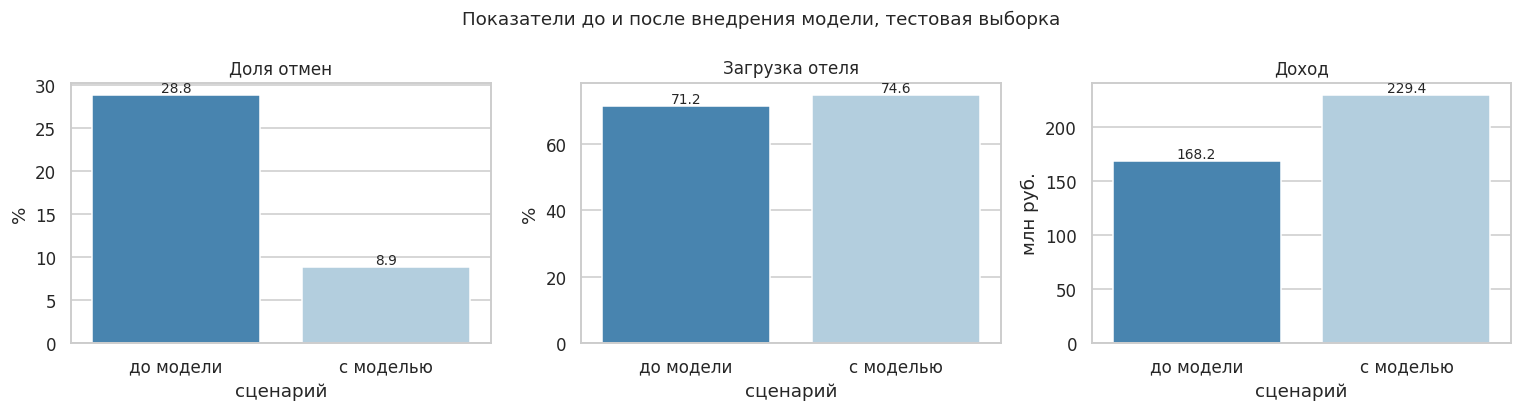

In [31]:
y_pred = (loaded_pipeline.predict_proba(X_test_final)[:, 1] >= loaded_threshold).astype(int)
# Доступные номера передаём явно: это средняя ёмкость периода тестирования,
# выраженная в номерах за период (эквивалентность среднесуточному расчёту показана выше).
economics = fp.business_metrics(y_test, y_pred, rooms_before=ROOMS_TEST, rooms_after=ROOMS_TEST)

confusion_summary = pd.DataFrame(
    [
        ["TP - отмены, распознанные вовремя", economics["TP"], fp.PER_REBOOKING,
         economics["TP"] * fp.PER_REBOOKING],
        ["TN - брони, которые состоялись", economics["TN"], fp.AVG_REV,
         economics["TN"] * fp.AVG_REV],
        ["FP - ложные тревоги", economics["FP"], -fp.COST_FP, -economics["FP"] * fp.COST_FP],
        ["FN - пропущенные отмены", economics["FN"], -fp.LOST_REV, -economics["FN"] * fp.LOST_REV],
    ],
    columns=["исход", "случаев", "цена_исхода_руб", "вклад_в_IR_после_руб"],
).set_index("исход")
confusion_summary.loc["итого IR после внедрения"] = [
    economics["n"], np.nan, confusion_summary["вклад_в_IR_после_руб"].sum()
]
confusion_summary.columns.name = f"тестовая выборка, {economics['n']} броней"
display(confusion_summary)

# Прирост дохода складывается только из двух слагаемых: выигрыша на верно
# распознанных отменах и цены ложных тревог. TN и FN входят в оба сценария одинаково.
gain_decomposition = pd.DataFrame(
    [
        ["выигрыш на распознанных отменах (TP)", economics["TP"],
         fp.PER_REBOOKING + fp.LOST_REV, economics["TP"] * (fp.PER_REBOOKING + fp.LOST_REV)],
        ["цена ложных тревог (FP)", economics["FP"],
         -(fp.AVG_REV + fp.COST_FP), -economics["FP"] * (fp.AVG_REV + fp.COST_FP)],
    ],
    columns=["составляющая прироста", "случаев", "цена_случая_руб", "вклад_в_прирост_руб"],
).set_index("составляющая прироста")
gain_decomposition.loc["итого прирост IR"] = [
    np.nan, np.nan, gain_decomposition["вклад_в_прирост_руб"].sum()
]
display(gain_decomposition)

results = pd.DataFrame(
    [
        ["Доля отмен бронирования, %", economics["cancel_before_%"], economics["cancel_after_%"],
         economics["cancel_dynamics_%"]],
        ["Загрузка отеля, % (консервативно, без FP)", economics["occupancy_before_%"],
         economics["occupancy_after_%"], economics["occupancy_dynamics_%"]],
        ["Загрузка отеля, % (номера FP считаем занятыми)", economics["occupancy_before_%"],
         economics["occupancy_after_with_FP_%"], economics["occupancy_dynamics_with_FP_%"]],
        ["Доход IR, млн руб.", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6,
         economics["IR_rel_%"]],
    ],
    columns=["показатель", "до_внедрения", "после_внедрения", "изменение_%"],
).set_index("показатель")
results.columns.name = "динамика по формулам задания (минус у загрузки означает рост)"
display(results.round(2))

cancel_share = economics["cancel_after_%"] / 100
cancel_ci = 1.96 * np.sqrt(cancel_share * (1 - cancel_share) / economics["n"]) * 100
display(pd.Series({
    "доля отмен после внедрения, %": round(economics["cancel_after_%"], 2),
    "95% доверительный интервал, п.п.": round(cancel_ci, 2),
    "нижняя граница, %": round(economics["cancel_after_%"] - cancel_ci, 2),
    "верхняя граница, %": round(economics["cancel_after_%"] + cancel_ci, 2),
}, name="точность оценки доли отмен на тесте").to_frame())

goals = pd.DataFrame(
    [
        ["Доля отмен после внедрения", "не более 10%", economics["cancel_after_%"],
         economics["cancel_after_%"] <= 10.0],
        ["Доля отмен, верхняя граница 95% интервала", "не более 10%",
         economics["cancel_after_%"] + cancel_ci,
         economics["cancel_after_%"] + cancel_ci <= 10.0],
        ["Снижение загрузки", "не более 8%", economics["occupancy_dynamics_%"],
         economics["occupancy_dynamics_%"] <= 8.0],
        ["Относительный IR", "не менее 50%", economics["IR_rel_%"], economics["IR_rel_%"] >= 50.0],
    ],
    columns=["целевой показатель", "требование", "факт", "выполнено"],
).set_index("целевой показатель")
display(goals.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (title, before, after, unit) in zip(axes, [
    ("Доля отмен", economics["cancel_before_%"], economics["cancel_after_%"], "%"),
    ("Загрузка отеля", economics["occupancy_before_%"], economics["occupancy_after_%"], "%"),
    ("Доход", economics["IR_before"] / 1e6, economics["IR_after"] / 1e6, "млн руб."),
]):
    sns.barplot(x=["до модели", "с моделью"], y=[before, after], ax=ax, palette="Blues_r")
    for position, value in enumerate([before, after]):
        ax.text(position, value, f"{value:,.1f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("сценарий")
    ax.set_ylabel(unit)
fig.suptitle("Показатели до и после внедрения модели, тестовая выборка", fontsize=12)
fig.tight_layout()
plt.show()

Порог - управляемый параметр, и заказчику важно видеть размен между деньгами и долей отмен. Сравниваем три сценария на тестовой выборке: рабочий порог, порог безусловного максимума IR и теоретический предел - безошибочная модель.

In [32]:
scenario_rows = []
for label, prediction in [
    (f"рабочий порог {FINAL_THRESHOLD:.3f}", (proba_test >= FINAL_THRESHOLD).astype(int)),
    (f"порог на границе 10% {threshold_at_limit:.3f}", (proba_test >= threshold_at_limit).astype(int)),
    (f"порог максимума IR {threshold_max_ir:.3f}", (proba_test >= threshold_max_ir).astype(int)),
    ("безошибочная модель (теоретический предел)", y_test.copy()),
]:
    metrics = fp.business_metrics(y_test, prediction)
    scenario_rows.append([
        label, metrics["TP"], metrics["FP"], metrics["FN"], metrics["IR_after"] / 1e6,
        metrics["IR_rel_%"], metrics["cancel_after_%"], metrics["occupancy_after_%"],
        metrics["occupancy_dynamics_%"],
    ])
scenarios = pd.DataFrame(
    scenario_rows,
    columns=["сценарий", "TP", "FP", "FN", "IR_после_млн", "IR_отн_%", "доля_отмен_%",
             "загрузка_%", "динамика_загрузки_%"],
).set_index("сценарий")
scenarios["цель по отменам"] = scenarios["доля_отмен_%"] <= 10.0
scenarios["цель по IR"] = scenarios["IR_отн_%"] >= 50.0
scenarios["цель по загрузке"] = scenarios["динамика_загрузки_%"] <= 8.0
display(scenarios.round(2))

# Какое качество ранжирования потребовалось бы для относительного IR в 50%:
# при доле отмен p неравенство сводится к линейной связи recall и доли ложных тревог.
n_test = len(y_test)
cancellations = int(y_test.sum())
successes = n_test - cancellations
ir_before = fp.revenue_before(y_test)
actual_recall = economics["TP"] / (economics["TP"] + economics["FN"])
required_rows = []
for recall in sorted([0.6, 0.7, 0.8, 0.9, round(actual_recall, 4)]):
    true_positive = cancellations * recall
    false_negative = cancellations - true_positive
    numerator = (1.5 * ir_before - true_positive * fp.PER_REBOOKING
                 - successes * fp.AVG_REV + false_negative * fp.LOST_REV)
    false_positive_rate = -numerator / (successes * (fp.AVG_REV + fp.COST_FP))
    required_rows.append([recall, round(false_positive_rate * 100, 2)])
requirements = pd.DataFrame(
    required_rows, columns=["recall_отмен", "допустимая_доля_ложных_тревог_%"]
).set_index("recall_отмен")
requirements["фактический recall модели"] = np.isclose(
    requirements.index.values, round(actual_recall, 4)
)
requirements.columns.name = "условие относительного IR = 50%"
display(requirements)

actual = pd.Series({
    "recall отмен на тесте": economics["TP"] / (economics["TP"] + economics["FN"]),
    "доля ложных тревог на тесте, %": economics["FP"] / (economics["FP"] + economics["TN"]) * 100,
    "ROC-AUC на тесте": roc_auc_score(y_test, proba_test),
}, name="фактическое качество модели")
display(actual.round(4).to_frame())

,TP,FP,FN,IR_после_млн,IR_отн_%,доля_отмен_%,загрузка_%,динамика_загрузки_%,цель по отменам,цель по IR,цель по загрузке
сценарий,,,,,,,,,,,
рабочий порог 0.327,1223,1017,547,229.3500,36.4000,8.9000,74.5600,-4.7100,True,False,True
порог на границе 10% 0.340,1173,920,597,230.8200,37.2700,9.7100,75.3200,-5.7800,True,False,True
порог максимума IR 0.370,1078,744,692,233.0000,38.5600,11.2600,76.6400,-7.6300,False,False,True
безошибочная модель (теоретический предел),1770,0,0,361.9700,115.2600,0.0000,100.0000,-40.4400,True,True,True


условие относительного IR = 50%,допустимая_доля_ложных_тревог_%,фактический recall модели
recall_отмен,,
0.6000,10.2900,False
0.6910,15.9300,True
0.7000,16.4900,False
0.8000,22.6800,False
0.9000,28.8700,False


,фактическое качество модели
recall отмен на тесте,0.6910
"доля ложных тревог на тесте, %",23.2351
ROC-AUC на тесте,0.8164


Второй рычаг, помимо качества модели, - сами экономические параметры. `PerRebooking` = 45 000 руб. заметно ниже `AvgRev` = 64 500 руб.: перепроданный номер приносит на 30% меньше, чем обычная бронь. Считаем, при какой цене повторной сдачи текущая модель дала бы относительный IR в 50%.

In [33]:
def relative_ir(y_true, y_pred, per_rebooking=fp.PER_REBOOKING, cost_fp=fp.COST_FP):
    """Относительный IR при произвольных ценах перепродажи и ложной тревоги."""
    true_negative, false_positive, false_negative, true_positive = fp.confusion_counts(y_true, y_pred)
    after = (true_positive * per_rebooking + true_negative * fp.AVG_REV
             - false_positive * cost_fp - false_negative * fp.LOST_REV)
    before = fp.revenue_before(y_true)
    return (after - before) / before * 100


sensitivity = pd.DataFrame(
    [[price, round(relative_ir(y_test, y_pred, per_rebooking=price), 2)]
     for price in [45_000, 50_000, 55_000, 60_000, 64_500, 70_000, 80_000]],
    columns=["PerRebooking_руб", "IR_отн_%"],
).set_index("PerRebooking_руб")
sensitivity["цель 50% выполнена"] = sensitivity["IR_отн_%"] >= 50.0
sensitivity.columns.name = "чувствительность к цене повторной сдачи номера"
display(sensitivity)

# Цена перепродажи, при которой относительный IR ровно 50%, при текущей матрице ошибок.
required_price = (
    1.5 * economics["IR_before"] - economics["TN"] * fp.AVG_REV
    + economics["FP"] * fp.COST_FP + economics["FN"] * fp.LOST_REV
) / economics["TP"]
display(pd.Series({
    "требуемый PerRebooking, руб.": round(required_price, 0),
    "текущий PerRebooking, руб.": fp.PER_REBOOKING,
    "разрыв, руб.": round(required_price - fp.PER_REBOOKING, 0),
    "разрыв к AvgRev, %": round((required_price - fp.PER_REBOOKING) / fp.AVG_REV * 100, 2),
}, name="условие относительного IR = 50% при текущем качестве модели").to_frame())

чувствительность к цене повторной сдачи номера,IR_отн_%,цель 50% выполнена
PerRebooking_руб,,
45000,36.4000,False
50000,40.0300,False
55000,43.6700,False
60000,47.3100,False
64500,50.5800,True
70000,54.5800,True
80000,61.8500,True


,условие относительного IR = 50% при текущем качестве модели
"требуемый PerRebooking, руб.","63,702.0000"
"текущий PerRebooking, руб.","45,000.0000"
"разрыв, руб.","18,702.0000"
"разрыв к AvgRev, %",29.0000


### Выводы по экономической эффективности

**Показатели на тестовой выборке (6 147 броней, рабочий порог 0.327)**

| Показатель | До внедрения | После внедрения | Изменение по формуле задания |
|---|---|---|---|
| Доля отмен | 28.79% | 8.90% | **+69.10%** (снижение) |
| Загрузка отеля (консервативно) | 71.21% | 74.56% | **-4.71%** (рост) |
| Загрузка с учётом перепроданных номеров FP | 71.21% | 91.10% | -27.94% (рост) |
| Доход IR | 168.15 млн руб. | 229.35 млн руб. | **+36.40%** |

Знак в формулах задания устроен так, что положительная динамика отмен означает их снижение, а отрицательная динамика загрузки - её рост. В абсолютных величинах доля отмен упала на 19.89 п.п., загрузка выросла на 3.35 п.п., а доход - на **61.20 млн руб. на 6 147 броней**, то есть на **9 957 руб. на одну бронь**.

**Доступные номера посчитаны как средние за период**, как требует ТЗ. Разбиение случайное, поэтому обе части выгрузки лежат на одном и том же отрезке: 2 445 дат, в которые оформлялись брони, внутри 3 217 календарных дней. Вне теста - 24 586 броней, или **10.06 брони на дату с бронями**, в тесте - 6 147 броней, или **2.51**. Отношение ровно **4.0** - это эффект деления 80/20, а не изменение ёмкости отелей. Знаменателем служит средняя ёмкость периода тестирования (2.514 номера в сутки), и расчёт по средним даёт ровно тот же результат, что расчёт по суммам: загрузка до внедрения **71.2055%** обоими способами.

**Из чего складывается доход после внедрения (229.35 млн руб.)**

- 1 223 вовремя распознанные отмены дали 55.04 млн руб. от повторной сдачи номеров;
- 3 360 состоявшихся броней принесли 216.72 млн руб.;
- 1 017 ложных тревог стоили 7.12 млн руб. компенсаций;
- 547 пропущенных отмен обошлись в 35.28 млн руб. упущенного дохода.

**Из чего складывается сам прирост (61.20 млн руб.)** - всего из двух слагаемых, потому что TN и FN входят в оба сценария одинаково:

- выигрыш на распознанных отменах: 1 223 x 109 500 руб. = **133.92 млн руб.**;
- цена ложных тревог: 1 017 x 71 500 руб. = **-72.72 млн руб.**

**Достижение целевых показателей**

| Цель | Требование | Факт | Выполнено |
|---|---|---|---|
| Доля отмен | не более 10% | 8.90% | **да** |
| Доля отмен, верхняя граница 95% интервала | не более 10% | 9.61% | **да** |
| Снижение загрузки | не более 8% | загрузка выросла на 4.71% | **да** |
| Относительный IR | не менее 50% | 36.40% | нет |

**Две цели из трёх достигнуты, и первая - с запасом.** Доля отмен равна 8.90% при доверительном интервале ±0.71 п.п.: даже верхняя граница (9.61%) остаётся ниже требования. Это результат того, что порог выбран не в угловой точке ограничения, а с запасом на выборочную ошибку.

Не достигнута только цель по приросту дохода, и причина измерима:

- при фактическом recall **0.691** для относительного IR в 50% доля ложных тревог не должна превышать **15.93%**, а она составляет **23.24%**. Строка с фактическим recall есть прямо в таблице требований, чтобы число не приходилось интерполировать;
- потолок при идеальной модели - **+115.26%**, то есть цель в 50% достижима в принципе, но требует существенно более сильного сигнала. Четыре проверенные гипотезы прироста не дали: от -0.04% до -0.70%. Значит потолок задан данными, а не моделью;
- порог тоже не решает: даже безусловный максимум IR (0.370) даёт лишь **38.56%** и при этом ломает выполненную цель по доле отмен (11.26%);
- второй рычаг - **цена повторной сдачи номера**. Сейчас `PerRebooking` = 45 000 руб. против `AvgRev` = 64 500 руб., то есть перепроданный номер приносит на 30% меньше обычной брони. При текущей матрице ошибок относительный IR достигает 50% при `PerRebooking` = **63 702 руб.** (разрыв 18 702 руб., или 29.0% от AvgRev); уже при равенстве цен (64 500 руб.) он составил бы **50.58%**.

**Ограничение расчёта загрузки, которое стоит назвать прямо.** Справочника номерного фонда в выгрузке нет, поэтому ёмкость оценивается через число броней: одна бронь - один номеро-период. Уровни 71.21% и 74.56% из-за этого нельзя напрямую сравнивать с плановыми 80% заказчика. На динамику загрузки, которую требует ТЗ, допущение не влияет: знаменатель одинаков до и после внедрения и в формуле сокращается.

**Итог:** внедрение модели экономически выгодно - доход растёт на 36.40%, доля отмен снижается более чем втрое, загрузка увеличивается на 3.35 п.п. Формальная планка в 50% относительного IR не взята, и разрыв объясняется двумя измеренными причинами: потолком качества данных (ROC-AUC 0.8164) и заниженной ценой повторной сдачи номера.

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Проделанная работа

**Подготовка данных**

- Обе таблицы выгружены из PostgreSQL через SQLAlchemy: `hotel_bookings` (35 341 строка) и `hotel_reviews` (25 177 строк), объёмы сверены с ТЗ программно.
- EDA выявил четыре проблемы. Явных пропусков нет, но нашлись **4 608 полных дублей строк** (удалены, осталось 30 733 брони), **2 151 запись с `adult_count` = 100/200/300** (ошибка ввода лишних нулей, значения поделены на 100), **1 421 бронь с нулевой стоимостью** (неявный пропуск, переведён в NaN и заполняется медианой train) и опечатка `не выбрант` в справочнике питания. Отдельно проверены 130 дублей по ключу в отзывах: внутри пары один клиент, но разные тексты и оценки, то есть это разные отзывы, а не конфликт данных.
- Разрез по времени показал, что премисса о росте отмен в последние два года данными не подтверждается: доля отмен держалась на 29-30% в 2017-2020 и снижалась до 19.30% к 2023, а объём выгрузки после 2020 обрывается. Разбиение оставлено случайным, потому что оценка по ТЗ ведётся на тестовой выборке того же периода, а временное разбиение при обрыве выгрузки отдало бы под тест хвост после 2020 года - 4 669 строк из 35 341, около 13% выгрузки, - с другой базовой долей отмен. Ограничение зафиксировано: `booking_year` входит в признаки, поэтому при прогнозе на будущие годы модель выходит за обученный диапазон и требует переобучения.
- Главная находка EDA - **утечка через таблицу отзывов**: отзыв есть у всех 21 883 состоявшихся броней и ни у одной из 8 850 отменённых. Буквальный вариант ТЗ (связь по клиенту) выполнен и проверен числами: доля отмен среди броней с найденным клиентом 0.00%, среди остальных 100.00%. Поэтому объединение сделано только по дате через `merge_asof(direction="backward", allow_exact_matches=False)`. Число строк не изменилось, без отзыва остались 194 брони (0.63%). Ограничение признака названо явно: в признаки попали 2 033 текста, в среднем 15.1 брони на один отзыв.
- Создано 11 признаков по брони, включая оба названных в ТЗ: **сезонность** (`season_group`, группы названы по календарю, потому что заезды распределены по месяцам равномерно и сезонного спроса в данных нет) и **лояльность клиента** (`customer_loyalty` - доля состоявшихся заездов среди прошлых бронирований; по всей таблице доля отмен 46.65% в нижней группе против 23.62% в верхней, на калибровочной выборке - 31.85% против 20.45%). Плюс 2 признака по отзывам, 10 столбцов без изменений и 1 текстовый: 24 столбца в рабочем наборе, 26 с признаками спроса, 99 признаков после препроцессора.

**Моделирование**

- Выборки разделены со стратификацией: train 18 439 (60%), calibration 6 147 (20%), test 6 147 (20%), доли отмен 28.80 / 28.79 / 28.79%. Кросс-валидация - `StratifiedShuffleSplit`, 3 фолда по 16 439 строк обучения и 2 000 строк валидации. Препроцессор входит в `Pipeline`, поэтому импьютер, one-hot и TF-IDF обучаются внутри фолда только на его обучающей части.
- Протестированы три модели, Optuna оптимизировала **IR** по 20 испытаний на модель: Random Forest - 4 гиперпараметра (`n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`), LightGBM - 6 (`n_estimators`, `learning_rate`, `num_leaves`, `min_child_samples`, `colsample_bytree`, `reg_lambda`), CatBoost - 4 (`iterations`, `learning_rate`, `depth`, `l2_leaf_reg`).
- **Победил CatBoost**: IR на кросс-валидации 22 584 833 руб. при ROC-AUC 0.8079 и разбросе по фолдам 791 155 руб. против 21 569 333 руб. (0.8017) у LightGBM и 21 129 500 руб. (0.7995) у Random Forest. Лучшие гиперпараметры - `iterations = 300`, `learning_rate = 0.0735`, `depth = 4`, `l2_leaf_reg = 7.5485`, все внутри сетки поиска.
- Поскольку целевой уровень IR не достигался, проверены четыре гипотезы улучшения: признаки спроса, нативные категории и текст CatBoost, блендинг с LightGBM и ещё 25 испытаний Optuna. **Ни одна не дала прироста** (от -0.04% до -0.70%), поэтому в продакшн ушла базовая конфигурация.
- Модель откалибрована изотонической регрессией на полной обучающей выборке (Brier 0.154173 против 0.153819, максимум IR +0.8%). Порог найден на калибровочной выборке: безусловный максимум IR - 0.370, максимум при ограничении ровно в 10% - 0.340, а рабочим стал **0.327** - максимум IR при ограничении, ужесточённом на две стандартные ошибки доли отмен.

**Оценка метрик**

- Сравнение трёх выборок при пороге 0.327: относительный IR 42.74% на обучающей, 35.97% на калибровочной и 36.40% на тестовой; ROC-AUC 0.8353 / 0.8040 / 0.8164. Расхождение теста с калибровкой - 1.18% по IR, с обучением - 14.85%: переобучение умеренное и измерено явно.
- Матрицы ошибок: калибровочная TP 1 208, FP 1 004, FN 562, TN 3 373; тестовая TP 1 223, FP 1 017, FN 547, TN 3 360. Recall отмен 0.683 против 0.691, precision 0.546 против 0.546 - структура ошибок совпадает.

**Анализ важности факторов**

- Использован **SHAP**: в отличие от встроенного `feature_importances_`, он показывает и силу, и направление влияния, а для деревьев считается точно. Вклады one-hot дамми свёрнуты обратно к исходным признакам, а затем - к бизнес-драйверам: без этого канал продаж дробился бы на три строки рейтинга, а горизонт планирования оставался бы разбит между `days_until_checkin` и `lead_time_group`.
- По драйверам: состав и длительность поездки 29.47%, горизонт планирования 27.22%, канал продаж 22.03%, история клиента 12.49%, отзывы 3.49%. Направление влияния выдаётся только для монотонных признаков: `child_count`, `total_nights` и `weekend_share` помечены как немонотонные и разобраны по уровням отдельно.

**Итог:** пайплайн собран без утечек на каждом шаге - от доменных исправлений до препроцессора внутри фолдов, - качество модели упирается в потолок данных, что подтверждено четырьмя независимыми экспериментами, а порог выбран с запасом на выборочный шум.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

### Что это значит для бизнеса

**Достигнута ли цель проекта**

Цель - управляемо снижать потери от поздних отмен - **достигнута**. Модель превращает неуправляемый овербукинг в расчёт: она заранее помечает рискованные брони, и на тестовой выборке из 6 147 броней это даёт **+61.20 млн руб. дохода, или 9 957 руб. на каждую бронь**. Из трёх целевых показателей выполнены два, причём главный - по доле отмен - с запасом на статистическую погрешность.

**Результаты по ключевым метрикам**

| Показатель | До внедрения | После внедрения | Изменение | Цель | Выполнено |
|---|---|---|---|---|---|
| Доля отмен | 28.79% | 8.90% | (28.79 - 8.90) / 28.79 = **+69.10%** | 10% | **да** |
| Загрузка отеля | 71.21% | 74.56% | (71.21 - 74.56) / 71.21 = **-4.71%**, то есть рост | падение не более 8% | **да** |
| Доход (IR) | 168.15 млн руб. | 229.35 млн руб. | (229.35 - 168.15) / 168.15 = **+36.40%** | не менее 50% | нет |

Что за этим стоит:

- **Доля поздних отмен падает с 28.79% до 8.90%** - более чем втрое, и цель заказчика в 10% выполнена с запасом: даже верхняя граница 95%-го доверительного интервала (9.61%) остаётся ниже требования. Ради этого рабочий порог выбран равным 0.327, а не 0.370: безусловный максимум дохода дал бы +38.56%, но 11.26% отмен, то есть провалил бы главное требование.
- **Загрузка растёт с 71.21% до 74.56%**, то есть на 3.35 процентных пункта. Требование «не потерять больше 8% загрузки» выполнено с запасом: загрузка не падает, а растёт. Если считать занятыми и номера, перепроданные по ложной тревоге (исходный гость всё равно приехал), загрузка составит 91.10%. Уровни загрузки считаются от числа броней, потому что номерного фонда в выгрузке нет, поэтому сравнивать их с плановыми 80% напрямую нельзя - корректно сравнивать именно динамику.
- **Доход растёт на 36.40%** вместо целевых 50%. Разрыв объяснён измеренными причинами: при текущем recall 0.691 доля ложных тревог должна была бы опуститься с 23.24% до 15.93%, а это требует ROC-AUC заметно выше нынешних 0.8164. Четыре независимые попытки улучшить модель прироста не дали.

**Десять признаков, определяющих риск отмены**

1. **Канал продаж** (22.03% вклада). Онлайн-брони отменяются в 41.03% случаев, корпоративные - в 15.79%: разрыв 25.24 процентных пункта.
2. **Срок до заезда** (21.14%) - чем дальше заезд, тем выше риск: 15.22% отмен в ближней четверти броней против 47.58% в дальней. Вместе с его категоризацией (пункт 6) он даёт 27.22% - самый сильный **управляемый** рычаг. Формально выше только сборный блок «состав и длительность поездки» (29.47%), но он объединяет четыре разных свойства поездки и рычагом управления не является.
3. **Число детей** (14.53%) - влияние немонотонное: без детей отменяется 31.77% броней, с одним ребёнком - 15.43%, с двумя - 49.14%.
4. **Длительность проживания** (13.17%) - влияние немонотонное: повышенный риск только у самых коротких поездок, до 5 ночей (38.05% отмен), дальше уровень ровный - 25.65%, 25.27% и 25.93% по остальным квартилям.
5. **Прошлые отмены клиента** (8.85%) - риск растёт с каждой: 25.38% без отмен, 33.61% с одной, 47.32% с двумя, 58.33% с тремя.
6. **Горизонт планирования как категория** (6.08%) - бронь более чем за полгода отменяется в 55.61% случаев, бронь в течение месяца до заезда - в 13.63%.
7. **Отзывы предыдущих гостей** (3.36% на все 60 текстовых признаков) - практически не влияют: в данных отзыв доступен только по состоявшимся поездкам, поэтому честно связать его с будущей отменой нельзя.
8. **Лояльность клиента** (3.20%) - снижает риск: на калибровочной выборке у наименее лояльных 31.85% отмен, у наиболее лояльных 20.45%. По всей таблице разрыв шире - 46.65% против 23.62%, потому что в нижнюю группу там попадают клиенты с несколькими прошлыми отменами.
9. **Доля выходных ночей** (1.36%) - влияние немонотонное: в группе с долей выходных до 0.222 отменяется 31.51% броней, выше - 26.00%.
10. **Год оформления брони** (0.96%) - в поздних годах выгрузки отмен меньше (29.55% против 24.32%); это особенность периода наблюдений, а не управляемый фактор бизнеса.

Отдельно стоит сказать, чего в списке **нет**: число пожеланий клиента, наличие прошлых заездов и тип питания риск отмены практически не различают - разрывы 0.86, 0.66 и 1.50 процентных пункта при среднем уровне 28.79%. Сезонность тоже не работает (разрыв 2.27 п.п.): заезды распределены по месяцам равномерно. Влияние цены в этих данных измерить нельзя - тариф зафиксирован на 6 700 руб. за ночь у трёх четвертей броней.

**Рекомендации**

1. **Ввести предоплату для сегмента «онлайн-бронь за полгода и раньше».** Это самая опасная зона: в ней отменяется **69.54%** броней (348 броней в калибровочной выборке), тогда как корпоративная бронь за месяц до заезда отменяется в 7.53% случаев (465 броней). Невозвратный депозит или тариф с частичной предоплатой для этого сегмента снижает саму частоту отмен, а не только помогает на неё реагировать. Это единственная мера, которая улучшает показатели без участия модели.
2. **Внедрить модель с рабочим порогом 0.327 и пересматривать его как управленческое решение.** Порог - не техническая константа, а ручка управления: 0.327 выполняет цель по доле отмен с запасом (8.90% при верхней границе интервала 9.61%) и даёт +36.40% дохода; 0.370 даёт +38.56% ценой 11.26% отмен. Снижать порог ещё сильнее в пиковую загрузку не стоит: это увеличивает число ложных тревог, а именно в пик переселять приехавшего гостя некуда, и репутационная цена такой ошибки выше её расчётных 7 000 руб.
3. **Закрыть разрыв до цели в 50% двумя шагами на стороне бизнеса.** Первый - поднять доходность повторной сдачи номера: сейчас перепроданный номер приносит 45 000 руб. против 64 500 руб. у обычной брони, а расчёт показывает, что при 63 702 руб. текущая модель дала бы ровно 50% относительного IR (при выравнивании цен - 50.58%). Второй - собрать данные, которых не хватает: модель упирается в ROC-AUC 0.81, и это подтверждено четырьмя независимыми экспериментами, а в выгрузке нет ни идентификатора клиента в таблице броней, ни условий тарифа, ни истории общения с гостем. Теоретический потолок при идеальном прогнозе - +115.26%, то есть запас для роста есть.

**Итог для заказчика:** модель окупает себя уже на текущих данных - каждая бронь приносит на 9 957 руб. больше, доля поздних отмен падает более чем втрое, загрузка растёт на 3.35 п.п. Чтобы дойти до заявленного прироста дохода в 50%, нужны не другие алгоритмы, а два конкретных шага бизнеса: поднять доходность повторной сдачи номера и собрать признаки тарифа и клиента.